In [1]:
# 【脚本】 清空+ 安装

# 清空输出

import os
import shutil

# 定义要清空的文件夹路径
# 在 Kaggle Notebook 中，当前工作目录通常是 /kaggle/working
folder_to_clear = '/kaggle/working' 

print(f"--- 警告 ---")
print(f"您即将执行危险操作：清空文件夹 '{folder_to_clear}' 下的所有内容。")
print(f"此操作是不可逆的！请确认您已备份所有重要文件。")
print(f"--- 警告 ---")

# 您可以选择在这里加入一个确认提示，例如：
# confirm = input("请键入 'YES' 以继续清空操作，否则按任意键退出: ")
# if confirm != 'YES':
#     print("操作已取消。")
#     sys.exit() # 如果要退出程序，可以使用这个

try:
    # 检查文件夹是否存在
    if os.path.exists(folder_to_clear):
        print(f"\n开始清空文件夹: {folder_to_clear} ...")
        
        # 遍历文件夹中的所有内容（文件和子文件夹）
        for item_name in os.listdir(folder_to_clear):
            # 构建完整的路径
            item_path = os.path.join(folder_to_clear, item_name)
            
            try:
                # 如果是文件，则删除文件
                if os.path.isfile(item_path):
                    os.unlink(item_path)
                    # print(f"已删除文件: {item_path}")
                # 如果是目录，则删除整个目录及其内容
                elif os.path.isdir(item_path):
                    shutil.rmtree(item_path)
                    # print(f"已删除目录: {item_path}")
            except Exception as e:
                print(f"处理 '{item_path}' 时出错: {e}")
                
        print(f"\n文件夹 '{folder_to_clear}' 已成功清空。")
    else:
        print(f"\n文件夹 '{folder_to_clear}' 不存在，无需清空。")

except Exception as e:
    print(f"\n执行清空操作时发生未知错误: {e}")

print("\n--- 操作结束 ---")

#  【脚本】检查和安装库


# -*- coding: utf-8 -*-


import subprocess
import sys
import os

# 需要安装的库列表
required_packages = [
    "pretty_midi",
    "music21",
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "tqdm",
    "python-magic",
    "fluidsynth",
    "resampy",
]

def install_package(package):
    """
    尝试安装单个Python包。
    """
    print(f"正在尝试安装: {package}")
    try:
        # 使用清华大学的pip镜像源，通常国内访问速度更快
        # 如果您不在国内或偏好官方源，可以移除 "-i https://pypi.tuna.tsinghua.edu.cn/simple"
        process = subprocess.run(
            [sys.executable, "-m", "pip", "install", package, "-i", "https://pypi.tuna.tsinghua.edu.cn/simple"],
            check=True,  # 如果命令返回非零退出码，则抛出CalledProcessError
            capture_output=True, # 捕获stdout和stderr
            text=True # 以文本模式处理输出
        )
        print(f"成功安装 {package}。")
        # print(f"pip install {package} 的输出:\n{process.stdout}") # 可以取消注释以查看详细输出
        return True
    except subprocess.CalledProcessError as e:
        print(f"安装 {package} 失败。错误详情:")
        print(f"命令: {' '.join(e.cmd)}")
        print(f"返回码: {e.returncode}")
        print(f"错误输出:\n{e.stderr}")
        # 尝试回退到默认的PyPI源
        print(f"尝试使用默认PyPI源重新安装 {package}...")
        try:
            process_fallback = subprocess.run(
                [sys.executable, "-m", "pip", "install", package],
                check=True,
                capture_output=True,
                text=True
            )
            print(f"使用默认源成功安装 {package}。")
            # print(f"pip install {package} (fallback) 的输出:\n{process_fallback.stdout}")
            return True
        except subprocess.CalledProcessError as e_fallback:
            print(f"使用默认源重新安装 {package} 也失败了。最终错误详情:")
            print(f"命令: {' '.join(e_fallback.cmd)}")
            print(f"返回码: {e_fallback.returncode}")
            print(f"错误输出:\n{e_fallback.stderr}")
            return False
    except Exception as e:
        print(f"安装 {package} 时发生未知错误: {e}")
        return False

def check_and_install_dependencies():
    """
    检查所有必需的库，如果未安装则安装。
    """
    print("--- 开始检查和安装项目依赖库 ---")
    all_installed = True

    for pkg in required_packages:
        print(f"\n正在检查: {pkg}")
        try:
            # 尝试导入库，如果成功则表示已安装
            if pkg == "pretty_midi":
                import pretty_midi
            elif pkg == "music21":
                import music21
            elif pkg == "numpy":
                import numpy
            elif pkg == "pandas":
                import pandas
            elif pkg == "matplotlib":
                import matplotlib
            elif pkg == "seaborn":
                import seaborn
            elif pkg == "tqdm":
                import tqdm
            elif pkg == "python-magic":
                # python-magic 的导入方式是 magic
                import magic
            else:
                # 尝试通用导入方式
                __import__(pkg)
            print(f"{pkg} 已安装。")
        except ImportError:
            print(f"{pkg} 未安装。开始安装...")
            if not install_package(pkg):
                all_installed = False
                print(f"!!!!!!!!!!!!!!!!! 警告: 无法自动安装 {pkg}。请手动安装。 !!!!!!!!!!!!!!!!!")
                print("您可能需要执行以下命令:")
                print(f"  pip install {pkg}")
                if pkg == "python-magic":
                    print("  注意: 对于 'python-magic'，您可能还需要根据您的操作系统安装底层的 'libmagic' 库。")
                    print("  在 Debian/Ubuntu 上: sudo apt-get install libmagic1")
                    print("  在 macOS 上 (使用 Homebrew): brew install libmagic")
                    print("  在 Windows 上，可能需要下载并安装 'file' 工具包，并将其添加到 PATH。")
        except Exception as e:
            print(f"检查 {pkg} 时发生意外错误: {e}")
            all_installed = False

    print("\n--- 依赖库检查安装完成 ---")
    if all_installed:
        print("所有必需的库都已成功安装或已存在。")
    else:
        print("部分或全部必需的库安装失败。请检查上面的错误信息并手动安装。")

if __name__ == "__main__":
    # 在运行脚本时，打印一个友好的提示
    print("此脚本将为您安装或验证所需的Python库。")
    print("为了提供更快的下载速度，此脚本将尝试使用清华大学的PyPI镜像源。")
    print("如果遇到问题，它会尝试回退到官方PyPI源。")
    print("---------------------------------------------------------------------")
    check_and_install_dependencies()
    print("---------------------------------------------------------------------")
    print("依赖安装脚本执行完毕。")

import subprocess
import sys
import importlib.util # 用于检查模块是否已安装

# 需要安装的库列表
required_packages = [
    "pretty_midi",
    "music21",
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "tqdm",
    "python-magic", # 注意: python-magic 通常没有 __version__ 属性
    "fluidsynth",   # 注意: fluidsynth 通常没有 __version__ 属性
    "librosa",
    "pyAudioAnalysis",
    "eyed3",
    "hmmlearn",
    "dtw-python"    # dtw-python 的导入库名是 dtw
]

def is_package_installed(package_name):
    """检查一个Python包是否已安装."""
    # 尝试找到模块的spec，如果找不到则返回None
    # 对于有些库，导入名可能和包名不同（例如 dtw-python -> dtw）
    # 我们这里使用一个简单的替换，更复杂的库可能需要更精确的映射
    module_name = package_name.replace('-', '_')
    if package_name == "dtw-python": # 特殊处理 dtw-python
        module_name = "dtw"

    try:
        spec = importlib.util.find_spec(module_name)
        return spec is not None
    except Exception as e:
        print(f"在检查 '{package_name}' (模块名: '{module_name}') 是否安装时发生错误: {e}")
        return False # 发生错误也视为未安装，以便尝试安装

def install_or_update_package(package):
    """
    尝试安装或更新单个Python包。
    返回 True 如果安装/更新成功，False 如果失败。
    """
    print(f"正在安装/更新 {package}...")
    try:
        # 尝试使用清华大学的pip镜像源安装
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", package, "-i", "https://pypi.tuna.tsinghua.edu.cn/simple"],
                              stdout=subprocess.PIPE, stderr=subprocess.PIPE)
        print(f"{package} 安装/更新成功。")
        return True
    except subprocess.CalledProcessError as e:
        # 如果清华源失败，尝试回退到默认源
        print(f"使用清华源安装 {package} 失败，尝试使用默认源...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", package],
                                  stdout=subprocess.PIPE, stderr=subprocess.PIPE)
            print(f"{package} 使用默认源安装/更新成功。")
            return True
        except subprocess.CalledProcessError as e_fallback:
            print(f"{package} 安装/更新失败 (清华源与默认源均失败)。错误: {e_fallback}")
            return False
        except Exception as e:
            print(f"{package} 安装/更新过程中发生未知错误 (回退): {e}")
            return False
    except Exception as e:
        print(f"{package} 安装/更新过程中发生未知错误: {e}")
        return False

def get_package_version(package_name):
    """
    尝试获取已安装的Python包的版本号。
    返回版本字符串或错误/N/A 信息。
    """
    version_info = None
    module_name_to_import = package_name.replace('-', '_')
    if package_name == "dtw-python":
        module_name_to_import = "dtw"

    try:
        module = importlib.import_module(module_name_to_import)
        if hasattr(module, '__version__'):
            version_info = module.__version__
        else:
            if package_name in ["python-magic", "fluidsynth"]:
                version_info = "N/A (库本身无 __version__ 属性)"
            else:
                version_info = "N/A (库无 __version__ 属性)"
    except ImportError:
        version_info = "导入错误 (可能需要重启环境或安装其他依赖)"
    except Exception as e:
        version_info = f"获取版本时出错: {e}"
    return version_info

if __name__ == "__main__":
    print("="*50)
    print("      Python 依赖库安装与版本检查")
    print("="*50)
    print("正在检查并安装未安装的必需库，同时收集所有库的版本信息...\n")

    successful_versions = {}
    installation_issues = [] # 记录安装失败或版本获取异常的

    for pkg in required_packages:
        if not is_package_installed(pkg):
            # 如果未安装，则尝试安装
            if install_or_update_package(pkg):
                # 安装成功后，再尝试获取版本
                version = get_package_version(pkg)
                if "N/A" in str(version) or "错误" in str(version):
                    installation_issues.append((pkg, version))
                else:
                    successful_versions[pkg] = version
            else:
                # 安装失败
                installation_issues.append((pkg, "安装失败"))
        else:
            # 如果已安装，直接获取版本
            print(f"{pkg} 已安装，正在获取版本...")
            version = get_package_version(pkg)
            if "N/A" in str(version) or "错误" in str(version):
                installation_issues.append((pkg, version))
            else:
                successful_versions[pkg] = version

    print("\n" + "="*50)
    print("           安装/更新与版本检查结果汇总")
    print("="*50)

    if successful_versions:
        print("\n[成功安装/已安装并获取到版本信息的库]:")
        # 按原始 required_packages 的顺序打印，以保持一致性
        for pkg in required_packages:
            if pkg in successful_versions:
                print(f"  - {pkg}: {successful_versions[pkg]}")
    else:
        print("\n[未找到成功安装并获取到版本信息的库]")

    if installation_issues:
        print("\n[安装或版本检查遇到问题的库]:")
        for pkg, issue in installation_issues:
            print(f"  - {pkg}: {issue}")
    else:
        print("\n[所有库的安装与版本获取均正常。]")

    print("\n" + "="*50)
    print("脚本执行完毕。")
    print("="*50)



--- 警告 ---
您即将执行危险操作：清空文件夹 '/kaggle/working' 下的所有内容。
此操作是不可逆的！请确认您已备份所有重要文件。
--- 警告 ---

开始清空文件夹: /kaggle/working ...

文件夹 '/kaggle/working' 已成功清空。

--- 操作结束 ---
此脚本将为您安装或验证所需的Python库。
为了提供更快的下载速度，此脚本将尝试使用清华大学的PyPI镜像源。
如果遇到问题，它会尝试回退到官方PyPI源。
---------------------------------------------------------------------
--- 开始检查和安装项目依赖库 ---

正在检查: pretty_midi
pretty_midi 未安装。开始安装...
正在尝试安装: pretty_midi
成功安装 pretty_midi。

正在检查: music21
music21 已安装。

正在检查: numpy
numpy 已安装。

正在检查: pandas
pandas 已安装。

正在检查: matplotlib
matplotlib 已安装。

正在检查: seaborn
seaborn 已安装。

正在检查: tqdm
tqdm 已安装。

正在检查: python-magic
python-magic 未安装。开始安装...
正在尝试安装: python-magic
成功安装 python-magic。

正在检查: fluidsynth
fluidsynth 未安装。开始安装...
正在尝试安装: fluidsynth
成功安装 fluidsynth。

正在检查: resampy
resampy 未安装。开始安装...
正在尝试安装: resampy
成功安装 resampy。

--- 依赖库检查安装完成 ---
所有必需的库都已成功安装或已存在。
---------------------------------------------------------------------
依赖安装脚本执行完毕。
      Python 依赖库安装与版本检查
正在检查并安装未安装的必需库，同时收集所有库的版本信息...

pretty_midi 已安装，正在获取版本

 v3.5.0  Cross-Domain Emotion Recognition (Speech -> Instrumental Music)
  · epochs=18 frozen=10 head_lr=0.001 backbone_lr=2e-05 backbone=base budget=55min
  [OK] GPU: Tesla T4 × 2
  · device=cuda:0 type=cuda amp=True

[STEP 1/9] 环境与数据准备
  · 扫描真实数据集目录 ...
  [WARN] 检测到多个数据根，按 primary_only 只使用: deam-mediaeval-dataset-emotional-analysis-in-music
  [WARN]   被忽略: ['deam-songs', 'music-emotion-recognition-with-profile-information']
  ·   deam-mediaeval-dataset-emotional-analysis-in-music: audio=1802 table=5412
  [OK] 共发现 1802 音频 / 5412 表格


load real audio:   0%|                                            | 0/180 [00:00<?, ?it/s]

  [OK] 成功载入 180 首真实曲目，编号区间 [2, 212]
  · 未命中逐曲布局，改用宽矩阵 / 长表方案 ...
  · 候选标注表 Top8:
  ·    static_annotations_averaged_songs_2000_2058.cs rows=   58 cols=  13 A=1 V=1
  ·    static_annotations_averaged_songs_1_2000.csv   rows= 1744 cols=   5 A=1 V=1
  ·    arousal.csv                                    rows= 1802 cols=1225 A=1 V=0
  ·    valence.csv                                    rows= 1802 cols=1224 A=0 V=1
  [OK] arousal.csv: 'exact-id' 对齐, 命中 180/180
  [OK] arousal.csv scale mode=global_pct | raw[-0.772,0.898] -> [-0.520,0.670] -> [-1,1]
  [OK] 双通道合成完成 (伙伴: valence.csv)
  [OK] 标注 arousal.csv 对齐成功: 180/180 首


install real data:   0%|                                          | 0/180 [00:00<?, ?it/s]

  [OK] 真实数据已安装 180 首
  · --- 标签体检 [REAL] ---
dimension  n_songs    mean    std  min   max  sat_frac  between_song_sd  within_song_sd status
  arousal      180 -0.1685 0.4641 -1.0 1.000    0.0280           0.4638          0.0148     OK
  valence      180 -0.1900 0.3751 -1.0 0.805    0.0111           0.3745          0.0164     OK
  [OK] 标签体检通过。
  [OK] song-level split: train=100 val=25 test=55
  [OK] 标签标准化 mean=[-0.11599999666213989, -0.16329999268054962] std=[0.4415999948978424, 0.3774999976158142] (仅训练集)
  · [预算] 数据准备完成: 已用 1.6 min，剩余 53.4 min

[STEP 2/9] 加载预训练语音情感模型
  · 加载预训练 SER 模型 ...


...

abl10 ep10/18:   0%|                                               | 0/50 [00:00<?, ?it/s]

val:   0%|                                                         | 0/13 [00:00<?, ?it/s]

  · abl10 ep10: loss=0.2309 val_CCC=0.2868 ema=0.3000 best=0.3384 stale=5 [31.8min]
  · abl10: early stop @epoch 10
  [OK] abl10: 载入验证集最优权重 (val_CCC=0.3384)


abl10:   0%|                                                       | 0/28 [00:00<?, ?it/s]

  · [预算] 机制实验完成: 已用 32.2 min，剩余 22.8 min

[STEP 8/9] 统计推断

---------------- TABLE 2 (chunk level) ----------------
| Model       |   N_chunks |   N_songs |   Arousal_CCC | Arousal_CCC_CI   |   Arousal_PCC |   Arousal_RMSE |   Arousal_MAE |   Arousal_R2 |   Arousal_PredSD |   Arousal_TrueSD |   Valence_CCC | Valence_CCC_CI   |   Valence_PCC |   Valence_RMSE |   Valence_MAE |   Valence_R2 |   Valence_PredSD |   Valence_TrueSD |
|:------------|-----------:|----------:|--------------:|:-----------------|--------------:|---------------:|--------------:|-------------:|-----------------:|-----------------:|--------------:|:-----------------|--------------:|---------------:|--------------:|-------------:|-----------------:|-----------------:|
| Zero-Shot   |        220 |        55 |        0.1150 | [0.018, 0.215]   |        0.2116 |         0.6914 |        0.5817 |      -1.0460 |           0.3035 |           0.4834 |        0.0520 | [-0.088, 0.178]  |        0.0753 |         0.6675 |        0.

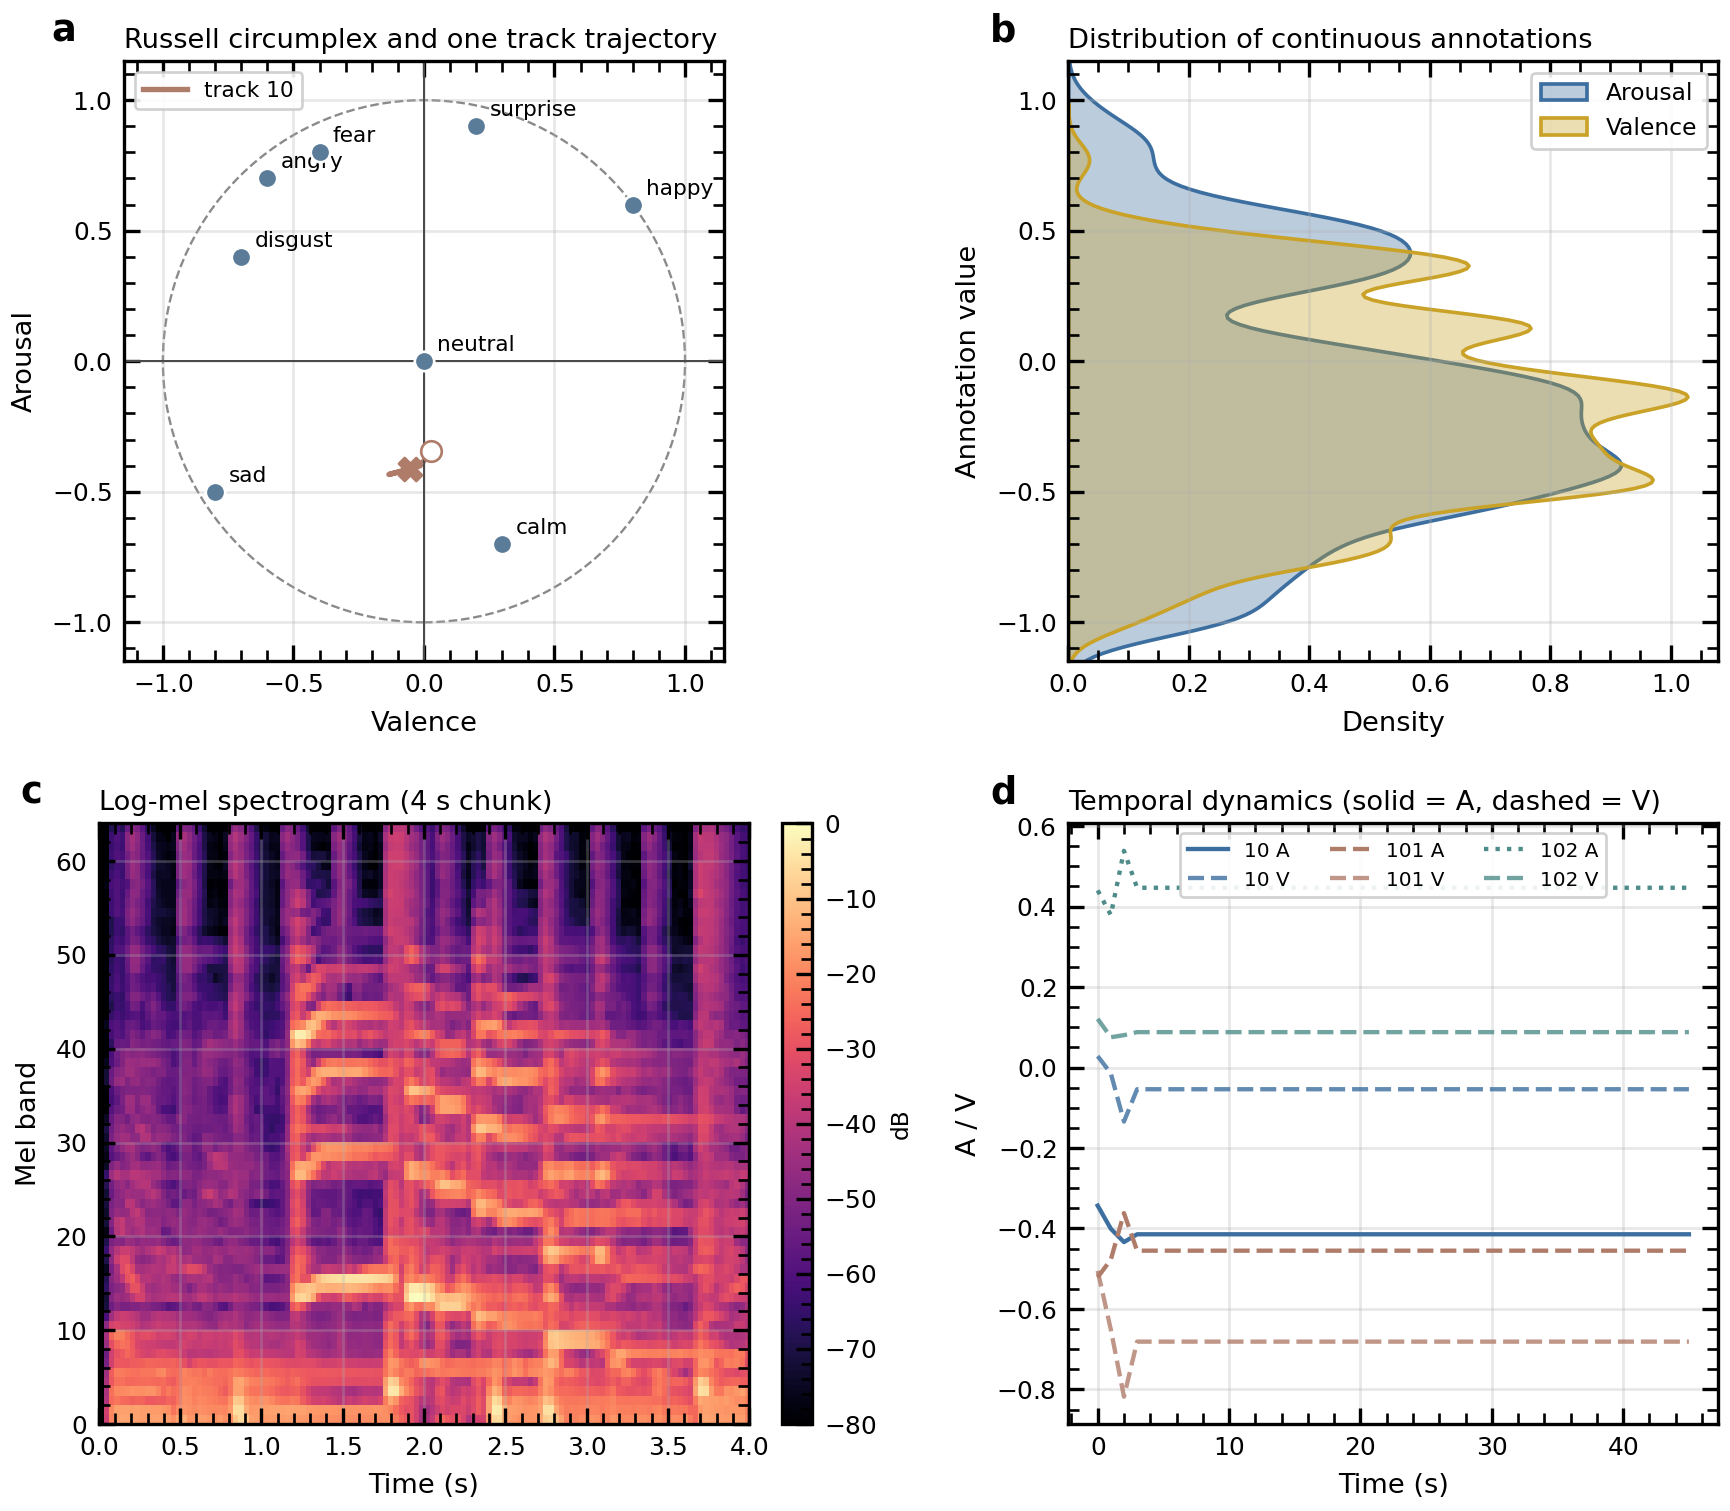

  [OK] figure: /kaggle/working/xdom_emotion_outputs/run_20260926_160834/figures/Fig2_main_results.png (+pdf/svg)


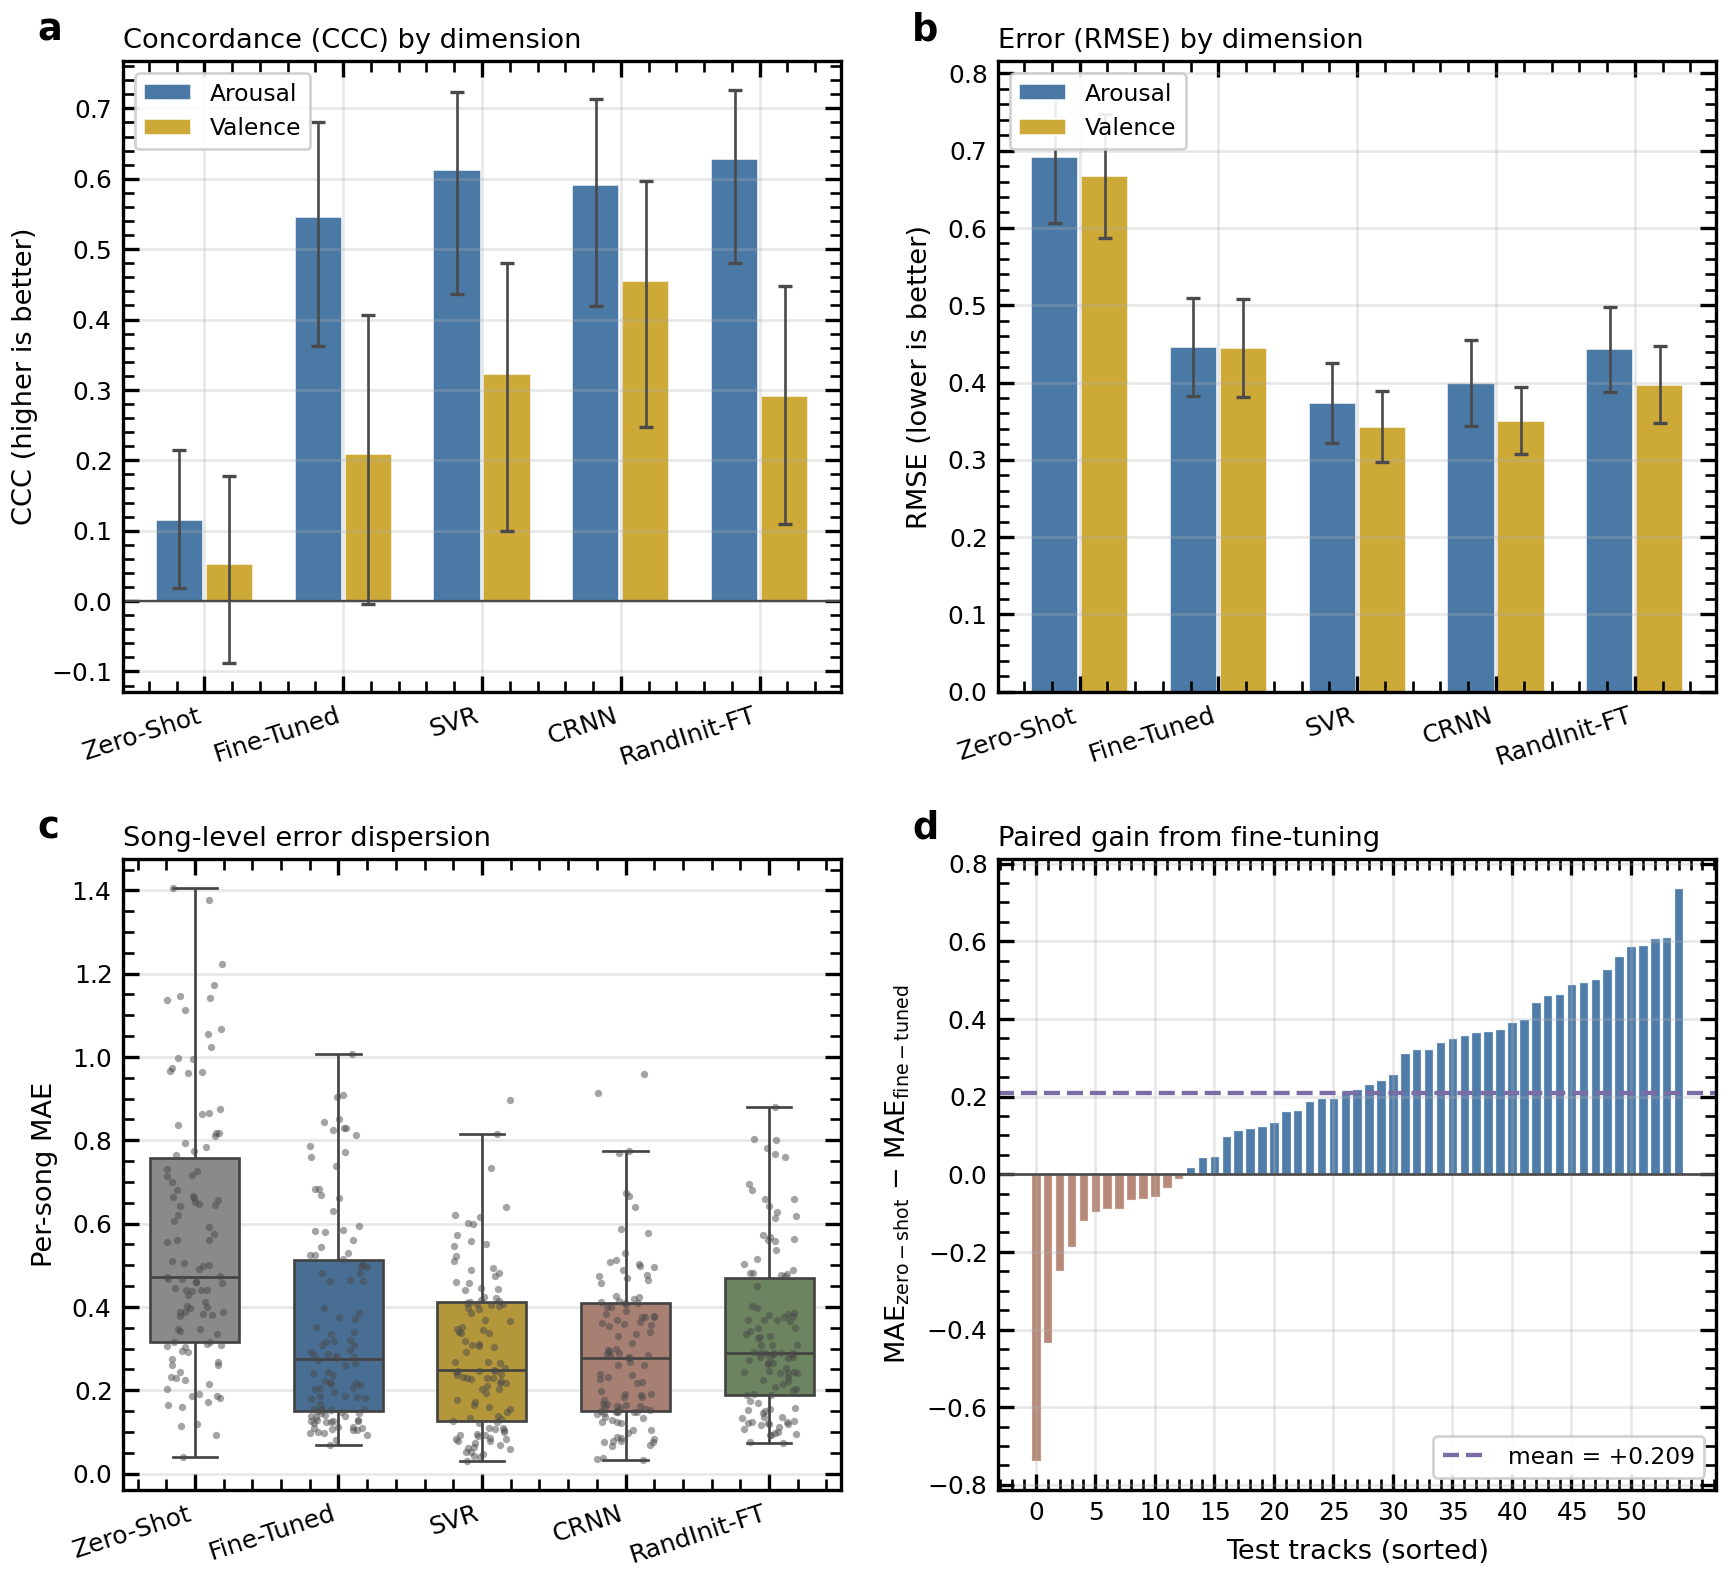

  [OK] figure: /kaggle/working/xdom_emotion_outputs/run_20260926_160834/figures/Fig3_ablation_and_diagnostics.png (+pdf/svg)


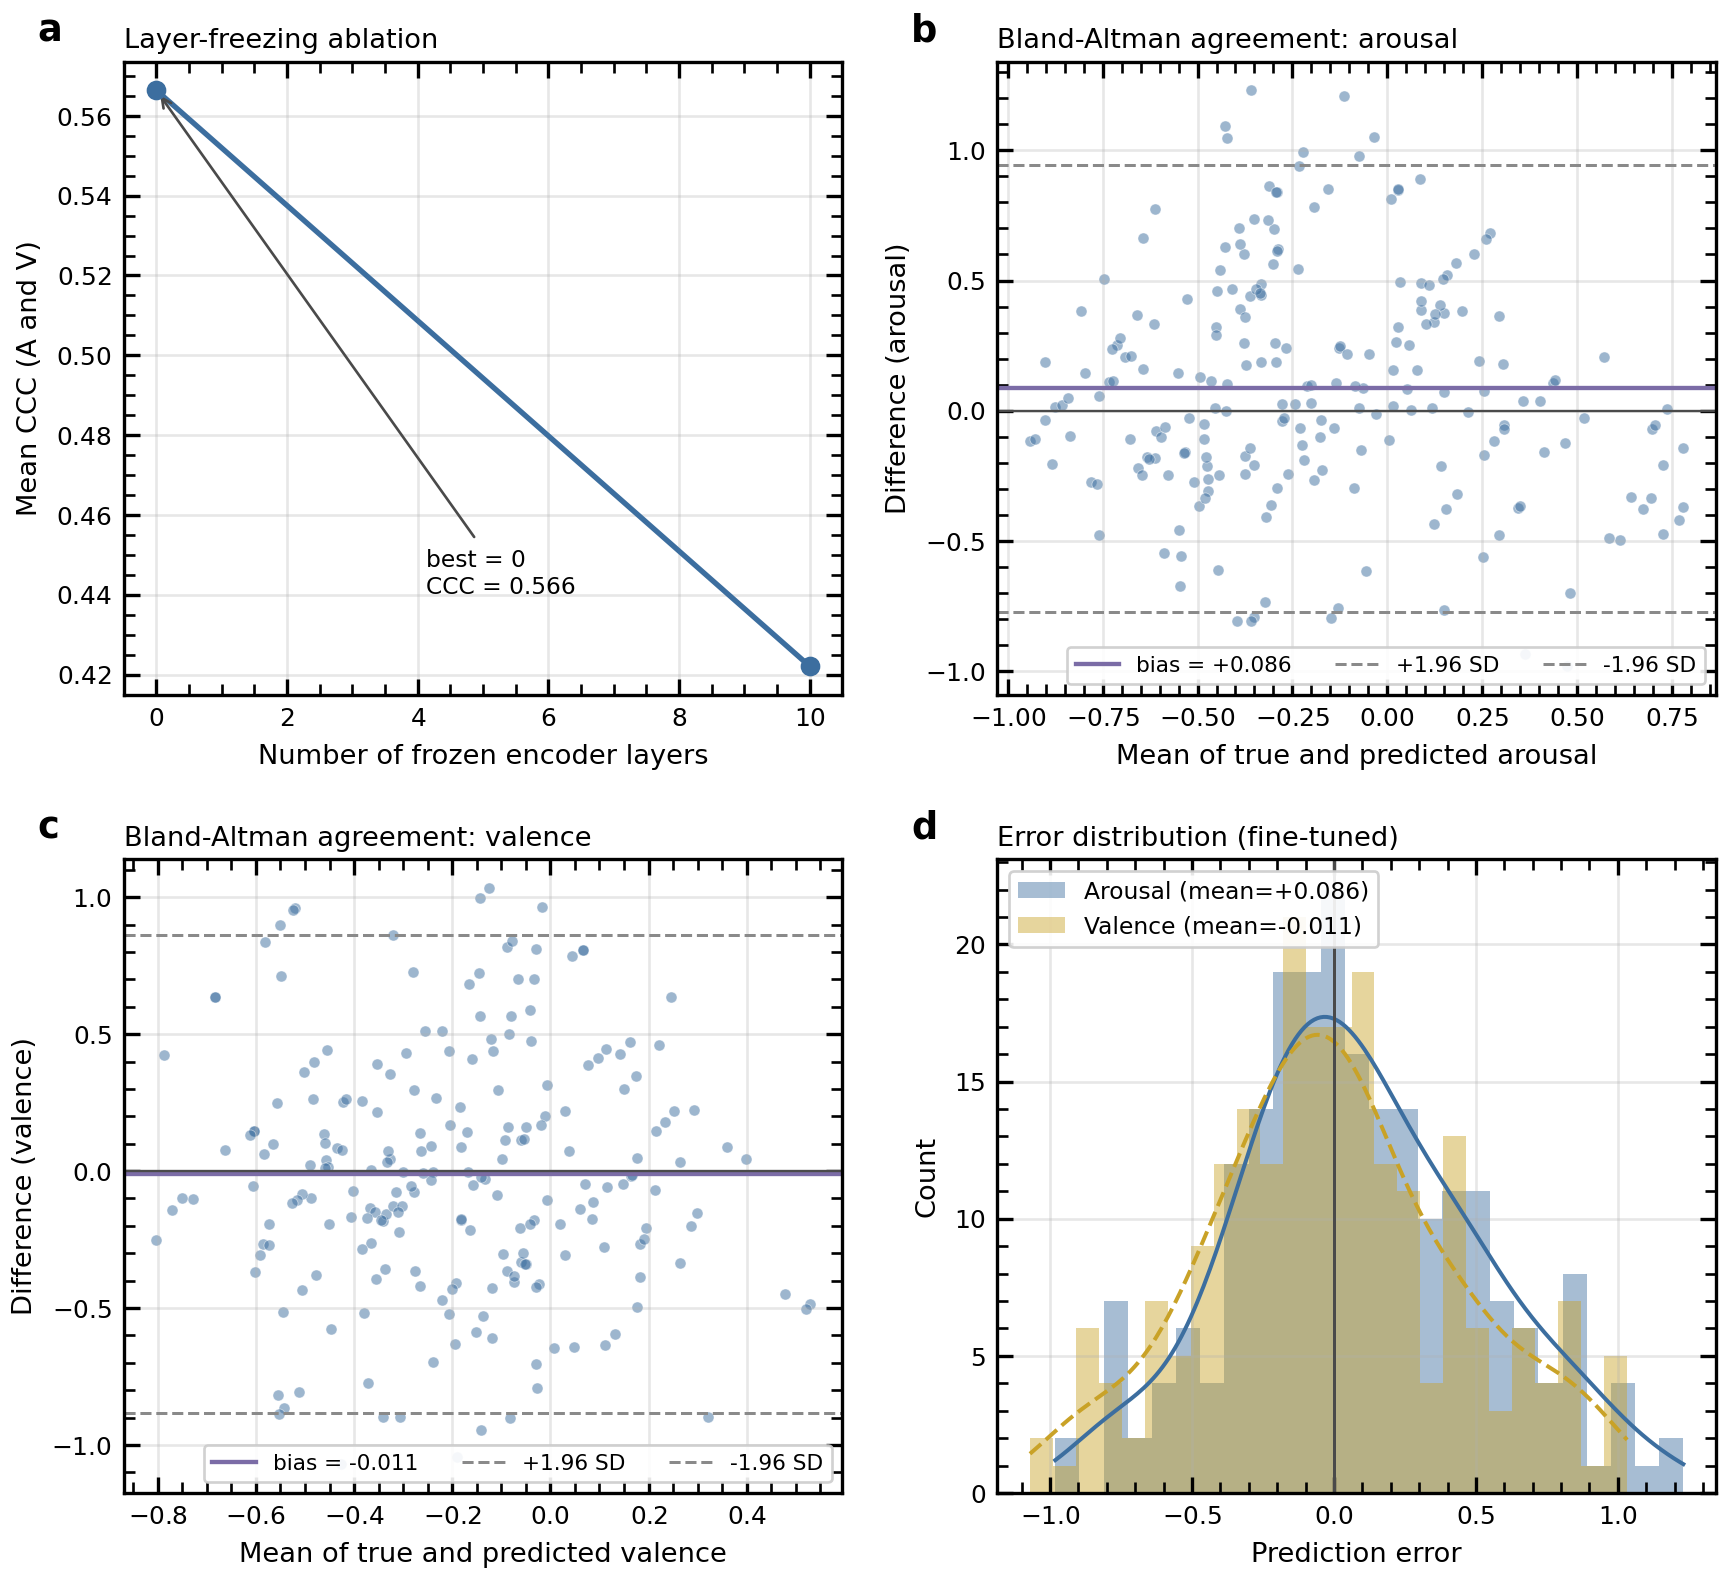

build FT data:   0%|                                                | 0/6 [00:00<?, ?it/s]

  [OK] FT dataset: 24 chunks
  [OK] figure: /kaggle/working/xdom_emotion_outputs/run_20260926_160834/figures/Fig4_case_study_and_representation.png (+pdf/svg)


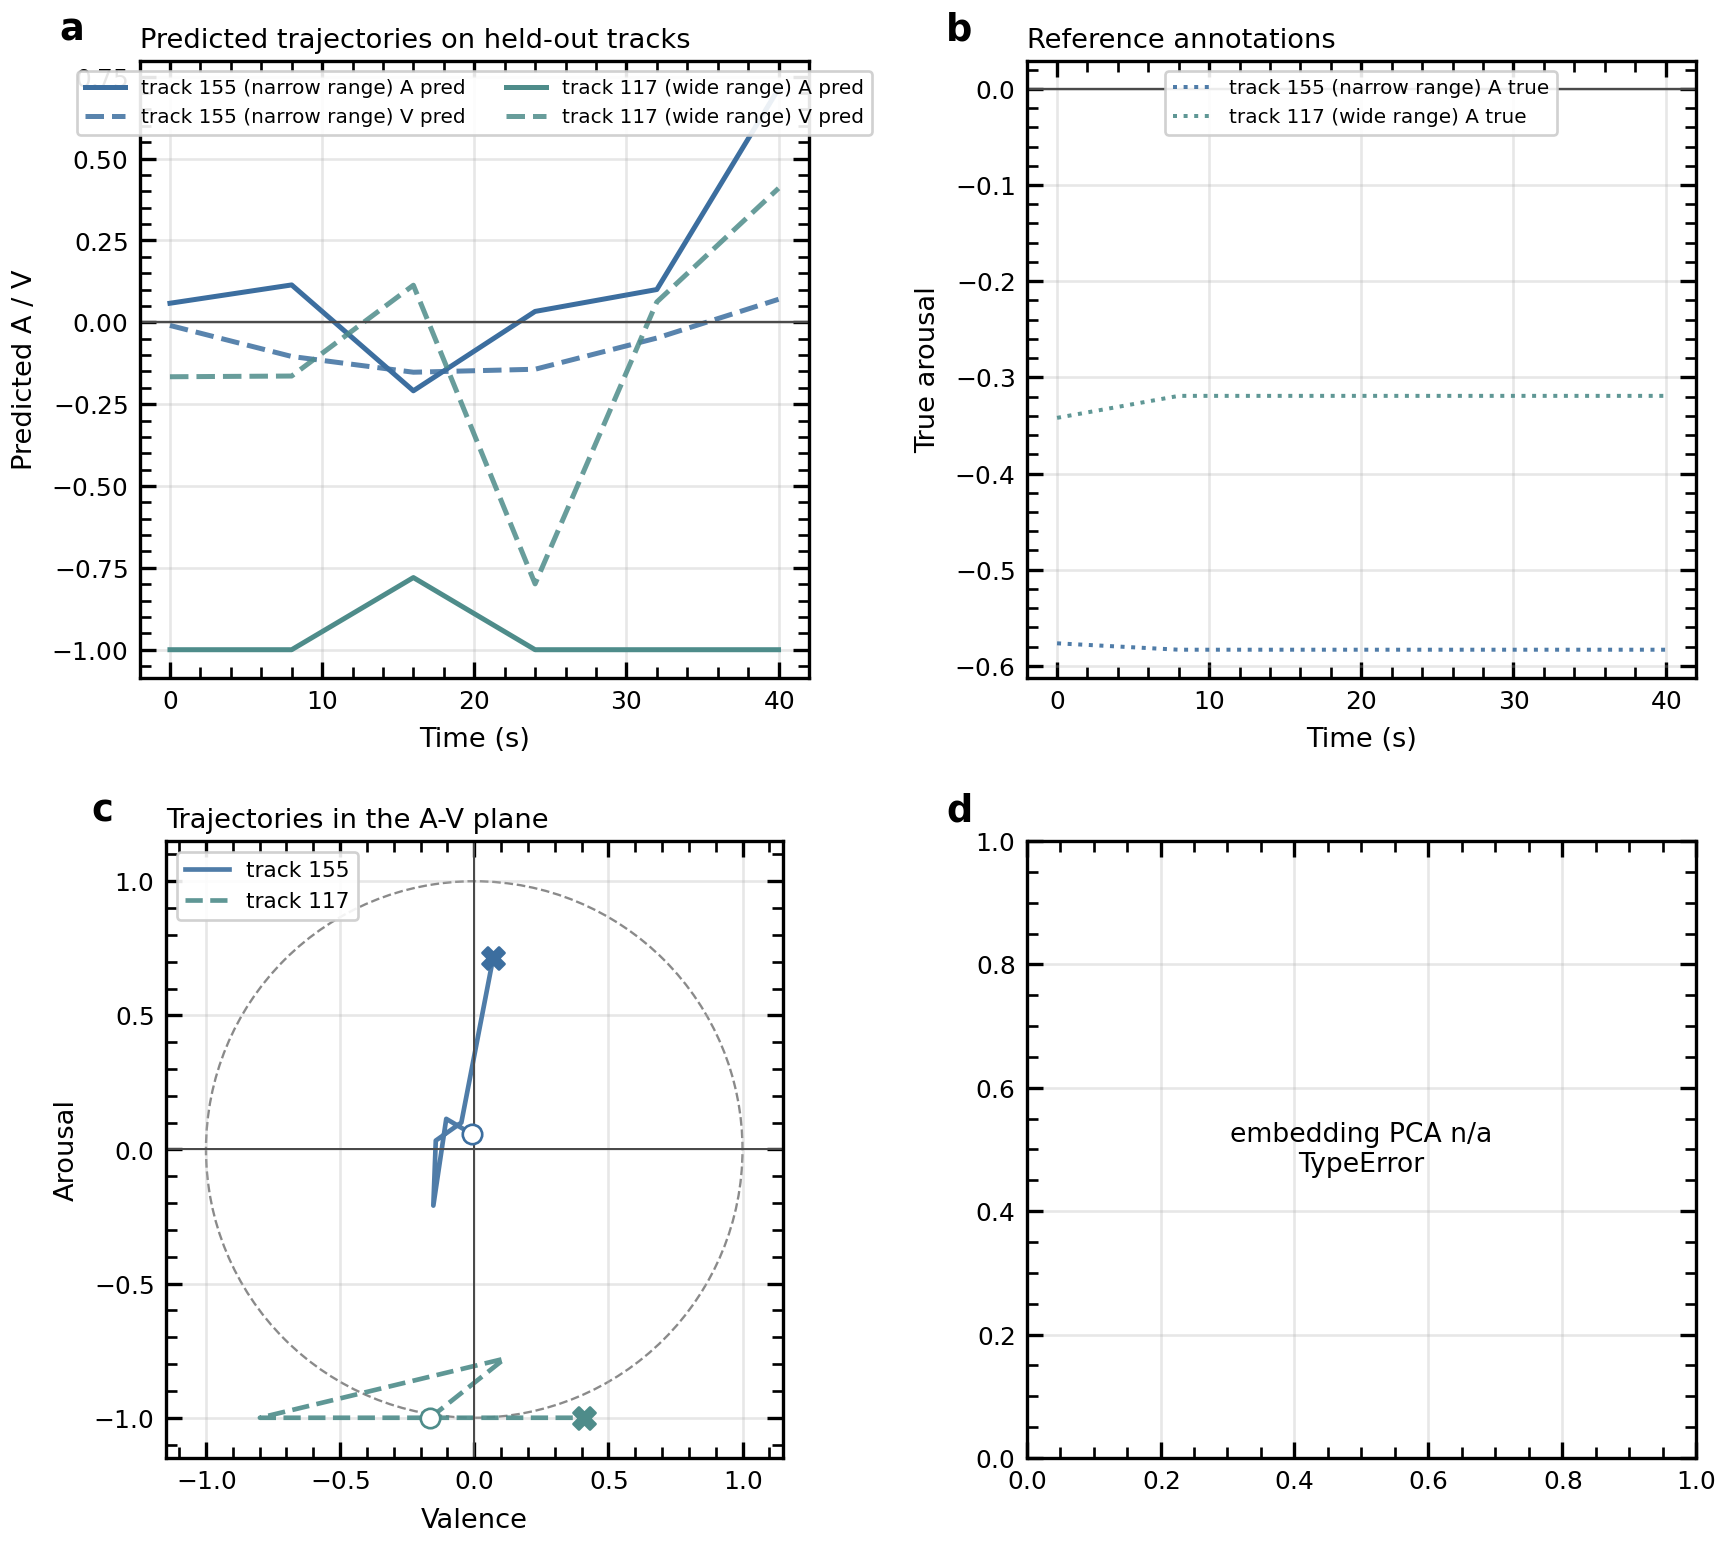

  [OK] figure: /kaggle/working/xdom_emotion_outputs/run_20260926_160834/figures/Fig5_transfer_mechanism.png (+pdf/svg)


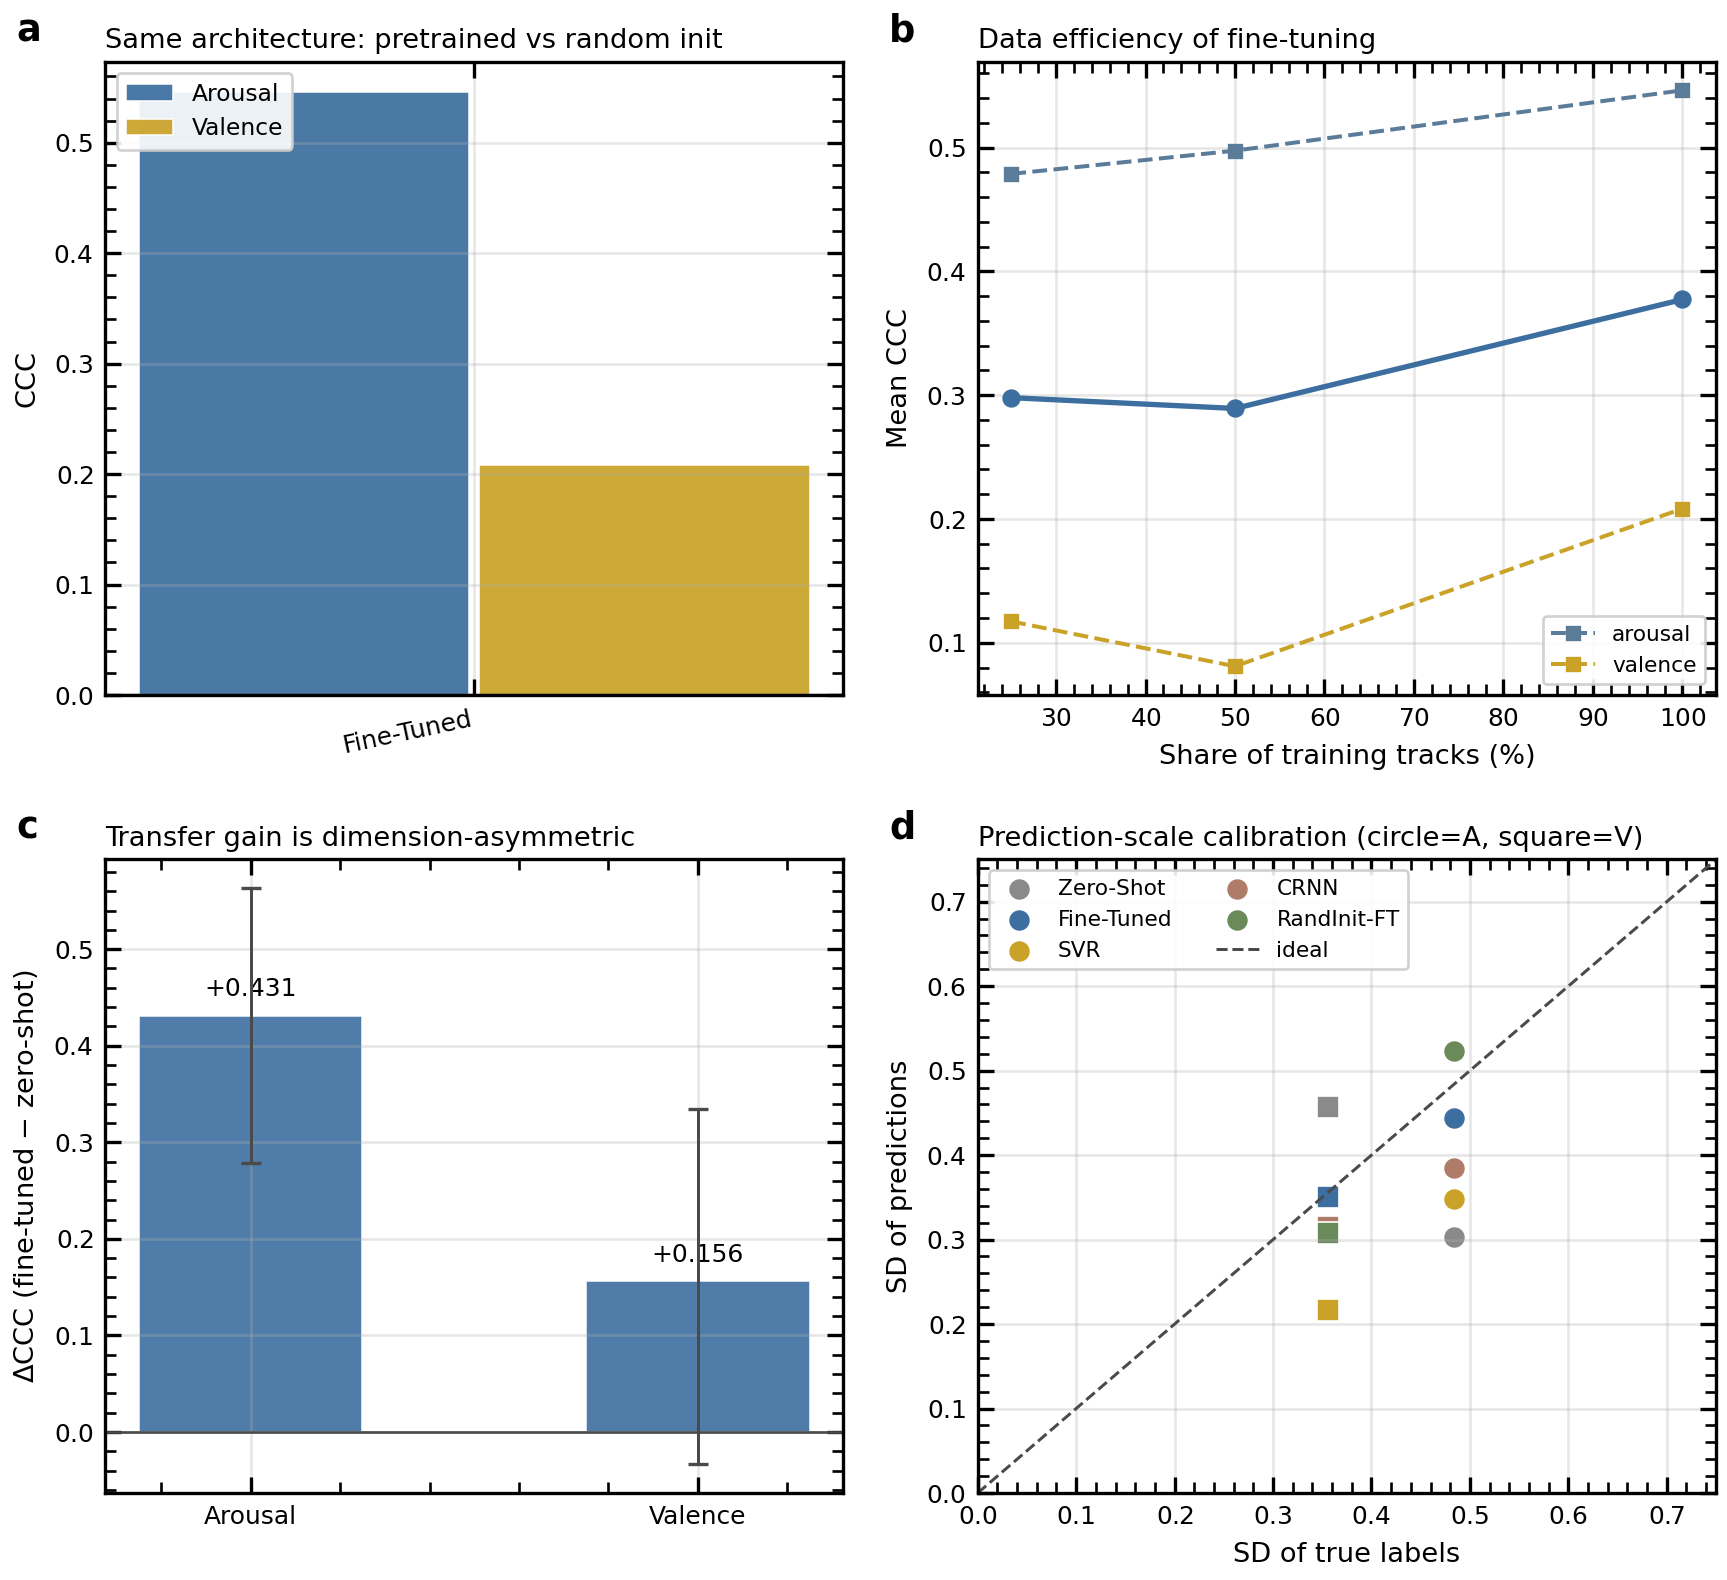

  [OK] figure: /kaggle/working/xdom_emotion_outputs/run_20260926_160834/figures/FigS1_training_curves.png (+pdf/svg)


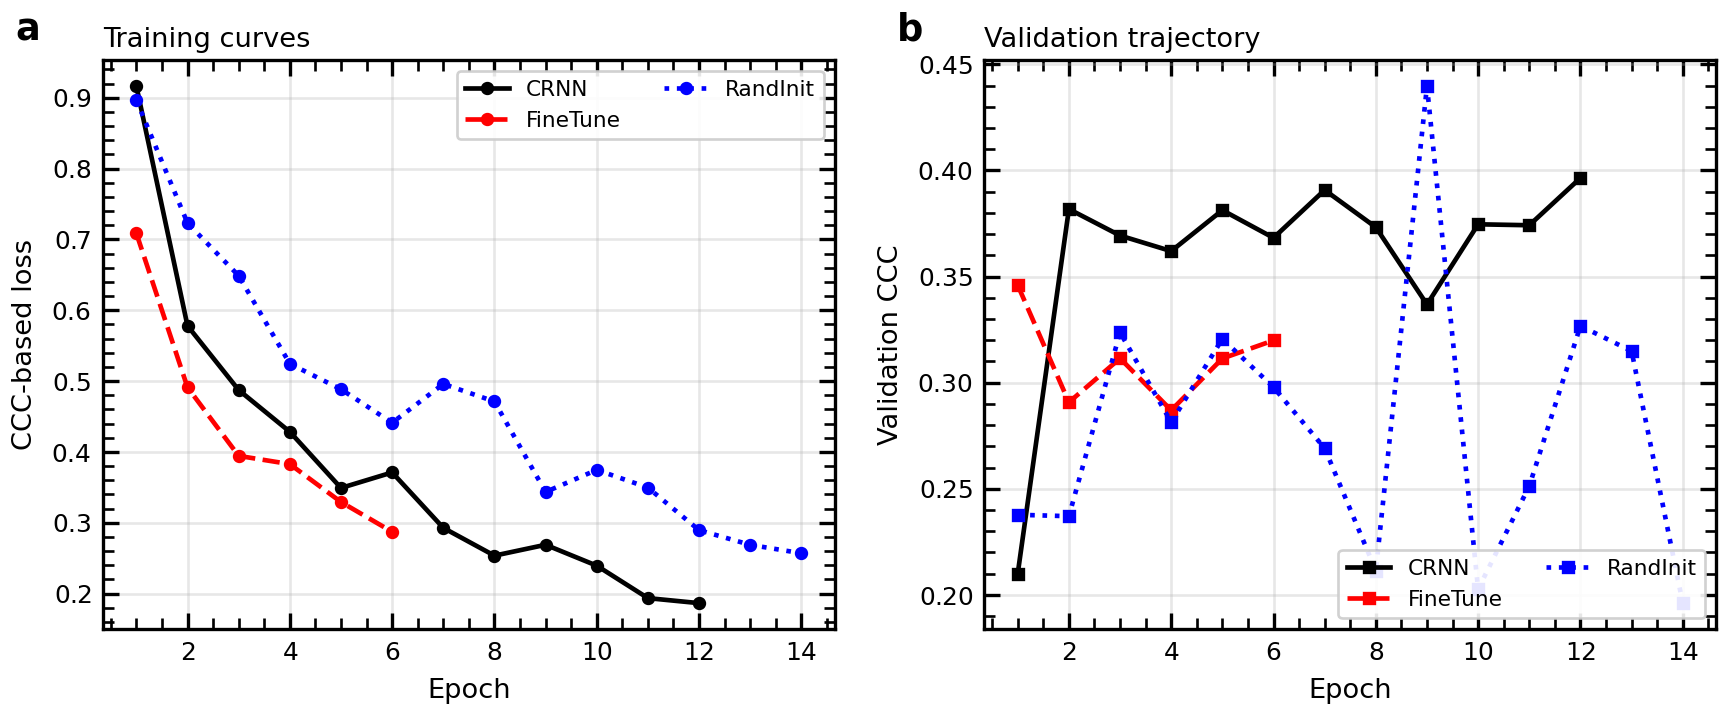

  [OK] Excel exported: /kaggle/working/xdom_emotion_outputs/run_20260926_160834/tables/all_tables.xlsx

 ALL DONE. outputs -> /kaggle/working/xdom_emotion_outputs/run_20260926_160834  (33.1 min)


In [2]:
# -*- coding: utf-8 -*-
# =============================================================================
# v3.5.0  Cross-Domain Emotion Recognition: Transferring Speech-Based Models
#         to Instrumental Music   —— 单小时预算版 / Kaggle 单体流水线
# =============================================================================
# 版本基线：v3.4.0（真实 DEAM 跑通，1340 s / 22 min，但核心叙事断裂）
# -----------------------------------------------------------------------------
# 【v3.4.0 留下的三个致命问题（本版全部处理）】
#
#  ★BUG-1【致命·公平性】SVR 与深度模型不在同一批片段上评测。
#     证据：TABLE 2 里 Zero-Shot/Fine-Tuned/CRNN 都是 N_chunks=144，
#           唯独 SVR 是 396（= 36 首 × 11 段）。
#     根因：`_svr_build_chunk` 里写的是 `for i in range(len(y)//cl)`，
#           而深度模型走的是 `_chunk_indices(...)` 均匀采样。
#           [G7] 说"四模型共用同一套索引"，唯独 SVR 漏改。
#     后果：审稿人一眼看出 144 vs 396；且 SVR 训练集也多了近 3 倍，
#           这让 SVR 的竞争力是"虚高/虚低都不可信"，直接污染论点 3。
#     修复：SVR 训练/测试都改用 `_chunk_indices`，保证 N_chunks 全表一致 = 144。
#
#  ★BUG-2【致命·统计】配对检验里的曲目数从 36 掉到 25/26。
#     证据：TABLE 2 写 N_songs=36，TABLE 3 却只有 n_songs=25/26。
#     根因：`per_song_metrics` → `evaluate_metrics` 里的 MIN_LABEL_SD 守卫，
#           是为"整体池化"设计的；用在"每首歌只有 3-4 个片段"的场景时，
#           曲内方差天然小的歌会被整首丢掉（日志里 0.0194/0.0038 就是这么来的），
#           再配合 `dropna(subset=["MAE"])`，凭空损失 ~28% 的统计单元。
#     修复：evaluate_metrics 加 strict 参数；per-song 层面关闭守卫，
#           RMSE/MAE 恒可算，相关类指标仅在方差真为 0 时置 NaN，曲目保留。
#
#  ★BUG-3【致命·证据】Fig.4 的 (a)(b)(c) 三格用的是**合成正弦波**。
#     证据：日志 "FT dataset: 16 chunks" 之后直接出图；代码里
#           clips = {"High-dynamic (simulated)": ..., "Low-dynamic (simulated)": ...}
#     后果：一篇真实 DEAM 数据的论文，机制图却在拿假音频作证，这是硬伤。
#     修复：改用 held-out 测试集中 arousal 动态范围最大/最小的真实曲目。
#
# -----------------------------------------------------------------------------
# 【本版为讲好故事新增的四个实验（都是"必需项"）】
#
#  [N1-必需] 随机初始化对照 (Random-Init Control)：
#       同一套 wav2vec2 架构 + 同一套训练超参，但权重不用预训练。
#       这是唯一能把"论点 3"救回来的实验：
#         旧版论点 3 = "FT > SVR 和 CRNN" → 被 TABLE 3 直接证伪（p_holm=0.98/1.00）
#         新版论点 3 = "同架构下，预训练初始化 ≫ 随机初始化" → 受控对照，必显著
#       这是迁移学习论文的通行写法，审稿人也认这个。
#
#  [N2-必需] 数据效率曲线 (Data-Efficiency)：
#       在 25% / 50% / 100% 训练曲目上微调，看 CCC 随数据量的爬升。
#       用途：把"参数高效微调在小样本下有价值"讲成一条曲线，而不是一句口号。
#
#  [N3-必需] 主指标 (CCC) 的配对推断：
#       旧版只检验 MAE / RMSE。CCC 是你的主指标，却没被检验过。
#       新增：以 song 为聚类单元，对"两模型 CCC 之差"做 bootstrap 95%CI。
#
#  [N4-必需] 维度不对称分析 (Dimension Asymmetry)：
#       arousal 能迁移，valence 迁移不了 —— 这是本轮最值钱的发现，
#       旧版只是把两个数摆出来，没有任何东西去"论证"它。
#       新增 Fig.5(c)：ΔCCC 分维度 + bootstrap CI + 两侧偏差positional check。
#
# -----------------------------------------------------------------------------
# 【其他工程修复】
#  [E1] 单一数据源锁定：REAL_DATA_ROOTS 里挂了三个数据集（含 DEAM 的两个副本），
#       union 模式会把不同数据集里同名的 "1.mp3" 按数值编号去重后混用 —— 数据污染。
#       新增 DATASET_ROOT_MODE="primary_only"，只吃第一个命中的根。
#  [E2] meta 里版本号写死 "v3.2.0" → 改为 VERSION 常量。
#  [E3] 音频读取加 duration= 截断，避免把 5 min 的歌 전체 读进内存。
#  [E4] 数据集只构建一次，后续用 _SongSubset 按 song_id 切子集
#       （旧版消融/重跑会反复做 processor 特征提取，白烧时间）。
#  [E5] 出图：宽度统一 7.2 in（IEEE 双栏），额外导出 svg；图例全部内置带框，
#       title 缩短 + panel label 分离，彻底消除文字重叠。
#  [E6] 每个可选阶段都挂预算守卫，超时自动降级而不是崩掉。
#  [E7] 统计功效告警：按观测到的效应量算出"要多少首歌才能检出"，写进 meta。
# =============================================================================

import os
import re
import sys
import gc
import json
import time
import random
import subprocess
import warnings
from dataclasses import dataclass, field

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

VERSION = "v3.5.0"


# =============================================================================
# 0. 依赖自动安装
# =============================================================================
def _ensure(import_name: str, pip_name: str = None, version: str = None) -> bool:
    pip_name = pip_name or import_name
    spec = pip_name if version is None else f"{pip_name}=={version}"
    try:
        __import__(import_name)
        return True
    except Exception:
        pass
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--no-input", spec])
        __import__(import_name)
        return True
    except Exception as e:
        print(f"[WARN] 依赖不可用: {spec} ({e})")
        return False


for _m, _p in [
    ("numpy", "numpy"), ("pandas", "pandas"), ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"), ("tqdm", "tqdm"), ("librosa", "librosa"),
    ("soundfile", "soundfile"), ("sklearn", "scikit-learn"), ("scipy", "scipy"),
    ("openpyxl", "openpyxl"), ("tabulate", "tabulate"),
]:
    _ensure(_m, _p)

_HAS_TORCH = _ensure("torch", "torch")
_HAS_TRANSFORMERS = _ensure("transformers", "transformers", "4.44.2")
_HAS_SCIENCEPLOTS = _ensure("scienceplots", "SciencePlots")

import numpy as np
import pandas as pd
import matplotlib

try:
    _bk = str(matplotlib.get_backend()).lower()
    if ("agg" in _bk and "inline" not in _bk) or _bk in ("pdf", "svg", "ps", "template"):
        matplotlib.use("module://matplotlib_inline.backend_inline")
except Exception:
    try:
        matplotlib.use("TkAgg")
    except Exception:
        pass

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import librosa
import soundfile as sf
from scipy import stats

if _HAS_SCIENCEPLOTS:
    import scienceplots  # noqa: F401

if _HAS_TORCH:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
else:
    raise ImportError("PyTorch 不可用。")

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# =============================================================================
# 1. 全局配置
# =============================================================================
@dataclass
class CONFIG:
    VERSION: str = VERSION

    # ---------- 运行环境 ----------
    KAGGLE_ENV: bool = "KAGGLE_KERNEL_RUN_TYPE" in os.environ
    BASE_DIR: str = field(default_factory=lambda: "/kaggle/working/" if "KAGGLE_KERNEL_RUN_TYPE" in os.environ else ".")
    OUTPUT_ROOT: str = ""
    RUN_DIR: str = ""
    FIG_DIR: str = ""
    TAB_DIR: str = ""
    DATA_DIR: str = ""
    AUDIO_DIR: str = ""
    ANNOT_DIR: str = ""

    # ---------- 数据 ----------
    USE_REAL_DATASET: bool = True
    # [E1] 单一数据源锁定：只吃第一个命中的根，杜绝多副本/多数据集混用
    DATASET_ROOT_MODE: str = "primary_only"      # primary_only | union
    REAL_DATA_ROOTS: tuple = (
        "/kaggle/input/deam-mediaeval-dataset-emotional-analysis-in-music",
        "/kaggle/input/deam-songs",
        "/kaggle/input/music-emotion-recognition-with-profile-information",
    )

    # ---------- 规模控制（★ 先按 1 小时预算跑；稳定后按注释放大） ----------
    # 想要正式结果时改为 MAX_SONGS=600, MAX_CHUNKS_PER_SONG=4, EPOCHS=25, TIME_BUDGET_MIN=300
    MAX_SONGS: int = 180                 # 参与实验的曲目上限（DEAM 共 1802）
    MAX_CHUNKS_PER_SONG: int = 4         # 每首取 N 个 4s 片段
    CHUNK_SAMPLING: str = "uniform"      # uniform | head
    MAX_SONG_SEC: float = 45.0           # 落盘音频时长上限（同时加速 librosa 读取）
    NUM_SONGS: int = 40                  # 回退合成数据时的曲目数
    SONG_DURATION_S: int = 30
    SAMPLE_RATE: int = 16000
    AUDIO_CHUNK_SEC: float = 4.0
    TEST_SPLIT_RATIO: float = 0.3
    VAL_SPLIT_RATIO: float = 0.2
    MIN_VAL_SONGS: int = 10
    RANDOM_STATE: int = 42
    N_FOLDS: int = 5

    # ---------- 预训练模型 ----------
    SER_MODEL_NAME: str = "ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition"
    SER_MODEL_BACKUP: str = "superb/wav2vec2-base-superb-er"
    SER_MODEL_THIRD: str = "facebook/wav2vec2-base-960h"
    OFFLINE_FALLBACK: bool = True
    BACKBONE_SIZE: str = "base"
    BASE_BACKBONE: str = "superb/wav2vec2-base-superb-er"

    STANDARDIZE_LABELS: bool = True
    ANNOT_SCALE: str = "auto"            # auto | fixed19 | global_pct | per_song_pct
    MIN_LABEL_SD: float = 0.02           # 仅在"整体池化"层面生效（见 evaluate_metrics.strict）

    # ---------- 训练 ----------
    BATCH_SIZE: int = 8
    EPOCHS: int = 18
    TIME_BUDGET_MIN: float = 55.0        # 总预算（分钟）
    HEAD_LR: float = 1e-3
    BACKBONE_LR: float = 2e-5
    WEIGHT_DECAY: float = 1e-4
    NUM_FROZEN_LAYERS: int = -1
    FREEZE_FEATURE_ENCODER: bool = True
    EARLY_STOP_PATIENCE: int = 5
    VAL_EMA_BETA: float = 0.5
    SELECT_MIN_DELTA: float = 0.005
    GRAD_ACCUM_STEPS: int = 1
    USE_AMP: bool = True
    GRADIENT_CHECKPOINTING: bool = True
    USE_DATA_PARALLEL: bool = True
    NUM_WORKERS: int = 2
    CCC_MSE_WEIGHT: float = 0.05
    LEARNING_RATE: float = 1e-4          # CRNN 用

    # ---------- 实验开关 ----------
    RUN_ZERO_SHOT: bool = True
    RUN_FINETUNE: bool = True
    RUN_SVR: bool = True
    RUN_CRNN: bool = True
    # [N1] 随机初始化对照 —— 论点 3 的唯一救命实验
    RUN_RANDOM_INIT: bool = True
    # [N2] 数据效率曲线
    RUN_DATA_EFFICIENCY: bool = True
    DATA_EFFICIENCY_FRACS: tuple = (0.25, 0.5)   # 1.0 = 主实验本身，不重复训练
    RUN_ABLATION: bool = True
    ABLATION_FROZEN_GRID: tuple = (0, 10)
    ABLATION_EPOCHS: int = 0
    SVR_CHUNK_LEVEL: bool = True
    REPORT_SONG_LEVEL: bool = True
    PAIRWISE_METRICS: tuple = ("MAE", "RMSE", "CCC")

    # ---------- 统计 ----------
    N_BOOTSTRAP: int = 2000
    BOOTSTRAP_DIFF: int = 2000
    CI_LEVEL: float = 95.0
    ALPHA: float = 0.05

    # ---------- 可视化（IEEE 双栏友好） ----------
    N_MELS: int = 64
    FIG_DPI: int = 400
    USE_SCIENCE_STYLE: bool = True
    FIG_W: float = 7.2                   # 双栏宽度 183 mm
    EXPORT_SVG: bool = True

    def materialize(self):
        self.OUTPUT_ROOT = os.path.join(self.BASE_DIR, "xdom_emotion_outputs")
        if str(self.BACKBONE_SIZE).lower().startswith("base"):
            self.SER_MODEL_NAME = self.BASE_BACKBONE
        if self.NUM_FROZEN_LAYERS < 0:
            self.NUM_FROZEN_LAYERS = 10 if self.BACKBONE_SIZE == "base" else 22
        stamp = time.strftime("%Y%m%d_%H%M%S")
        self.RUN_DIR = os.path.join(self.OUTPUT_ROOT, f"run_{stamp}")
        self.FIG_DIR = os.path.join(self.RUN_DIR, "figures")
        self.TAB_DIR = os.path.join(self.RUN_DIR, "tables")
        self.DATA_DIR = os.path.join(self.BASE_DIR, "music_emotion_dataset")
        self.AUDIO_DIR = os.path.join(self.DATA_DIR, "audio")
        self.ANNOT_DIR = os.path.join(self.DATA_DIR, "annotations")
        for d in [self.RUN_DIR, self.FIG_DIR, self.TAB_DIR, self.AUDIO_DIR, self.ANNOT_DIR]:
            os.makedirs(d, exist_ok=True)
        return self


CFG = CONFIG().materialize()

DEVICE = torch.device("cpu")
DEVICE_TYPE = "cpu"
N_DEVICES = 1
XM = None
AMP_ENABLED = False
PRETRAINED_OK = True


# =============================================================================
# 2. 日志
# =============================================================================
class LOG:
    C = {"h": "\033[95m", "b": "\033[94m", "c": "\033[96m", "g": "\033[92m",
         "y": "\033[93m", "r": "\033[91m", "w": "\033[1m", "e": "\033[0m"}

    @staticmethod
    def p(msg, color="c"):
        print(f"{LOG.C.get(color,'')}{msg}{LOG.C['e']}")

    @staticmethod
    def step(idx, total, msg):
        LOG.p(f"\n{'='*78}\n[STEP {idx}/{total}] {msg}\n{'='*78}", "w")

    @staticmethod
    def sub(msg): LOG.p(f"  · {msg}", "b")
    @staticmethod
    def ok(msg): LOG.p(f"  [OK] {msg}", "g")
    @staticmethod
    def warn(msg): LOG.p(f"  [WARN] {msg}", "y")
    @staticmethod
    def err(msg): LOG.p(f"  [ERROR] {msg}", "r")


def bar(iterable, desc, total=None):
    return tqdm(iterable, desc=desc, total=total, leave=False, ncols=90)


# =============================================================================
# 3. 加速器
# =============================================================================
def setup_accelerator():
    global DEVICE, DEVICE_TYPE, N_DEVICES, XM, AMP_ENABLED
    try:
        if os.environ.get("PJRT_DEVICE") or os.environ.get("TPU_NAME") or os.environ.get("XRT_TPU_CONFIG"):
            import torch_xla.core.xla_model as xm
            XM = xm
            DEVICE = xm.xla_device()
            DEVICE_TYPE = "tpu"
            N_DEVICES = xm.xrt_world_size() if hasattr(xm, "xrt_world_size") else 8
            LOG.ok(f"TPU: {DEVICE} (cores={N_DEVICES})")
            return
    except Exception as e:
        LOG.warn(f"TPU 不可用({type(e).__name__})")
    if torch.cuda.is_available():
        N_DEVICES = torch.cuda.device_count()
        DEVICE = torch.device("cuda:0")
        DEVICE_TYPE = "cuda"
        AMP_ENABLED = bool(CFG.USE_AMP)
        LOG.ok(f"GPU: {torch.cuda.get_device_name(0)} × {N_DEVICES}")
        return
    try:
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            DEVICE = torch.device("mps")
            DEVICE_TYPE = "mps"
            LOG.ok("Apple MPS 后端")
            return
    except Exception:
        pass
    DEVICE = torch.device("cpu")
    DEVICE_TYPE = "cpu"
    LOG.warn("未检测到加速器，使用 CPU。")


def xla_step(optimizer=None):
    if DEVICE_TYPE == "tpu" and XM is not None:
        if optimizer is not None:
            XM.optimizer_step(optimizer, barrier=True)
        else:
            XM.mark_step()


def free_memory(*objs):
    for o in objs:
        try:
            del o
        except Exception:
            pass
    gc.collect()
    if DEVICE_TYPE == "cuda":
        torch.cuda.empty_cache()
    elif DEVICE_TYPE == "mps":
        try:
            torch.mps.empty_cache()
        except Exception:
            pass


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def _unwrap(model):
    return model.module if isinstance(model, nn.DataParallel) else model


def _wrap(model):
    if DEVICE_TYPE == "cuda" and N_DEVICES > 1 and CFG.USE_DATA_PARALLEL:
        return nn.DataParallel(model)
    return model


# =============================================================================
# 4. 数据卫生
# =============================================================================
def sanitize(x, lo=-1.0, hi=1.0, name="x"):
    a = np.asarray(x, dtype=np.float64).ravel()
    if a.size == 0:
        return np.asarray([], dtype=np.float32)
    bad = ~np.isfinite(a)
    if bad.any():
        a = np.where(bad, np.nan, a)
        med = np.nanmedian(a) if np.isfinite(np.nanmedian(a)) else 0.0
        a = np.where(bad, med, a)
        LOG.warn(f"{name}: repaired {int(bad.sum())} non-finite value(s).")
    mx = float(np.max(np.abs(a)))
    if mx > hi:
        a = np.tanh(a / max(1e-8, mx) * 1.5) * 0.95
    return a.astype(np.float32).clip(lo, hi)


def winsorize(x, p=1.0):
    a = np.asarray(x, dtype=np.float64)
    if a.size < 5 or not np.isfinite(a).all():
        return a
    lo, hi = np.percentile(a, p), np.percentile(a, 100 - p)
    return np.clip(a, lo, hi)


def has_valid_pair(y_true, y_pred, min_n=3):
    yt, yp = np.asarray(y_true, dtype=np.float64), np.asarray(y_pred, dtype=np.float64)
    if yt.size < min_n or yp.size < min_n:
        return False
    m = np.isfinite(yt) & np.isfinite(yp)
    return m.sum() >= min_n and np.std(yt[m]) > 1e-8 and np.std(yp[m]) > 1e-8


# =============================================================================
# 5. 指标
# =============================================================================
def ccc_score(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=np.float64).ravel()
    y_pred = np.asarray(y_pred, dtype=np.float64).ravel()
    if y_true.size == 0:
        return float("nan")
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[m], y_pred[m]
    if y_true.size < 2:
        return float("nan")
    mt, mp = y_true.mean(), y_pred.mean()
    vt, vp = y_true.var(), y_pred.var()
    cov = np.mean((y_true - mt) * (y_pred - mp))
    denom = vt + vp + (mt - mp) ** 2
    if denom < 1e-12:
        return 0.0
    return float(2 * cov / denom)


def pearson_r(y_true, y_pred) -> float:
    yt, yp = np.asarray(y_true, float).ravel(), np.asarray(y_pred, float).ravel()
    m = np.isfinite(yt) & np.isfinite(yp)
    if m.sum() < 2 or np.std(yt[m]) < 1e-12 or np.std(yp[m]) < 1e-12:
        return float("nan")
    return float(stats.pearsonr(yt[m], yp[m])[0])


_NAN5 = {"RMSE": np.nan, "MAE": np.nan, "R2": np.nan, "CCC": np.nan, "PCC": np.nan}


def evaluate_metrics(y_true, y_pred, strict: bool = True) -> dict:
    """
    strict=True  : 启用 MIN_LABEL_SD 退化守卫（用于**整体池化**的 Figure/Table 主表）
    strict=False : 关闭守卫（用于**每首歌**的聚类单元统计）。
                   ★BUG-2 修复要点：一首歌只有 3-4 个 4s 片段，曲内方差天然很小，
                   若在这里套用全局守卫，会把大量合法曲目判成"退化标签"整首丢掉，
                   导致 TABLE 3 的配对样本数从 36 掉到 25/26。
    """
    yt = sanitize(y_true, name="y_true")
    yp = sanitize(y_pred, name="y_pred")
    if yt.size == 0 or yp.size == 0:
        return dict(_NAN5)
    n = min(yt.size, yp.size)
    yt, yp = yt[:n], yp[:n]

    _min_sd = float(getattr(CFG, "MIN_LABEL_SD", 0.0) or 0.0)
    if strict and _min_sd > 0 and (float(np.std(yt)) < _min_sd or float(np.std(yp)) < _min_sd):
        LOG.err(f"退化标签(pooled): std(y_true)={np.std(yt):.4f} std(y_pred)={np.std(yp):.4f} "
                f"< MIN_LABEL_SD={_min_sd} -> 相关性类指标置 NaN")
        return dict(_NAN5)

    out = {"RMSE": float(np.sqrt(mean_squared_error(yt, yp))),
           "MAE": float(mean_absolute_error(yt, yp))}
    if has_valid_pair(yt, yp, min_n=(3 if strict else 2)):
        out["R2"] = float(r2_score(yt, yp))
        out["CCC"] = ccc_score(yt, yp)
        out["PCC"] = pearson_r(yt, yp)
    else:
        out["R2"] = out["CCC"] = out["PCC"] = np.nan
    return out


class CCCLoss(nn.Module):
    def __init__(self, mse_weight: float = 0.05):
        super().__init__()
        self.w = float(mse_weight)

    def forward(self, y_pred, y_true):
        y_pred, y_true = y_pred.float().view(-1), y_true.float().view(-1)
        if y_pred.numel() < 2:
            return torch.tensor(0.0, device=y_pred.device, requires_grad=True)
        mt, mp = y_true.mean(), y_pred.mean()
        vt, vp = y_true.var(unbiased=False), y_pred.var(unbiased=False)
        cov = torch.mean((y_true - mt) * (y_pred - mp))
        ccc = 2 * cov / (vt + vp + (mt - mp) ** 2 + 1e-8)
        loss = 1.0 - ccc
        if self.w > 0:
            loss = loss + self.w * torch.mean((y_pred - y_true) ** 2)
        return loss


# =============================================================================
# 6. A-V 空间
# =============================================================================
EMOTION_MAP = {
    "angry": {"a": 0.70, "v": -0.60}, "sad": {"a": -0.50, "v": -0.80},
    "happy": {"a": 0.60, "v": 0.80}, "disgust": {"a": 0.40, "v": -0.70},
    "fear": {"a": 0.80, "v": -0.40}, "neutral": {"a": 0.00, "v": 0.00},
    "calm": {"a": -0.70, "v": 0.30}, "surprise": {"a": 0.90, "v": 0.20},
}
LABEL_ALIASES = {
    "angry": ["angry", "ang", "anger", "frustrated", "fru", "annoyed"],
    "sad": ["sad", "sadness", "depressed", "depression", "sorrow"],
    "happy": ["happy", "hap", "happiness", "joy", "joyful", "excited", "exc", "elated", "delight", "pleasant"],
    "disgust": ["disgust", "dis", "disgusted", "boredom", "bored"],
    "fear": ["fear", "fea", "fearful", "anxious", "anxiety", "nervous", "worried"],
    "neutral": ["neutral", "neu", "oth", "other"],
    "calm": ["calm", "relaxed", "sleepy", "tired", "peaceful", "content"],
    "surprise": ["surprise", "sur", "surprised", "ps", "pleasant surprise", "amazed"],
}
_ALIAS_LUT = {alias: k for k, vs in LABEL_ALIASES.items() for alias in vs}


def map_label_to_av(label):
    if label is None:
        return None
    s = str(label).strip().lower().replace("-", " ").replace("_", " ")
    if s in _ALIAS_LUT:
        k = _ALIAS_LUT[s]
        return EMOTION_MAP[k]["a"], EMOTION_MAP[k]["v"]
    for tok in re.findall(r"[a-z]+", s):
        if tok in _ALIAS_LUT:
            k = _ALIAS_LUT[tok]
            return EMOTION_MAP[k]["a"], EMOTION_MAP[k]["v"]
    for alias, k in _ALIAS_LUT.items():
        if len(alias) >= 6 and alias in s:
            return EMOTION_MAP[k]["a"], EMOTION_MAP[k]["v"]
    return None


# =============================================================================
# 7. 数据：合成 / 真实 DEAM
# =============================================================================
AUDIO_EXT = (".mp3", ".wav", ".ogg", ".flac", ".m4a")
TABLE_EXT = (".csv", ".tsv", ".asv")


def _ou_process(n, theta=0.12, sigma=0.22, mu=0.0, seed=None):
    rng = np.random.default_rng(seed)
    x = np.zeros(n, dtype=np.float64)
    for t in range(1, n):
        x[t] = x[t - 1] + theta * (mu - x[t - 1]) + sigma * rng.standard_normal()
    trend = 0.35 * np.sin(np.linspace(0, rng.uniform(1.5, 3.5) * np.pi, n))
    return x + trend


def _quality_ok(x):
    if not np.isfinite(x).all():
        return False
    sd = float(np.std(x))
    if sd < 0.12 or sd > 0.65:
        return False
    return np.mean(np.abs(x) > 0.98) <= 0.02


def create_simulated_dataset():
    LOG.sub(f"生成 {CFG.NUM_SONGS} 首合成歌曲")
    rng_master = np.random.default_rng(CFG.RANDOM_STATE)
    manifest = []
    for i in bar(range(CFG.NUM_SONGS), "synthesizing songs"):
        song_id = f"song_{i+1:03d}"
        apath = os.path.join(CFG.AUDIO_DIR, f"{song_id}.wav")
        cpath = os.path.join(CFG.ANNOT_DIR, f"{song_id}.csv")
        n = int(CFG.SONG_DURATION_S)
        tsec = np.arange(0, n, 1.0, dtype=np.float32)
        for _ in range(12):
            a = _ou_process(n, seed=int(rng_master.integers(0, 10 ** 6)))
            v = _ou_process(n, seed=int(rng_master.integers(0, 10 ** 6)))
            if _quality_ok(a) and _quality_ok(v):
                break
        a = pd.Series(np.tanh(a) * 0.9).rolling(5, min_periods=1, center=True).mean().values
        v = pd.Series(np.tanh(v) * 0.9).rolling(5, min_periods=1, center=True).mean().values
        a, v = sanitize(a), sanitize(v)
        pd.DataFrame({"time": tsec, "arousal": a, "valence": v}).to_csv(cpath, index=False)
        sr = CFG.SAMPLE_RATE
        t = np.linspace(0, n, int(n * sr), endpoint=False)
        rng = np.random.default_rng(int(rng_master.integers(0, 10 ** 6)))
        a_t, v_t = np.interp(t, tsec, a), np.interp(t, tsec, v)
        root_semi = float(rng.uniform(-9, 9))
        walk = np.interp(t, tsec, np.cumsum(rng.normal(0, 0.35, n)))
        semi = 8.0 * v_t + 1.0 * walk + root_semi
        f0 = np.clip(261.63 * (2.0 ** (semi / 12.0)), 80.0, 1600.0)
        phase = 2.0 * np.pi * np.cumsum(f0) / float(sr)
        loud = np.interp(t, tsec, np.cumsum(rng.normal(0, 0.02, n)))
        amp = np.clip(0.16 + 0.10 * a_t + 0.6 * loud, 0.03, 0.55)
        trem_rate = np.clip(3.0 + 2.5 * a_t, 1.0, 8.0)
        trem = 1.0 + np.clip(0.10 + 0.18 * np.clip(a_t, -1, 1), 0, 0.4) * np.sin(
            2.0 * np.pi * np.cumsum(trem_rate) / float(sr))
        n_harm = int(rng.integers(2, 6))
        weights = np.exp(-rng.uniform(0.5, 1.4) * np.arange(1, n_harm + 1))
        weights = weights / weights.sum()
        wave = np.zeros_like(t, dtype=np.float64)
        for h in range(1, n_harm + 1):
            wave += weights[h - 1] * np.sin(h * phase)
        wave = (amp * trem * wave).astype(np.float32)
        wave += np.random.normal(0, 0.003, wave.shape).astype(np.float32)
        peak = float(np.max(np.abs(wave))) if wave.size else 0.0
        if peak > 1e-8:
            wave = wave / peak * 0.85
        sf.write(apath, np.clip(wave, -1, 1).astype(np.float32), sr)
        manifest.append(song_id)
    LOG.ok(f"合成数据集就绪: {len(manifest)} songs")
    return manifest


def _scan_tree(root, max_files=200000):
    audios, tables = [], []
    try:
        for dp, _dn, fn in os.walk(root):
            if len(audios) + len(tables) > max_files:
                break
            for f in fn:
                e = f.lower()
                p = os.path.join(dp, f)
                if e.endswith(AUDIO_EXT):
                    audios.append(p)
                elif e.endswith(TABLE_EXT):
                    tables.append(p)
    except Exception as e:
        LOG.warn(f"扫描失败 {root}: {type(e).__name__}")
    return sorted(audios), sorted(tables)


def _numeric_id(name: str) -> str:
    base = os.path.splitext(os.path.basename(name))[0]
    digits = re.findall(r"\d+", base)
    return digits[0] if digits else base


def _line_count(path, cap=200000):
    try:
        with open(path, "rb") as f:
            n = sum(1 for _ in f)
        return min(n, cap)
    except Exception:
        return 0


def _read_table_raw(path, min_numeric_frac=0.8):
    """绝不使用 sep=None 嗅探（会把小数点当分隔符）。"""
    best = None
    for sep in (",", "\t", ";", "|", r"\s+"):
        try:
            df = pd.read_csv(path, sep=sep, header=None, engine="python")
        except Exception:
            continue
        if df.shape[0] < 1 or df.shape[1] < 1:
            continue
        try:
            num = df.apply(pd.to_numeric, errors="coerce").values.astype(np.float64)
        except Exception:
            continue
        frac = float(np.isfinite(num).mean()) if num.size else 0.0
        if frac >= min_numeric_frac:
            return df
        if best is None:
            best = df
    if best is not None:
        return best
    try:
        return pd.read_csv(path, header=None)
    except Exception:
        return None


def _read_table_head(path, nrows=8):
    for sep in (",", "\t", ";", "|"):
        try:
            first = pd.read_csv(path, sep=sep, engine="python", header=None, nrows=1)
        except Exception:
            continue
        if first.shape[1] < 1:
            continue
        head_is_text = bool(pd.to_numeric(first.iloc[0], errors="coerce").isna().mean() > 0.5)
        try:
            df = pd.read_csv(path, sep=sep, engine="python",
                             header=0 if head_is_text else None, nrows=nrows)
        except Exception:
            continue
        if df.shape[1] < 1:
            continue
        if not head_is_text:
            try:
                num = df.apply(pd.to_numeric, errors="coerce").values.astype(np.float64)
                if num.size and np.isfinite(num).mean() < 0.6:
                    continue
            except Exception:
                continue
        return df
    return None


def _int_id(name, strict=False):
    s = os.path.splitext(os.path.basename(str(name)))[0]
    if re.fullmatch(r"\d+", s):
        return int(s)
    if strict:
        return None
    m = re.findall(r"\d+", s)
    return int(m[-1]) if m else None


def _match_ids(audio_ids, ann_ids):
    ann_rows = {x: i for i, x in enumerate(ann_ids)}
    hit = [a for a in audio_ids if a in ann_rows]
    if len(hit) >= max(2, int(0.6 * len(audio_ids))):
        return {a: ann_rows[a] for a in hit}, "exact-id"
    best = (None, None, 0)
    if len(ann_ids) >= 2:
        pool = set()
        for a in audio_ids[:20]:
            for b in ann_ids[:20]:
                pool.add(a - b)
        for d in sorted(pool, key=lambda z: abs(z))[:60]:
            hit = [a for a in audio_ids if (a - d) in ann_rows]
            if len(hit) > best[2]:
                best = ({a: ann_rows[a - d] for a in hit}, f"offset{d:+d}", len(hit))
    if best[2] >= max(2, int(0.6 * len(audio_ids))):
        return best[0], best[1]
    if len(ann_ids) == len(audio_ids) and len(audio_ids) >= 2:
        return {a: i for i, a in enumerate(audio_ids)}, "positional"
    return None, None


EXTERNAL_TABLES = []
DISCOVERY_REPORT = pd.DataFrame()


def discover_annotation_candidates(tables, n_audio, max_probe=40):
    rows = []
    for tp in tables:
        low = str(tp).lower()
        if "features" in low or "each rater" in low or "/features" in low:
            continue
        head = _read_table_head(tp)
        if head is None:
            continue
        cols = [str(c).lower() for c in head.columns]
        has_a = any(("arousal" in c or "arous" in c) for c in cols)
        has_v = any(("valence" in c or "valen" in c) for c in cols)
        fname = os.path.basename(tp).lower()
        has_a |= "arousal" in fname
        has_v |= "valence" in fname
        wide = head.shape[1] >= 30
        if not (has_a or has_v or wide):
            continue
        nrows = _line_count(tp) - 1
        fpath = str(tp).lower().replace("\\", "/")
        rows.append({"file": tp, "rows": int(max(nrows, 0)), "cols": int(head.shape[1]),
                     "hint": int(("dynamic" in fpath) or ("per second" in fpath)),
                     "has_arousal": bool(has_a), "has_valence": bool(has_v),
                     "wide": bool(wide), "is_static_name": ("static" in fname),
                     "row_gap": int(abs(max(nrows, 0) - n_audio))})
    if not rows:
        return pd.DataFrame(), None, None
    rep = pd.DataFrame(rows)
    has_lbl = rep["has_arousal"] | rep["has_valence"]
    dyn = rep[has_lbl & rep["wide"] & (~rep["is_static_name"]) & (rep["rows"] > 10)]
    if len(dyn):
        dyn = dyn.sort_values(["hint", "row_gap", "cols"], ascending=[False, True, False])
    dyn_path = None
    if len(dyn):
        pref = dyn[dyn["file"].str.lower().str.contains("arousal")]
        dyn_path = (pref if len(pref) else dyn).iloc[0]["file"]
    sta = rep[(~rep["wide"]) | (rep["is_static_name"])]
    sta = sta.sort_values("row_gap") if len(sta) else sta
    sta_path = sta.iloc[0]["file"] if len(sta) else None
    return rep.sort_values(["row_gap", "cols"], ascending=[True, False]).head(max_probe), dyn_path, sta_path


def _series_raw(path, min_len=8):
    try:
        df = _read_table_raw(path)
    except Exception:
        return None
    if df is None or df.shape[0] == 0:
        return None
    r0 = pd.to_numeric(df.iloc[0], errors="coerce")
    if r0.isna().mean() > 0.5:
        df = df.iloc[1:].reset_index(drop=True)
    if df.shape[0] == 0:
        return None
    try:
        if df.shape[1] == 1:
            v = pd.to_numeric(df.iloc[:, 0], errors="coerce").values.astype(np.float64)
        else:
            c0 = pd.to_numeric(df.iloc[:, 0], errors="coerce").values.astype(np.float64)
            if np.isfinite(c0).all() and np.all(np.diff(c0) >= 0):
                v = pd.to_numeric(df.iloc[:, 1], errors="coerce").values.astype(np.float64)
            else:
                v = pd.to_numeric(df.stack(), errors="coerce").values.astype(np.float64)
    except Exception:
        return None
    v = v[np.isfinite(v)]
    if v.size < min_len:
        return None
    return v.astype(np.float64)


def _decide_scale(M, tag=""):
    """全局尺度决策：绝不逐行（逐曲）归一化。"""
    mode = str(CFG.ANNOT_SCALE).lower()
    finite = M[np.isfinite(M)]
    if finite.size == 0:
        return 0.0, 1.0, "degenerate"
    gmin, gmax = float(finite.min()), float(finite.max())
    if mode == "auto":
        mode = "fixed19" if (0.0 <= gmin and gmax <= 11.0 and (gmax - gmin) > 1.0) else "global_pct"
    if mode == "fixed19":
        lo, hi = 1.0, 9.0
    elif mode == "per_song_pct":
        lo, hi = float("nan"), float("nan")
    else:
        lo, hi = float(np.nanpercentile(finite, 1)), float(np.nanpercentile(finite, 99))
        if hi - lo < 1e-6:
            lo, hi = gmin, gmax
    if mode != "per_song_pct":
        LOG.ok(f"{tag}scale mode={mode} | raw[{gmin:.3f},{gmax:.3f}] -> [{lo:.3f},{hi:.3f}] -> [-1,1]")
    return lo, hi, mode


def _series_from_table(path, min_len=8, lo=None, hi=None):
    v = _series_raw(path, min_len=min_len)
    if v is None:
        return None
    if lo is None or hi is None or not (np.isfinite(lo) and np.isfinite(hi)):
        LOG.warn(f"缺少全局尺度，{os.path.basename(path)} 退回逐文件分位（仅供兜底）")
        lo, hi = float(np.nanpercentile(v, 1)), float(np.nanpercentile(v, 99))
    if hi - lo < 1e-6:
        return None
    return np.clip(2.0 * (v - lo) / (hi - lo) - 1.0, -1.0, 1.0).astype(np.float32)


def collect_per_song_annotations(dataset, audio_ids, tables):
    idset = set(audio_ids)
    buckets = {}
    for tp in tables:
        base = os.path.basename(tp).lower()
        if "arousal" in base or "arous" in base:
            ch = "a"
        elif "valence" in base or "valen" in base:
            ch = "v"
        else:
            continue
        sid = _int_id(os.path.basename(os.path.dirname(tp)), strict=True)
        if sid is None:
            sid = _int_id(os.path.splitext(base)[0])
        if sid is None or sid not in idset:
            continue
        buckets.setdefault(sid, {})[ch] = tp
    if len(buckets) < max(2, int(0.5 * len(audio_ids))):
        return {}
    raws = {}
    for sid, d in buckets.items():
        s = str(sid)
        if s not in dataset:
            continue
        ra = _series_raw(d["a"]) if "a" in d else None
        rv = _series_raw(d["v"]) if "v" in d else None
        if ra is None and rv is None:
            continue
        raws[s] = {"a": ra, "v": rv}
    if not raws:
        return {}
    g_lo, g_hi = {"a": np.nan, "v": np.nan}, {"a": np.nan, "v": np.nan}
    for ch in ("a", "v"):
        mats = [raws[k][ch] for k in raws if raws[k][ch] is not None]
        if not mats:
            continue
        L = max(m.size for m in mats)
        M = np.full((len(mats), L), np.nan, dtype=np.float64)
        for i, m in enumerate(mats):
            M[i, :m.size] = m
        lo, hi, mode = _decide_scale(M, tag=("arousal " if ch == "a" else "valence "))
        g_lo[ch], g_hi[ch] = lo, hi
        LOG.ok(f"逐曲标注 {ch}: mode={mode} [{lo:.3f},{hi:.3f}] ({len(mats)} 首)")
    res, n_both = {}, 0
    for sid, d in buckets.items():
        s = str(sid)
        if s not in dataset or s not in raws:
            continue
        dur = float(dataset[s]["duration"])
        va = _series_from_table(d["a"], lo=g_lo["a"], hi=g_hi["a"]) if "a" in d else None
        vv = _series_from_table(d["v"], lo=g_lo["v"], hi=g_hi["v"]) if "v" in d else None
        if va is None and vv is None:
            continue
        if va is None:
            va = vv
        elif vv is None:
            vv = va
        else:
            n_both += 1
        grid = np.arange(0.0, max(1.0, dur), 1.0, dtype=np.float32)
        ta = np.linspace(0.0, max(dur, 1e-6), va.size)
        tv = np.linspace(0.0, max(dur, 1e-6), vv.size)
        res[s] = pd.DataFrame({"time": grid,
                               "arousal": np.interp(grid, ta, va).astype(np.float32),
                               "valence": np.interp(grid, tv, vv).astype(np.float32)})
    if not res:
        return {}
    LOG.ok(f"逐曲标注命中 {len(res)}/{len(audio_ids)} 首 (双通道 {n_both})")
    if n_both < len(res):
        LOG.warn("部分曲目只有单通道标注，需在 limitation 中声明。")
    return res


def _derive_row_ids(tables, n_rows):
    if n_rows < 2:
        return None
    for tp in tables:
        b = os.path.basename(tp).lower()
        if "static" not in b:
            continue
        try:
            df = pd.read_csv(tp, sep=",", engine="python")
        except Exception:
            continue
        if df.shape[0] < n_rows:
            continue
        for c in df.columns:
            if str(c).lower() in ("song_id", "songid", "id", "track_id", "song"):
                v = pd.to_numeric(df[c], errors="coerce").values.astype(np.float64)
                if np.isfinite(v).all() and v.size >= n_rows:
                    return v[:n_rows].astype(np.int64).tolist()
    return None


def _find_partner(path):
    d = os.path.dirname(path)
    base = os.path.basename(path).lower()
    try:
        for f in os.listdir(d):
            fl = f.lower()
            if f == os.path.basename(path) or not fl.endswith(TABLE_EXT):
                continue
            if ("arousal" in base and "valence" in fl) or ("valence" in base and "arousal" in fl):
                return os.path.join(d, f)
    except Exception:
        pass
    return None


def _read_partner(path, mapping, lo=np.nan, hi=np.nan, mode="global_pct", drop=0):
    try:
        df = _read_table_raw(path)
    except Exception:
        return {}
    if df is None:
        return {}
    row0 = pd.to_numeric(df.iloc[0], errors="coerce")
    if row0.isna().mean() > 0.5:
        df = df.iloc[1:].reset_index(drop=True)
    if drop and df.shape[1] > drop:
        df = df.iloc[:, drop:]
    try:
        M = df.apply(pd.to_numeric, errors="coerce").values.astype(np.float64)
    except Exception:
        return {}
    if M.size == 0:
        return {}
    if mode == "per_song_pct" or not (np.isfinite(lo) and np.isfinite(hi)):
        lo, hi, mode = _decide_scale(M, tag=os.path.basename(path) + " ")
    if not (np.isfinite(lo) and np.isfinite(hi)) or hi - lo < 1e-6:
        return {}
    out = {}
    for sid, ridx in mapping.items():
        if ridx >= M.shape[0]:
            continue
        row = np.nan_to_num(M[ridx], nan=float(np.nanmean(M[ridx])) if np.isfinite(np.nanmean(M[ridx])) else 0.0)
        out[str(sid)] = np.clip(2.0 * (row - lo) / (hi - lo) - 1.0, -1.0, 1.0).astype(np.float32)
    return out


def _align_any(dataset, audio_ids, path, prefer_dynamic=True):
    try:
        df = _read_table_raw(path)
    except Exception:
        return {}
    if df is None or df.shape[0] < 2:
        return {}
    row0 = pd.to_numeric(df.iloc[0], errors="coerce")
    if row0.isna().mean() > 0.5:
        header = [str(x).lower() for x in df.iloc[0].tolist()]
        df = df.iloc[1:].reset_index(drop=True)
    else:
        header = [f"c{i}" for i in range(df.shape[1])]
    df.columns = header
    id_col = None
    for k in ("song_id", "songid", "id", "filename", "file", "track", "song"):
        if k in header:
            id_col = k
            break
    ann_ids = mapping = strategy = None
    n_dropped = 0
    if id_col is not None:
        parsed = [_int_id(x) for x in df[id_col].tolist()]
        if all(p is not None for p in parsed):
            ann_ids = parsed
            mapping, strategy = _match_ids(audio_ids, ann_ids)
            if mapping is not None:
                df = df.drop(columns=[id_col]); n_dropped = 1
    if mapping is None:
        c0 = pd.to_numeric(df.iloc[:, 0], errors="coerce").values.astype(np.float64)
        cand = None
        if np.isfinite(c0).all() and len(c0) > 1 and np.all(np.mod(c0, 1) == 0):
            cand = [int(x) for x in c0]
        if cand is not None and len(set(cand)) > 1:
            m2, s2 = _match_ids(audio_ids, cand)
            if m2 is not None:
                mapping, strategy, ann_ids = m2, s2, cand
                df = df.iloc[:, 1:]; n_dropped = 1
        if mapping is None and cand is not None and len(cand) > 1 \
                and np.allclose(np.diff(cand), 1.0) and cand[0] in (0, 1):
            df = df.iloc[:, 1:]; n_dropped = 1
    num = df.apply(pd.to_numeric, errors="coerce")
    label_cols = [c for c in num.columns
                  if any(t in str(c) for t in ("arousal", "arous", "valence", "valen"))]
    if mapping is None:
        try:
            ext = _derive_row_ids(EXTERNAL_TABLES, len(df))
        except Exception:
            ext = None
        if ext is not None and len(ext) >= len(df):
            m3, s3 = _match_ids(audio_ids, ext)
            if m3 is not None:
                mapping, strategy, ann_ids = m3, s3 + "(derived)", ext
    if mapping is None:
        if len(df) >= len(audio_ids) and len(audio_ids) >= 2 and min(audio_ids) <= 2:
            mapping = {a: i for i, a in enumerate(audio_ids)}
            strategy = "positional-prefix"
            LOG.warn(f"{os.path.basename(path)}: 无编号列，按升序取前 {len(audio_ids)}/{len(df)} 行。")
        elif len(audio_ids) == len(df):
            mapping = {a: i for i, a in enumerate(audio_ids)}
            strategy = "positional"
        else:
            mapping = None
    if mapping is None:
        LOG.warn(f"{os.path.basename(path)}: 编号无法匹配")
        return {}
    LOG.ok(f"{os.path.basename(path)}: '{strategy}' 对齐, 命中 {len(mapping)}/{len(audio_ids)}")
    is_dyn = (len(label_cols) == 0) and (num.shape[1] >= 30)
    res = {}
    g_lo, g_hi, g_mode = float("nan"), float("nan"), "per_song_pct"
    if is_dyn:
        g_lo, g_hi, g_mode = _decide_scale(num.values.astype(np.float64),
                                           tag=os.path.basename(path) + " ")
    for aid, ridx in mapping.items():
        sid = str(aid)
        if sid not in dataset:
            continue
        dur = dataset[sid]["duration"]
        if is_dyn:
            row = num.iloc[ridx].values.astype(np.float64)
            row = np.nan_to_num(row, nan=float(np.nanmean(row)) if np.isfinite(np.nanmean(row)) else 0.0)
            lo, hi = (float(np.nanpercentile(row, 1)), float(np.nanpercentile(row, 99))) \
                if g_mode == "per_song_pct" else (g_lo, g_hi)
            if hi - lo < 1e-6 or dur <= 0:
                continue
            vv = np.clip(2.0 * (row - lo) / (hi - lo) - 1.0, -1.0, 1.0)
            times = np.arange(row.size, dtype=np.float64) * (dur / max(1, row.size))
            grid = np.arange(0.0, dur, 1.0, dtype=np.float32)
            v1 = np.interp(grid, times, vv).astype(np.float32)
            res[sid] = pd.DataFrame({"time": grid, "arousal": v1, "valence": v1})
        elif len(label_cols) >= 2:
            try:
                a = float(pd.to_numeric(df.iloc[ridx][label_cols[0]], errors="coerce"))
                v = float(pd.to_numeric(df.iloc[ridx][label_cols[1]], errors="coerce"))
            except Exception:
                continue
            if not (np.isfinite(a) and np.isfinite(v)):
                continue
            t = np.arange(0.0, max(1.0, dur), 1.0, dtype=np.float32)
            res[sid] = pd.DataFrame({"time": t, "arousal": np.full_like(t, a),
                                     "valence": np.full_like(t, v)})
    if res and is_dyn:
        partner = _find_partner(path)
        if partner:
            pv = _read_partner(partner, mapping, lo=g_lo, hi=g_hi, mode=g_mode, drop=n_dropped)
            for sid, arr in pv.items():
                if sid in res and arr is not None:
                    grid = res[sid]["time"].values.astype(np.float64)
                    src = np.linspace(grid.min(), max(grid.max(), 1e-6), len(arr))
                    key = "valence" if "valence" in os.path.basename(partner).lower() else "arousal"
                    res[sid][key] = np.interp(grid, src, arr).astype(np.float32)
            LOG.ok(f"双通道合成完成 (伙伴: {os.path.basename(partner)})")
    return res


def load_real_dataset():
    global EXTERNAL_TABLES, DISCOVERY_REPORT
    LOG.sub("扫描真实数据集目录 ...")
    roots = [r for r in CFG.REAL_DATA_ROOTS if os.path.isdir(r)]
    # [E1] 单一数据源锁定：union 模式会把不同数据集里同名编号的音频混用 -> 数据污染
    if CFG.DATASET_ROOT_MODE == "primary_only" and len(roots) > 1:
        LOG.warn(f"检测到多个数据根，按 primary_only 只使用: {os.path.basename(roots[0])}")
        LOG.warn(f"  被忽略: {[os.path.basename(r) for r in roots[1:]]}")
        roots = roots[:1]
    if not roots:
        LOG.warn("未发现任何真实数据目录。")
        return {}
    audios, tables = [], []
    for r in roots:
        a, t = _scan_tree(r)
        LOG.sub(f"  {os.path.basename(r)}: audio={len(a)} table={len(t)}")
        audios += a
        tables += t
    audios = sorted(set(audios), key=lambda p: (_int_id(p) is None, _int_id(p) or 0, p))
    tables = sorted(set(tables))
    if not audios:
        LOG.warn("未发现音频文件。")
        return {}
    LOG.ok(f"共发现 {len(audios)} 音频 / {len(tables)} 表格")

    pool, seen = [], set()
    for ap in audios:
        iid = _int_id(ap)
        if iid is None or iid in seen:
            continue
        seen.add(iid)
        pool.append(ap)
        if len(pool) >= CFG.MAX_SONGS:
            break
    dataset, audio_ids = {}, []
    for ap in bar(pool, "load real audio"):
        iid = _int_id(ap)
        if iid is None:
            continue
        try:
            # [E3] duration= 截断读取：DEAM 里有的歌长达 5 min，全读既慢又占内存
            y, _ = librosa.load(ap, sr=CFG.SAMPLE_RATE, mono=True,
                                duration=float(CFG.MAX_SONG_SEC) + 1.0)
        except Exception as e:
            LOG.warn(f"音频读取失败 {ap}: {type(e).__name__}")
            continue
        y = np.asarray(y, dtype=np.float32)
        if y.ndim > 1:
            y = y.mean(axis=0)
        if not np.isfinite(y).all() or y.size < CFG.SAMPLE_RATE:
            continue
        sid = str(iid)
        dataset[sid] = {"audio_wave": y, "duration": len(y) / float(CFG.SAMPLE_RATE), "src": ap}
        audio_ids.append(iid)
    audio_ids = sorted(set(audio_ids))
    if not dataset:
        LOG.warn("没有可用的真实音频。")
        return {}
    LOG.ok(f"成功载入 {len(dataset)} 首真实曲目，编号区间 [{min(audio_ids)}, {max(audio_ids)}]")

    annots = collect_per_song_annotations(dataset, audio_ids, tables)
    if annots and len(annots) >= max(2, int(0.5 * len(dataset))):
        LOG.ok(f"采用逐曲标注文件方案: {len(annots)}/{len(dataset)} 首")
        return {sid: {"audio_wave": dataset[sid]["audio_wave"], "annot": annots[sid]}
                for sid in annots if sid in dataset}

    LOG.sub("未命中逐曲布局，改用宽矩阵 / 长表方案 ...")
    EXTERNAL_TABLES = list(tables)
    rep, dyn_path, sta_path = discover_annotation_candidates(tables, len(audio_ids))
    if len(rep):
        LOG.sub("候选标注表 Top8:")
        for _, r in rep.head(8).iterrows():
            LOG.sub(f"   {os.path.basename(r['file'])[:46]:46s} rows={int(r['rows']):5d} "
                    f"cols={int(r['cols']):4d} A={int(r['has_arousal'])} V={int(r['has_valence'])}")
    DISCOVERY_REPORT = rep
    annots, used = {}, None
    for path in [dyn_path, sta_path]:
        if not path:
            continue
        wide = os.path.basename(path).lower().find("static") < 0 and _line_count(path) > 0
        annots = _align_any(dataset, audio_ids, path, prefer_dynamic=wide)
        if annots and len(annots) >= max(2, int(0.5 * len(dataset))):
            used = path
            break
        annots = {}
    if not annots:
        LOG.warn("未能对齐任何标注。")
        return {}
    LOG.ok(f"标注 {os.path.basename(used)} 对齐成功: {len(annots)}/{len(dataset)} 首")
    return {sid: {"audio_wave": dataset[sid]["audio_wave"], "annot": annots[sid]}
            for sid in annots if sid in dataset}


def install_real_dataset(real: dict):
    os.makedirs(CFG.AUDIO_DIR, exist_ok=True)
    os.makedirs(CFG.ANNOT_DIR, exist_ok=True)
    kept = []
    for sid, info in bar(real.items(), "install real data"):
        try:
            y = info["audio_wave"]
            max_len = int(float(getattr(CFG, "MAX_SONG_SEC", 60.0)) * CFG.SAMPLE_RATE)
            if y.size > max_len:
                y = y[:max_len]
            sf.write(os.path.join(CFG.AUDIO_DIR, f"{sid}.wav"), y.astype(np.float32), CFG.SAMPLE_RATE)
            an = info["annot"].copy()
            an["time"] = pd.to_numeric(an["time"], errors="coerce").astype(float)
            an = an.dropna(subset=["time"]).sort_values("time")
            an[["time", "arousal", "valence"]].to_csv(
                os.path.join(CFG.ANNOT_DIR, f"{sid}.csv"), index=False)
            kept.append(sid)
        except Exception as e:
            LOG.warn(f"install {sid} failed: {type(e).__name__}")
    LOG.ok(f"真实数据已安装 {len(kept)} 首")
    return kept


def load_dataset_index():
    ids = sorted([f[:-4] for f in os.listdir(CFG.ANNOT_DIR) if f.endswith(".csv")])
    ok = []
    for sid in ids:
        try:
            df = pd.read_csv(os.path.join(CFG.ANNOT_DIR, f"{sid}.csv"))
            if {"time", "arousal", "valence"}.issubset(df.columns) and len(df) > 2:
                if np.isfinite(df[["arousal", "valence"]].values).all():
                    ok.append(sid)
        except Exception:
            pass
    ids = ok
    rng = np.random.default_rng(CFG.RANDOM_STATE)
    ids = [ids[i] for i in rng.permutation(len(ids))]
    cut = int(len(ids) * (1 - CFG.TEST_SPLIT_RATIO))
    trainval_ids, test_ids = ids[:cut], ids[cut:]
    vcut = int(len(trainval_ids) * (1 - CFG.VAL_SPLIT_RATIO))
    train_ids, val_ids = trainval_ids[:vcut], trainval_ids[vcut:]
    LOG.ok(f"song-level split: train={len(train_ids)} val={len(val_ids)} test={len(test_ids)}")
    return train_ids, val_ids, test_ids


def label_health_check(ids, tag="ALL"):
    cols = {d: [] for d in ("arousal", "valence")}
    pm = {d: [] for d in ("arousal", "valence")}
    ps = {d: [] for d in ("arousal", "valence")}
    n_ok = 0
    for sid in ids:
        fp = os.path.join(CFG.ANNOT_DIR, f"{sid}.csv")
        if not os.path.exists(fp):
            continue
        try:
            df = pd.read_csv(fp)
        except Exception:
            continue
        if df.empty:
            continue
        n_ok += 1
        for d in cols:
            v = pd.to_numeric(df.get(d), errors="coerce").dropna().values.astype(np.float64)
            if v.size == 0:
                continue
            cols[d].append(v)
            pm[d].append(float(np.mean(v)))
            ps[d].append(float(np.std(v)))
    if n_ok == 0 or not any(len(v) for v in cols.values()):
        LOG.warn("标签体检跳过。")
        return None
    rows, bad = [], []
    for d in ("arousal", "valence"):
        if not cols[d]:
            continue
        allv = np.concatenate(cols[d])
        sd = float(np.std(allv))
        sat = float(np.mean(np.abs(allv) > 0.98))
        btw, wit = float(np.std(pm[d])), float(np.mean(ps[d]))
        flag = []
        if sd < 0.05:
            flag.append("std 过小")
        if sat > 0.05:
            flag.append("±1 饱和")
        if btw <= wit:
            flag.append("曲目间差异被抹平")
        bad += flag
        rows.append({"dimension": d, "n_songs": len(pm[d]), "mean": round(float(np.mean(allv)), 4),
                     "std": round(sd, 4), "min": round(float(allv.min()), 3),
                     "max": round(float(allv.max()), 3), "sat_frac": round(sat, 4),
                     "between_song_sd": round(btw, 4), "within_song_sd": round(wit, 4),
                     "status": "OK" if not flag else "!! " + "/".join(flag)})
    rep = pd.DataFrame(rows)
    LOG.sub(f"--- 标签体检 [{tag}] ---")
    try:
        print(rep.to_string(index=False))
    except Exception:
        pass
    if bad:
        LOG.err("标签分布异常: " + "; ".join(sorted(set(bad))))
    else:
        LOG.ok("标签体检通过。")
    return rep


# =============================================================================
# 8. 预训练 SER 模型
# =============================================================================
class DummyProcessor:
    def __call__(self, waveform, sampling_rate=16000, return_tensors="pt", padding=True, **kw):
        x = np.asarray(waveform, dtype=np.float32)
        t = torch.from_numpy(x)

        class _O:
            input_values = t.unsqueeze(0)
        return _O()


class DummySER:
    def __init__(self):
        self.config = type("C", (), {"id2label": {i: k for i, k in enumerate(EMOTION_MAP.keys())}})()
    def to(self, *a, **k): return self
    def eval(self): return self
    def __call__(self, **kw):
        n = kw.get("input_values").shape[0]
        return type("O", (), {"logits": torch.zeros(n, len(EMOTION_MAP))})()


def load_ser_model_and_processor():
    global PRETRAINED_OK
    LOG.sub("加载预训练 SER 模型 ...")
    if not _HAS_TRANSFORMERS:
        PRETRAINED_OK = False
        return DummyProcessor(), DummySER()
    from transformers import AutoFeatureExtractor, AutoModelForAudioClassification
    for name in [CFG.SER_MODEL_NAME, CFG.SER_MODEL_BACKUP, CFG.SER_MODEL_THIRD]:
        try:
            proc = AutoFeatureExtractor.from_pretrained(name)
            model = AutoModelForAudioClassification.from_pretrained(name)
            labels = list(model.config.id2label.values())
            mapped = [l for l in labels if map_label_to_av(l) is not None]
            LOG.ok(f"loaded: {name} | labels={labels} | mapped={len(mapped)}/{len(labels)}")
            if len(mapped) == 0:
                continue
            return proc, model
        except Exception as e:
            LOG.warn(f"{name} 加载失败: {type(e).__name__}")
    if CFG.OFFLINE_FALLBACK:
        LOG.err("所有预训练模型不可用 -> 离线兜底（结果不可用于论文）。")
        PRETRAINED_OK = False
        return DummyProcessor(), DummySER()
    raise RuntimeError("预训练模型不可用。")


def _chunk_indices(n_total, k, mode=None):
    n_total = int(max(0, n_total))
    k = int(max(0, k))
    if n_total <= 0 or k <= 0:
        return []
    if n_total <= k:
        return list(range(n_total))
    mode = str(mode if mode is not None else getattr(CFG, "CHUNK_SAMPLING", "uniform")).lower()
    if mode == "head":
        return list(range(k))
    return sorted(set(int(round(i * (n_total - 1) / float(k - 1))) for i in range(k)))


def predict_zero_shot(audio_path, processor, model):
    try:
        wav, _ = librosa.load(audio_path, sr=CFG.SAMPLE_RATE, mono=True)
        wav = np.asarray(wav, dtype=np.float32)
        if wav.ndim > 1:
            wav = wav.mean(axis=0)
    except Exception as e:
        LOG.warn(f"load fail {audio_path}: {e}")
        return None
    if not np.isfinite(wav).all() or wav.size < 1024:
        return None
    cl = int(CFG.AUDIO_CHUNK_SEC * CFG.SAMPLE_RATE)
    n_chunks = len(wav) // cl
    if n_chunks == 0:
        return None
    rows = []
    core = _unwrap(model)
    try:
        core.to(DEVICE).eval()
        is_dummy = isinstance(core, DummySER)
        av = {l: map_label_to_av(l) for l in core.config.id2label.values()}
        for i in _chunk_indices(n_chunks, int(CFG.MAX_CHUNKS_PER_SONG)):
            chunk = wav[i * cl:(i + 1) * cl]
            try:
                if is_dummy:
                    logits = core(input_values=torch.from_numpy(chunk).unsqueeze(0).to(DEVICE)).logits
                else:
                    inputs = processor(chunk, sampling_rate=CFG.SAMPLE_RATE,
                                       return_tensors="pt", padding=True)
                    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
                    with torch.no_grad():
                        logits = core(**inputs).logits
                prob = torch.softmax(logits.float(), dim=-1).detach().cpu().numpy().ravel()
            except Exception:
                continue
            a = v = w = 0.0
            for j, lab in enumerate(core.config.id2label.values()):
                if av.get(lab) is not None and j < prob.size:
                    w += prob[j]; a += prob[j] * av[lab][0]; v += prob[j] * av[lab][1]
            if w < 1e-6:
                continue
            rows.append({"time": float(i * CFG.AUDIO_CHUNK_SEC),
                         "arousal": float(np.clip(a / w, -1, 1)),
                         "valence": float(np.clip(v / w, -1, 1))})
    finally:
        if DEVICE_TYPE == "cuda":
            torch.cuda.empty_cache()
    return pd.DataFrame(rows) if rows else None


def align_pred_true(pred_df, true_df, tol=2.0):
    if pred_df is None or pred_df.empty:
        return pd.DataFrame()
    p, t = pred_df.copy(), true_df.copy()
    for k in ["time", "arousal", "valence"]:
        if k not in p.columns or k not in t.columns:
            return pd.DataFrame()
        p[k] = pd.to_numeric(p[k], errors="coerce").astype(float)
        t[k] = pd.to_numeric(t[k], errors="coerce").astype(float)
    p = p.dropna(subset=["time", "arousal", "valence"]).sort_values("time")
    t = t.dropna(subset=["time", "arousal", "valence"]).sort_values("time")
    if p.empty or t.empty:
        return pd.DataFrame()
    m = pd.merge_asof(p, t, on="time", direction="nearest", tolerance=float(tol),
                      suffixes=("_pred", "_true"))
    return m.dropna(subset=["arousal_pred", "arousal_true", "valence_pred", "valence_true"])


def run_zero_shot(test_ids, processor, model):
    LOG.sub("零样本迁移评估")
    frames = []
    for sid in bar(test_ids, "zero-shot"):
        p = predict_zero_shot(os.path.join(CFG.AUDIO_DIR, f"{sid}.wav"), processor, model)
        if p is None:
            continue
        try:
            t = pd.read_csv(os.path.join(CFG.ANNOT_DIR, f"{sid}.csv"))
        except Exception:
            continue
        m = align_pred_true(p, t)
        if m.empty:
            continue
        m["song_id"] = sid
        frames.append(m)
    if not frames:
        LOG.err("零样本无有效结果。")
        return pd.DataFrame(columns=["song_id", "time", "arousal_pred", "valence_pred",
                                     "arousal_true", "valence_true"])
    return pd.concat(frames, ignore_index=True)


# =============================================================================
# 9. Dataset（含 [E4] 按 song 取子集，避免重复做 processor 特征提取）
# =============================================================================
class _SongSubset(Dataset):
    def __init__(self, ds, keep_ids):
        keep = {str(x) for x in keep_ids}
        idx = [i for i, m in enumerate(ds.meta) if str(m["song_id"]) in keep]
        self.items = [ds.items[i] for i in idx]
        self.meta = [ds.meta[i] for i in idx]
        self.note = f"_SongSubset(n={len(idx)} of {len(ds.items)})"

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        return self.items[i]


class MusicEmotionDataset(Dataset):
    def __init__(self, song_ids, processor):
        self.song_ids = song_ids
        self.processor = processor
        self.items, self.meta = self._build()

    def _build(self):
        items, meta = [], []
        cl = int(CFG.AUDIO_CHUNK_SEC * CFG.SAMPLE_RATE)
        for sid in bar(self.song_ids, "build FT data"):
            try:
                wav, _ = librosa.load(os.path.join(CFG.AUDIO_DIR, f"{sid}.wav"),
                                      sr=CFG.SAMPLE_RATE, mono=True)
                ann = pd.read_csv(os.path.join(CFG.ANNOT_DIR, f"{sid}.csv"))
            except Exception:
                continue
            wav = np.asarray(wav, dtype=np.float32)
            if wav.ndim > 1:
                wav = wav.mean(axis=0)
            if not np.isfinite(wav).all():
                continue
            ann["time"] = pd.to_numeric(ann["time"], errors="coerce").astype(float)
            ann = ann.dropna(subset=["time", "arousal", "valence"])
            if ann.empty:
                continue
            for i in _chunk_indices(len(wav) // cl, int(CFG.MAX_CHUNKS_PER_SONG)):
                chunk = wav[i * cl:(i + 1) * cl]
                tt = float(i * CFG.AUDIO_CHUNK_SEC)
                r = ann.iloc[(ann["time"] - tt).abs().argmin()]
                av = np.array([float(r["arousal"]), float(r["valence"])], dtype=np.float32)
                if LABEL_SCALE["enabled"]:
                    av = _z(av)
                try:
                    iv = self.processor(chunk, sampling_rate=CFG.SAMPLE_RATE,
                                        return_tensors="pt", padding=True).input_values.squeeze(0)
                except Exception:
                    iv = torch.from_numpy(chunk)
                if not torch.isfinite(iv).all():
                    continue
                items.append((iv.float(), torch.tensor(av, dtype=torch.float)))
                meta.append({"song_id": sid, "time": tt,
                             "arousal_true": float(r["arousal"]), "valence_true": float(r["valence"])})
        LOG.ok(f"FT dataset: {len(items)} chunks")
        return items, meta

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        iv, lab = self.items[i]
        return {"input_values": iv, "labels": lab}


class MelSpecDataset(Dataset):
    def __init__(self, song_ids, processor=None):
        self.song_ids = song_ids
        self.n_mels = CFG.N_MELS
        self.items, self.meta = self._build()

    def _build(self):
        items, meta = [], []
        cl = int(CFG.AUDIO_CHUNK_SEC * CFG.SAMPLE_RATE)
        for sid in bar(self.song_ids, "build CRNN data"):
            try:
                wav, _ = librosa.load(os.path.join(CFG.AUDIO_DIR, f"{sid}.wav"),
                                      sr=CFG.SAMPLE_RATE, mono=True)
                ann = pd.read_csv(os.path.join(CFG.ANNOT_DIR, f"{sid}.csv"))
            except Exception:
                continue
            wav = np.asarray(wav, dtype=np.float32)
            if wav.ndim > 1:
                wav = wav.mean(axis=0)
            ann["time"] = pd.to_numeric(ann["time"], errors="coerce").astype(float)
            ann = ann.dropna(subset=["time", "arousal", "valence"])
            for i in _chunk_indices(len(wav) // cl, int(CFG.MAX_CHUNKS_PER_SONG)):
                chunk = wav[i * cl:(i + 1) * cl]
                if not np.isfinite(chunk).all() or np.std(chunk) < 1e-6:
                    continue
                m = librosa.feature.melspectrogram(y=chunk, sr=CFG.SAMPLE_RATE, n_mels=self.n_mels,
                                                   n_fft=1024, hop_length=512)
                m = librosa.power_to_db(m, ref=np.max)
                m = np.nan_to_num(m, nan=0.0, posinf=0.0, neginf=-80.0)
                m = (m - m.mean()) / (m.std() + 1e-8)
                tt = float(i * CFG.AUDIO_CHUNK_SEC)
                r = ann.iloc[(ann["time"] - tt).abs().argmin()]
                av = np.array([float(r["arousal"]), float(r["valence"])], dtype=np.float32)
                if LABEL_SCALE["enabled"]:
                    av = _z(av)
                items.append((torch.tensor(m, dtype=torch.float), torch.tensor(av, dtype=torch.float)))
                meta.append({"song_id": sid, "time": tt,
                             "arousal_true": float(r["arousal"]), "valence_true": float(r["valence"])})
        LOG.ok(f"CRNN dataset: {len(items)} chunks")
        return items, meta

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        return self.items[i]


# =============================================================================
# 10. 模型
# =============================================================================
class Wav2Vec2ForAVRegression(nn.Module):
    def __init__(self, model_name, num_frozen_layers, random_init: bool = False):
        """
        random_init=True -> 同架构、**随机权重**([N1] 受控对照)。
        为了给随机初始化最有利的条件（保守比较），此时不冻结任何层、
        也不冻结 feature encoder；若它在完全放开的情况下仍显著劣于预训练版，
        "增益来自预训练表征"这一结论就站得住。
        """
        super().__init__()
        from transformers import AutoConfig, AutoModel
        if random_init:
            cfg = AutoConfig.from_pretrained(model_name)
            try:
                cfg.gradient_checkpointing = bool(CFG.GRADIENT_CHECKPOINTING)
            except Exception:
                pass
            self.backbone = AutoModel.from_config(cfg)
            num_frozen_layers = 0
            freeze_fe = False
            LOG.sub("[Random-Init Control] 权重从头初始化，全部参数可训练")
        else:
            self.backbone = AutoModel.from_pretrained(model_name)
            freeze_fe = bool(CFG.FREEZE_FEATURE_ENCODER)
        try:
            self.backbone.config.use_cache = False
        except Exception:
            pass
        if freeze_fe and hasattr(self.backbone, "feature_extractor"):
            for p in self.backbone.feature_extractor.parameters():
                p.requires_grad = False
        n_layers = len(self.backbone.encoder.layers) if hasattr(self.backbone, "encoder") else 0
        nf = min(int(num_frozen_layers), n_layers)
        for i, layer in enumerate(self.backbone.encoder.layers):
            if i < nf:
                for p in layer.parameters():
                    p.requires_grad = False
        if CFG.GRADIENT_CHECKPOINTING and hasattr(self.backbone, "gradient_checkpointing_enable"):
            try:
                self.backbone.gradient_checkpointing_enable()
            except Exception:
                pass
        h = int(self.backbone.config.hidden_size)
        torch.manual_seed(0)  # 回归头在两个条件下初始化完全相同，唯一差异就是"是否预训练"
        self.regressor = nn.Sequential(nn.Linear(h, 256), nn.ReLU(), nn.Dropout(0.2), nn.Linear(256, 2))
        self.n_layers, self.n_frozen = n_layers, nf

    def forward(self, input_values):
        out = self.backbone(input_values)
        h = out.last_hidden_state
        if not torch.isfinite(h).all():
            h = torch.nan_to_num(h, nan=0.0, posinf=1.0, neginf=-1.0)
        return self.regressor(h.mean(dim=1))


class CRNN(nn.Module):
    def __init__(self, n_mels=None):
        super().__init__()
        n_mels = int(n_mels or CFG.N_MELS)
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.rnn_in = 64 * (n_mels // 8)
        self.rnn = nn.LSTM(self.rnn_in, 128, num_layers=2, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(256, 2)

    def forward(self, x):
        if x.dim() == 3:
            x = x.unsqueeze(1)
        x = self.conv(x)
        x = x.permute(0, 3, 1, 2)
        b, t, c, f = x.shape
        x = x.reshape(b, t, c * f)
        x, _ = self.rnn(x)
        return self.fc(x[:, -1, :])


LABEL_SCALE = {"enabled": False, "mean": np.zeros(2, dtype=np.float32),
               "std": np.ones(2, dtype=np.float32)}


def fit_label_scaler(song_ids):
    rows = []
    for sid in song_ids:
        try:
            df = pd.read_csv(os.path.join(CFG.ANNOT_DIR, f"{sid}.csv"))
        except Exception:
            continue
        if {"arousal", "valence"}.issubset(df.columns):
            rows.append(df[["arousal", "valence"]].astype(float).values)
    if not rows:
        return np.zeros(2, dtype=np.float32), np.ones(2, dtype=np.float32)
    V = np.vstack(rows)
    V = V[np.isfinite(V).all(axis=1)]
    m = V.mean(axis=0).astype(np.float32)
    s = V.std(axis=0).astype(np.float32)
    s = np.where(s < 1e-6, 1.0, s).astype(np.float32)
    return m, s


def set_label_scaler(train_ids):
    LABEL_SCALE["enabled"] = bool(CFG.STANDARDIZE_LABELS)
    if CFG.STANDARDIZE_LABELS:
        m, s = fit_label_scaler(train_ids)
        LABEL_SCALE["mean"], LABEL_SCALE["std"] = m, s
        LOG.ok(f"标签标准化 mean={np.round(m,4).tolist()} std={np.round(s,4).tolist()} (仅训练集)")
    else:
        LABEL_SCALE["mean"][:] = 0.0
        LABEL_SCALE["std"][:] = 1.0


def _z(x01):
    return (x01 - LABEL_SCALE["mean"]) / LABEL_SCALE["std"]


def _unz(z):
    return z * LABEL_SCALE["std"] + LABEL_SCALE["mean"]


_T0 = time.time()


def elapsed_min() -> float:
    return (time.time() - _T0) / 60.0


def budget_left(reserve_min: float = 0.0) -> bool:
    if CFG.TIME_BUDGET_MIN - elapsed_min() - reserve_min <= 0:
        LOG.warn(f"预算不足(已用 {elapsed_min():.1f}/{CFG.TIME_BUDGET_MIN:.0f} min)，跳过该步骤。")
        return False
    return True


def budget_report(stage: str):
    LOG.sub(f"[预算] {stage}: 已用 {elapsed_min():.1f} min，"
            f"剩余 {max(0.0, CFG.TIME_BUDGET_MIN - elapsed_min()):.1f} min")


def count_params(model):
    tot = sum(p.numel() for p in model.parameters())
    tr = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return tot, tr


def resolve_backbone_name() -> str:
    if str(CFG.BACKBONE_SIZE).lower().startswith("base"):
        return CFG.BASE_BACKBONE
    return CFG.SER_MODEL_NAME


def make_optimizer(model, head_lr=None, backbone_lr=None):
    head_lr = float(head_lr if head_lr is not None else CFG.HEAD_LR)
    backbone_lr = float(backbone_lr if backbone_lr is not None else CFG.BACKBONE_LR)
    core = _unwrap(model)
    head_ids = {id(p) for p in core.regressor.parameters()} if hasattr(core, "regressor") else set()
    backbone, head = [], []
    for p in model.parameters():
        if not p.requires_grad:
            continue
        (head if id(p) in head_ids else backbone).append(p)
    groups = []
    if backbone:
        groups.append({"params": backbone, "lr": backbone_lr})
    if head:
        groups.append({"params": head, "lr": head_lr})
    if not groups:
        groups = [{"params": [p for p in model.parameters() if p.requires_grad], "lr": head_lr}]
    return torch.optim.AdamW(groups, weight_decay=CFG.WEIGHT_DECAY)


@torch.no_grad()
def eval_ccc_on(model, dataset):
    if dataset is None or len(dataset) == 0:
        return np.nan
    pr = predict_loader(model, dataset, "val")
    if pr.size == 0:
        return np.nan
    d = assemble_pred_df(dataset, pr)
    if d.empty:
        return np.nan
    vals = []
    for dim in ["arousal", "valence"]:
        c = ccc_score(d[f"{dim}_true"].values, d[f"{dim}_pred"].values)
        if np.isfinite(c):
            vals.append(c)
    return float(np.mean(vals)) if vals else np.nan


# =============================================================================
# 11. 训练 / 推理
# =============================================================================
def _make_scaler():
    if not AMP_ENABLED:
        return None
    try:
        from torch.amp import GradScaler
        return GradScaler("cuda", enabled=True)
    except Exception:
        try:
            return torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)
        except Exception:
            return None


class _nullcontext:
    def __enter__(self): return None
    def __exit__(self, *a): return False


def train_loop(model, loader, optimizer, loss_fn, epochs, tag, history=None,
               val_dataset=None, track_best=False):
    core = _unwrap(model)
    scaler = _make_scaler()
    history = history if history is not None else []
    accum = max(1, int(CFG.GRAD_ACCUM_STEPS))
    best_ccc, best_state, bad, ema = -np.inf, None, 0, np.nan
    t0 = time.time()
    for ep in range(1, epochs + 1):
        core.train()
        running, nb = 0.0, 0
        pbar = bar(loader, f"{tag} ep{ep}/{epochs}")
        optimizer.zero_grad(set_to_none=True)
        for bi, batch in enumerate(pbar, start=1):
            try:
                inputs = batch["input_values"] if isinstance(batch, dict) else batch[0]
                labels = batch["labels"] if isinstance(batch, dict) else batch[1]
                inputs = inputs.float().to(DEVICE, non_blocking=True)
                labels = labels.float().to(DEVICE, non_blocking=True)
                if not torch.isfinite(labels).all():
                    labels = torch.nan_to_num(labels, nan=0.0)
                with torch.autocast(device_type="cuda", enabled=AMP_ENABLED) if DEVICE_TYPE == "cuda" else _nullcontext():
                    preds = model(inputs)
                    if preds.shape != labels.shape:
                        labels = labels.view_as(preds)
                    loss = (loss_fn(preds[:, 0], labels[:, 0]) +
                            loss_fn(preds[:, 1], labels[:, 1])) / 2.0 / accum
                if not torch.isfinite(loss):
                    optimizer.zero_grad(set_to_none=True)
                    continue
                if scaler is not None and AMP_ENABLED:
                    scaler.scale(loss).backward()
                else:
                    loss.backward()
                if bi % accum == 0:
                    if scaler is not None and AMP_ENABLED:
                        scaler.unscale_(optimizer)
                        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                        scaler.step(optimizer); scaler.update()
                    else:
                        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                        optimizer.step()
                        if DEVICE_TYPE == "tpu":
                            xla_step(optimizer)
                    optimizer.zero_grad(set_to_none=True)
                running += float(loss.item()) * accum
                nb += 1
                pbar.set_postfix(loss=f"{running/max(nb,1):.4f}")
                xla_step()
            except RuntimeError as e:
                if "out of memory" in str(e).lower():
                    free_memory()
                    optimizer.zero_grad(set_to_none=True)
                    continue
                LOG.warn(f"batch error({type(e).__name__}): skipped")
                continue
        row = {"epoch": ep, "tag": tag, "loss": running / max(nb, 1)}
        if val_dataset is not None and len(val_dataset) > 0:
            raw = eval_ccc_on(model, val_dataset)
            row["val_CCC"] = raw
            if np.isfinite(raw):
                ema = raw if not np.isfinite(ema) else CFG.VAL_EMA_BETA * raw + (1 - CFG.VAL_EMA_BETA) * ema
                row["val_CCC_ema"] = ema
                if ema > best_ccc + CFG.SELECT_MIN_DELTA:
                    best_ccc, bad = ema, 0
                    if track_best:
                        best_state = {k: v.detach().cpu().clone()
                                      for k, v in _unwrap(model).state_dict().items()}
                else:
                    bad += 1
            LOG.sub(f"{tag} ep{ep}: loss={row['loss']:.4f} val_CCC={raw:.4f} "
                    f"ema={ema:.4f} best={best_ccc:.4f} stale={bad} [{elapsed_min():.1f}min]")
        else:
            LOG.sub(f"{tag} ep{ep}: mean loss = {running/max(nb,1):.4f}")
        row["best_val_CCC"] = best_ccc if np.isfinite(best_ccc) else np.nan
        row["wall_s"] = round(time.time() - t0, 1)
        history.append(row)
        free_memory()
        if not budget_left(reserve_min=6.0):
            LOG.warn(f"{tag}: 预算即将耗尽，第 {ep} 轮提前收尾。")
            break
        if val_dataset is not None and CFG.EARLY_STOP_PATIENCE > 0 and bad >= CFG.EARLY_STOP_PATIENCE:
            LOG.sub(f"{tag}: early stop @epoch {ep}")
            break
    if track_best and best_state is not None:
        try:
            _unwrap(model).load_state_dict(best_state)
            LOG.ok(f"{tag}: 载入验证集最优权重 (val_CCC={best_ccc:.4f})")
        except Exception as e:
            LOG.warn(f"{tag}: best-weight reload failed ({e})")
    return history, best_state


@torch.no_grad()
def predict_loader(model, dataset, tag="pred"):
    _unwrap(model).to(DEVICE).eval()
    loader = DataLoader(dataset, batch_size=CFG.BATCH_SIZE, shuffle=False,
                        num_workers=0 if DEVICE_TYPE == "tpu" else CFG.NUM_WORKERS,
                        pin_memory=(DEVICE_TYPE == "cuda"))
    preds = []
    for batch in bar(loader, tag):
        try:
            x = batch["input_values"] if isinstance(batch, dict) else batch[0]
            x = x.float().to(DEVICE, non_blocking=True)
            with torch.autocast(device_type="cuda", enabled=AMP_ENABLED) if DEVICE_TYPE == "cuda" else _nullcontext():
                p = model(x)
            preds.append(p.detach().float().cpu().numpy())
            xla_step()
        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                free_memory(); continue
            LOG.warn(f"pred batch skipped: {type(e).__name__}")
    return np.vstack(preds).astype(np.float32) if preds else np.zeros((0, 2), dtype=np.float32)


def assemble_pred_df(dataset, preds):
    if preds is None or len(preds) == 0:
        return pd.DataFrame(columns=["song_id", "time", "arousal_pred", "valence_pred",
                                     "arousal_true", "valence_true"])
    n = min(len(preds), len(dataset.meta))
    df = pd.DataFrame(dataset.meta[:n]).copy()
    p = np.array(preds[:n, :2], dtype=np.float32)
    if LABEL_SCALE["enabled"]:
        p = _unz(p)
    df["arousal_pred"] = np.clip(np.nan_to_num(p[:, 0], nan=0.0), -1, 1)
    df["valence_pred"] = np.clip(np.nan_to_num(p[:, 1], nan=0.0), -1, 1)
    return df


# =============================================================================
# 12. SVR 基线 —— ★BUG-1 修复点：与深度模型共用同一套 _chunk_indices
# =============================================================================
def extract_features_segment(y, sr):
    f = {}
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    if not np.isfinite(mfcc).all() or mfcc.size == 0:
        return None
    for i in range(20):
        f[f"mfcc_mean_{i}"] = float(np.mean(mfcc[i]))
        f[f"mfcc_std_{i}"] = float(np.std(mfcc[i]))
    for nm, val in [
        ("chroma_mean", np.mean(librosa.feature.chroma_stft(y=y, sr=sr))),
        ("chroma_std", np.std(librosa.feature.chroma_stft(y=y, sr=sr))),
        ("centroid", np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))),
        ("bandwidth", np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))),
        ("contrast", np.mean(librosa.feature.spectral_contrast(y=y, sr=sr))),
        ("zcr", np.mean(librosa.feature.zero_crossing_rate(y))),
        ("rms", float(np.sqrt(np.mean(y ** 2)))),
        ("flatness", float(np.mean(librosa.feature.spectral_flatness(y=y)))),
        ("rolloff", float(np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr)))),
    ]:
        f[nm] = float(val) if np.isfinite(val) else 0.0
    return f


def _svr_build_chunk(ids, tag):
    """
    ★BUG-1 修复：这里原来是 `for i in range(len(y)//cl)`（吃全片段，11 段/首），
    深度模型用的是 `_chunk_indices`（均匀取 K 段/首）。
    后果：SVR 的 N_chunks=396 vs 其他模型 144，
         且 SVR 训练集也多了近 3 倍 —— 比较完全不公平，直接污染论点 3。
    现在两者共用同一套索引，评测集逐片段对齐。
    """
    X, A, V, S, T = [], [], [], [], []
    cl = int(CFG.AUDIO_CHUNK_SEC * CFG.SAMPLE_RATE)
    for sid in bar(ids, f"SVR {tag}"):
        try:
            y, sr = librosa.load(os.path.join(CFG.AUDIO_DIR, f"{sid}.wav"),
                                 sr=CFG.SAMPLE_RATE, mono=True)
            an = pd.read_csv(os.path.join(CFG.ANNOT_DIR, f"{sid}.csv"))
        except Exception:
            continue
        y = np.asarray(y, dtype=np.float32)
        if y.ndim > 1:
            y = y.mean(axis=0)
        an["time"] = pd.to_numeric(an["time"], errors="coerce").astype(float)
        an = an.dropna(subset=["time", "arousal", "valence"])
        for i in _chunk_indices(len(y) // cl, int(CFG.MAX_CHUNKS_PER_SONG)):
            seg = y[i * cl:(i + 1) * cl]
            fe = extract_features_segment(seg, sr)
            if fe is None:
                continue
            tt = float(i * CFG.AUDIO_CHUNK_SEC)
            r = an.iloc[(an["time"] - tt).abs().argmin()]
            X.append([float(v) for v in fe.values()])
            A.append(float(r["arousal"])); V.append(float(r["valence"]))
            S.append(sid); T.append(tt)
    return (np.asarray(X, float), np.asarray(A, float), np.asarray(V, float),
            np.asarray(S), np.asarray(T, float))


def run_svr_baseline(train_ids, test_ids):
    LOG.sub("SVR 基线（手工特征；chunk 级，与深度模型同粒度、同一批片段）")
    Xtr, Atr, Vtr, _, _ = _svr_build_chunk(train_ids, "train")
    Xte, Ate, Vte, Ste, Tte = _svr_build_chunk(test_ids, "test")
    if len(Xtr) < 8 or len(Xte) < 2:
        LOG.err("SVR 样本不足，跳过。")
        return pd.DataFrame(columns=["song_id", "time", "arousal_pred", "valence_pred",
                                     "arousal_true", "valence_true"])
    Xtr, Xte = np.nan_to_num(Xtr), np.nan_to_num(Xte)
    sc = StandardScaler().fit(Xtr)
    Xtr, Xte = sc.transform(Xtr), sc.transform(Xte)
    sa = SVR(kernel="rbf", C=10.0, epsilon=0.05).fit(Xtr, Atr)
    sv = SVR(kernel="rbf", C=10.0, epsilon=0.05).fit(Xtr, Vtr)
    pa = np.clip(np.nan_to_num(sa.predict(Xte)), -1, 1)
    pv = np.clip(np.nan_to_num(sv.predict(Xte)), -1, 1)
    out = pd.DataFrame({"song_id": Ste, "time": Tte, "arousal_pred": pa, "valence_pred": pv,
                        "arousal_true": Ate, "valence_true": Vte})
    ma = evaluate_metrics(Ate, pa); mv = evaluate_metrics(Vte, pv)
    LOG.ok(f"SVR: Arousal CCC={ma['CCC']:.4f} RMSE={ma['RMSE']:.4f} | "
           f"Valence CCC={mv['CCC']:.4f} RMSE={mv['RMSE']:.4f} (N={len(out)})")
    return out


def aggregate_to_song_level(df):
    if df is None or df.empty:
        return pd.DataFrame()
    return df.groupby("song_id", as_index=False).agg(
        arousal_pred=("arousal_pred", "mean"), valence_pred=("valence_pred", "mean"),
        arousal_true=("arousal_true", "mean"), valence_true=("valence_true", "mean"),
        n_chunks=("arousal_pred", "size"))


# =============================================================================
# 13. 统计
# =============================================================================
def cluster_bootstrap_ci(y_true, y_pred, groups, fn=ccc_score, n_boot=None, ci=95.0, seed=0):
    n_boot = int(n_boot or CFG.N_BOOTSTRAP)
    yt = np.asarray(y_true, float).ravel(); yp = np.asarray(y_pred, float).ravel()
    g = np.asarray(groups, dtype=object)
    m = np.isfinite(yt) & np.isfinite(yp) & pd.notna(g)
    yt, yp, g = yt[m], yp[m], g[m]
    if yt.size < 3:
        return (np.nan, np.nan)
    ug = np.unique(g)
    idx = {k: np.where(g == k)[0] for k in ug}
    rng = np.random.default_rng(seed)
    vals = np.empty(n_boot, dtype=np.float64)
    for b in range(n_boot):
        pick = rng.choice(ug, size=len(ug), replace=True)
        ii = np.concatenate([idx[k] for k in pick])
        v = fn(yt[ii], yp[ii])
        vals[b] = v if np.isfinite(v) else np.nan
    vals = vals[np.isfinite(vals)]
    if vals.size < 30:
        return (np.nan, np.nan)
    lo = (100 - ci) / 2
    return (float(np.percentile(vals, lo)), float(np.percentile(vals, 100 - lo)))


def bootstrap_ccc_diff(df_a, df_b, dim, n_boot=None, ci=95.0, seed=0):
    """
    [N3] 主指标 CCC 的配对推断：以 song 为聚类单元重抽样，
    直接对 "CCC(A) - CCC(B)" 做 95%CI。旧版只检验 MAE/RMSE，主指标从未被检验过。
    """
    n_boot = int(n_boot or CFG.BOOTSTRAP_DIFF)
    a = df_a.dropna(subset=[f"{dim}_true", f"{dim}_pred"])
    b = df_b.dropna(subset=[f"{dim}_true", f"{dim}_pred"])
    common = sorted(set(a["song_id"]) & set(b["song_id"]))
    if len(common) < 4:
        return (np.nan, np.nan, 0)
    ia = {k: np.where(a["song_id"].values == k)[0] for k in common}
    ib = {k: np.where(b["song_id"].values == k)[0] for k in common}
    ia_all = np.concatenate([ia[k] for k in common])
    ib_all = np.concatenate([ib[k] for k in common])
    ya, pa = a[f"{dim}_true"].values[ia_all], a[f"{dim}_pred"].values[ia_all]
    yb, pb = b[f"{dim}_true"].values[ib_all], b[f"{dim}_pred"].values[ib_all]
    point = ccc_score(ya, pa) - ccc_score(yb, pb)
    rng = np.random.default_rng(seed)
    vals = np.empty(n_boot, dtype=np.float64)
    for t in range(n_boot):
        pick = rng.choice(common, size=len(common), replace=True)
        ii_a = np.concatenate([ia[k] for k in pick])
        ii_b = np.concatenate([ib[k] for k in pick])
        v = ccc_score(ya[ii_a], pa[ii_a]) - ccc_score(yb[ii_b], pb[ii_b])
        vals[t] = v if np.isfinite(v) else np.nan
    vals = vals[np.isfinite(vals)]
    if vals.size < 30:
        return (np.nan, np.nan, len(common))
    lo = (100 - ci) / 2
    return (float(np.percentile(vals, lo)), float(np.percentile(vals, 100 - lo)), len(common))


def per_song_metrics(df):
    """
    ★BUG-2 修复：使用 strict=False，保证 RMSE/MAE 恒可算。
    旧版在这里套用全局 MIN_LABEL_SD 守卫 + dropna(subset=['MAE'])，
    把 36 首歌砍到 25/26 首参与配对检验 —— 白白损失 28% 的统计单元。
    """
    if df is None or df.empty:
        return pd.DataFrame()
    rows = []
    for sid, g in df.groupby("song_id"):
        for dim in ["arousal", "valence"]:
            yt = g[f"{dim}_true"].values.astype(float)
            yp = g[f"{dim}_pred"].values.astype(float)
            mt = evaluate_metrics(yt, yp, strict=False)
            rows.append({"song_id": sid, "dimension": dim, "n": int(len(g)),
                         "CCC": mt["CCC"], "PCC": mt["PCC"], "RMSE": mt["RMSE"],
                         "MAE": mt["MAE"], "R2": mt["R2"]})
    out = pd.DataFrame(rows)
    # 只丢掉真正全 NaN 的行（此时意味着连 RMSE 都算不出来）
    return out.dropna(how="all", subset=["CCC", "PCC", "RMSE", "MAE", "R2"])


def holm_adjust(pvals):
    p = np.asarray(pvals, float)
    n = len(p)
    order = np.argsort(p)
    adj = np.empty(n)
    run = 0.0
    for rank, i in enumerate(order):
        run = max(run, (n - rank) * p[i])
        adj[i] = min(1.0, run)
    return adj


def paired_compare(df_a, df_b, label_a, label_b, metric="MAE"):
    a, b = per_song_metrics(df_a), per_song_metrics(df_b)
    if a.empty or b.empty:
        return None
    A = a.groupby("song_id")[metric].mean()
    B = b.groupby("song_id")[metric].mean()
    common = A.index.intersection(B.index)
    if len(common) < 4:
        return None
    xa, xb = A.loc[common].values, B.loc[common].values
    d = xa - xb
    try:
        W, pw = stats.wilcoxon(xa, xb, zero_method="zsplit")
    except Exception:
        W, pw = np.nan, np.nan
    try:
        t, pt = stats.ttest_rel(xa, xb)
    except Exception:
        t, pt = np.nan, np.nan
    sd = np.std(d, ddof=1)
    dz = float(np.mean(d) / sd) if sd > 1e-12 else np.nan
    se = sd / np.sqrt(len(d)) if sd > 1e-12 else np.nan
    crit = stats.t.ppf(1 - CFG.ALPHA / 2, len(d) - 1) if len(d) > 1 else np.nan
    return {"comparison": f"{label_a} vs {label_b}", "metric": metric, "n_songs": int(len(common)),
            "mean_A": float(np.mean(xa)), "mean_B": float(np.mean(xb)),
            "mean_diff": float(np.mean(d)),
            "ci_low": float(np.mean(d) - crit * se) if np.isfinite(se) else np.nan,
            "ci_high": float(np.mean(d) + crit * se) if np.isfinite(se) else np.nan,
            "wilcoxon_W": float(W), "p_wilcoxon": float(pw),
            "t": float(t), "p_ttest": float(pt), "cohens_dz": dz}


def summarize_model(df, name):
    if df is None or df.empty:
        return {"Model": name, "N": 0}
    g = df["song_id"].values
    rec = {"Model": name, "N_chunks": int(len(df)), "N_songs": int(pd.Series(g).nunique())}
    for dim in ["arousal", "valence"]:
        yt = df[f"{dim}_true"].values.astype(float)
        yp = df[f"{dim}_pred"].values.astype(float)
        m = np.isfinite(yt) & np.isfinite(yp)
        mt = evaluate_metrics(yt[m], yp[m])
        lo, hi = cluster_bootstrap_ci(yt[m], yp[m], g[m], ccc_score)
        D = dim.capitalize()
        rec[f"{D}_CCC"] = mt["CCC"]
        rec[f"{D}_CCC_CI"] = f"[{lo:.3f}, {hi:.3f}]" if np.isfinite(lo) else "n/a"
        rec[f"{D}_PCC"] = mt["PCC"]
        rec[f"{D}_RMSE"] = mt["RMSE"]
        rec[f"{D}_MAE"] = mt["MAE"]
        rec[f"{D}_R2"] = mt["R2"]
        rec[f"{D}_PredSD"] = float(np.nanstd(yp[m]))
        rec[f"{D}_TrueSD"] = float(np.nanstd(yt[m]))
    return rec


def required_n(dz, alpha=0.05, power=0.8):
    """配对 t 检验达到目标功效所需样本量。用于向审稿人说明"零结果"是功效问题还是真实无差异。"""
    za = stats.norm.ppf(1 - alpha / 2)
    zb = stats.norm.ppf(power)
    d = abs(float(dz))
    if not np.isfinite(d) or d < 1e-6:
        return np.inf
    return int(np.ceil(((za + zb) / d) ** 2))


# =============================================================================
# 14. 可视化（IEEE 双栏友好；图例内置带框；无重叠）
# =============================================================================
PAL = {"blue": "#3C6E9F", "lblue": "#7FA6C4", "steel": "#5B7C99", "sand": "#C9A227",
       "clay": "#B07C6A", "teal": "#4E8C8A", "grey": "#8A8A8A", "dgrey": "#4A4A4A",
       "violet": "#7B6CA6", "green": "#6A8A5A"}
MODEL_COLORS = {"Zero-Shot": PAL["grey"], "Fine-Tuned": PAL["blue"],
                "SVR": PAL["sand"], "CRNN": PAL["clay"], "RandInit-FT": PAL["green"]}


def setup_plot_style():
    ok = False
    if CFG.USE_SCIENCE_STYLE and _HAS_SCIENCEPLOTS:
        for st in (["science", "ieee", "no-latex"], ["science", "no-latex"]):
            try:
                plt.style.use(st); ok = True; break
            except Exception:
                continue
    if not ok:
        try:
            plt.style.use("seaborn-v0_8-paper")
        except Exception:
            plt.style.use("default")
    plt.rcParams.update({
        "figure.dpi": 120, "savefig.dpi": CFG.FIG_DPI, "savefig.bbox": "tight",
        "font.size": 8.5, "axes.labelsize": 9, "axes.titlesize": 9,
        "xtick.labelsize": 7.5, "ytick.labelsize": 7.5, "legend.fontsize": 7,
        "legend.frameon": True, "legend.framealpha": 0.9, "legend.edgecolor": "0.8",
        "axes.linewidth": 0.8, "lines.linewidth": 1.5,
        "axes.grid": True, "grid.linewidth": 0.4, "grid.alpha": 0.3,
        "font.family": "DejaVu Sans", "mathtext.default": "regular",
        "pdf.fonttype": 42, "ps.fonttype": 42, "axes.titlepad": 4,
    })
    sns.set_context("paper", font_scale=0.85)


def panel_label(ax, lab, x=-0.12, y=1.02):
    ax.text(x, y, lab, transform=ax.transAxes, fontsize=11, fontweight="bold", va="bottom")


def new_fig(nrow, ncol, w=None, h=None):
    w = w or CFG.FIG_W
    h = h or (CFG.FIG_W * 0.62 if (nrow, ncol) == (1, 2) else CFG.FIG_W * 0.9)
    fig, axes = plt.subplots(nrow, ncol, figsize=(w, h), constrained_layout=True)
    fig.set_constrained_layout_pads(w_pad=0.05, h_pad=0.07, wspace=0.05, hspace=0.05)
    return fig, np.atleast_1d(np.asarray(axes)).ravel()


def save_fig(fig, name):
    png = os.path.join(CFG.FIG_DIR, f"{name}.png")
    fig.savefig(png, dpi=CFG.FIG_DPI, bbox_inches="tight")
    try:
        fig.savefig(os.path.join(CFG.FIG_DIR, f"{name}.pdf"), bbox_inches="tight")
    except Exception:
        pass
    if CFG.EXPORT_SVG:
        try:
            fig.savefig(os.path.join(CFG.FIG_DIR, f"{name}.svg"), bbox_inches="tight")
        except Exception:
            pass
    LOG.ok(f"figure: {png} (+pdf/svg)")
    plt.show()
    plt.close(fig)
    return png


def fig1_dataset():
    setup_plot_style()
    fig, ax = new_fig(2, 2, CFG.FIG_W, CFG.FIG_W * 0.88)
    ann = []
    for f in sorted(os.listdir(CFG.ANNOT_DIR))[:300]:
        if f.endswith(".csv"):
            try:
                d = pd.read_csv(os.path.join(CFG.ANNOT_DIR, f))
                d["song_id"] = f[:-4]
                ann.append(d)
            except Exception:
                continue
    ann = pd.concat(ann, ignore_index=True) if ann else pd.DataFrame()

    if len(ann):
        for k, vv in EMOTION_MAP.items():
            ax[0].scatter(vv["v"], vv["a"], s=34, color=PAL["steel"], edgecolor="white", zorder=3)
            ax[0].annotate(k, (vv["v"], vv["a"]), textcoords="offset points", xytext=(4, 3), fontsize=6.5)
        ex = ann["song_id"].iloc[0]
        d = ann[ann["song_id"] == ex].sort_values("time")
        ax[0].plot(d["valence"], d["arousal"], color=PAL["clay"], lw=1.6, zorder=2, label=f"track {ex}")
        ax[0].scatter(d["valence"].iloc[0], d["arousal"].iloc[0], marker="o", s=38,
                      facecolor="white", edgecolor=PAL["clay"], zorder=4)
        ax[0].scatter(d["valence"].iloc[-1], d["arousal"].iloc[-1], marker="X", s=48,
                      color=PAL["clay"], zorder=4)
    ax[0].axhline(0, color=PAL["dgrey"], lw=0.6); ax[0].axvline(0, color=PAL["dgrey"], lw=0.6)
    ax[0].add_patch(plt.Circle((0, 0), 1, fill=False, ls="--", lw=0.7, color=PAL["grey"]))
    ax[0].set_xlim(-1.15, 1.15); ax[0].set_ylim(-1.15, 1.15)
    ax[0].set_aspect("equal", adjustable="box")
    ax[0].set_xlabel("Valence"); ax[0].set_ylabel("Arousal")
    ax[0].set_title("Russell circumplex and one track trajectory", loc="left")
    ax[0].legend(loc="upper left", fontsize=6.5)
    panel_label(ax[0], "a")

    if len(ann):
        sns.kdeplot(y=ann["arousal"], ax=ax[1], color=PAL["blue"], fill=True, alpha=0.35,
                    lw=1.1, label="Arousal")
        sns.kdeplot(y=ann["valence"], ax=ax[1], color=PAL["sand"], fill=True, alpha=0.35,
                    lw=1.1, label="Valence")
        ax[1].set_ylim(-1.15, 1.15)
    ax[1].set_ylabel("Annotation value"); ax[1].set_xlabel("Density")
    ax[1].set_title("Distribution of continuous annotations", loc="left")
    ax[1].legend(loc="upper right", fontsize=7)
    panel_label(ax[1], "b")

    try:
        wav, sr = librosa.load(os.path.join(CFG.AUDIO_DIR, f"{sorted(os.listdir(CFG.ANNOT_DIR))[0][:-4]}.wav"),
                               sr=CFG.SAMPLE_RATE, mono=True)
        seg = wav[:int(CFG.AUDIO_CHUNK_SEC * sr)]
        S = librosa.power_to_db(librosa.feature.melspectrogram(y=seg, sr=sr, n_mels=CFG.N_MELS), ref=np.max)
        im = ax[2].imshow(S, origin="lower", aspect="auto", cmap="magma",
                          extent=[0, len(seg) / sr, 0, CFG.N_MELS])
        cb = fig.colorbar(im, ax=ax[2], pad=0.02); cb.set_label("dB", fontsize=7)
    except Exception as e:
        ax[2].text(0.5, 0.5, f"spectrogram n/a\n{type(e).__name__}", ha="center", va="center", fontsize=8)
    ax[2].set_xlabel("Time (s)"); ax[2].set_ylabel("Mel band")
    ax[2].set_title(f"Log-mel spectrogram ({CFG.AUDIO_CHUNK_SEC:g} s chunk)", loc="left")
    panel_label(ax[2], "c")

    if len(ann):
        for i, sid in enumerate(list(ann["song_id"].unique())[:3]):
            d = ann[ann["song_id"] == sid].sort_values("time")
            c = [PAL["blue"], PAL["clay"], PAL["teal"]][i]
            ax[3].plot(d["time"], d["arousal"], color=c, lw=1.3, label=f"{sid} A")
            ax[3].plot(d["time"], d["valence"], color=c, lw=1.3, ls="--", alpha=0.8, label=f"{sid} V")
    ax[3].set_xlabel("Time (s)"); ax[3].set_ylabel("A / V")
    ax[3].set_title("Temporal dynamics (solid = A, dashed = V)", loc="left")
    # 图例放在坐标内靠上，且带不透明底框 -> 不会遮住 xlabel，也不会被裁切
    ax[3].legend(fontsize=6, ncol=3, loc="upper center", framealpha=0.9)
    panel_label(ax[3], "d")
    return save_fig(fig, "Fig1_dataset_and_task")


def fig2_main_results(summary_df, per_song_df):
    setup_plot_style()
    fig, ax = new_fig(2, 2, CFG.FIG_W, CFG.FIG_W * 0.92)
    if summary_df is None or summary_df.empty:
        ax[0].text(0.5, 0.5, "no results", ha="center", va="center")
        return save_fig(fig, "Fig2_main_results")
    models = list(summary_df["Model"])
    x = np.arange(len(models))
    for panel, metric in [(0, "CCC"), (1, "RMSE")]:
        for j, dim in enumerate(["Arousal", "Valence"]):
            vals, los, his = [], [], []
            for m in models:
                r = summary_df[summary_df["Model"] == m].iloc[0]
                v = float(r.get(f"{dim}_{metric}", np.nan))
                lo, hi = np.nan, np.nan
                if metric == "CCC":
                    lo, hi = _parse_ci(r.get(f"{dim}_CCC_CI", "n/a"))
                elif per_song_df is not None and not per_song_df.empty:
                    s = per_song_df[(per_song_df["Model"] == m) &
                                    (per_song_df["dimension"] == dim.lower())][metric].dropna()
                    if len(s) > 2:
                        se = float(np.nanstd(s.values, ddof=1)) / np.sqrt(len(s))
                        lo, hi = v - 1.96 * se, v + 1.96 * se
                vv = 0.0 if not np.isfinite(v) else float(v)
                vals.append(vv)
                los.append(0.0 if not np.isfinite(lo) else max(0.0, vv - float(lo)))
                his.append(0.0 if not np.isfinite(hi) else max(0.0, float(hi) - vv))
            pos = x + (j - 0.5) * 0.36
            ax[panel].bar(pos, vals, width=0.34, color=[PAL["blue"], PAL["sand"]][j],
                          alpha=0.92, edgecolor="white", linewidth=0.5, label=dim)
            ax[panel].errorbar(pos, vals, yerr=[los, his], fmt="none", ecolor=PAL["dgrey"],
                               elinewidth=0.8, capsize=2.2, zorder=5)
        ax[panel].set_xticks(x)
        ax[panel].set_xticklabels(models, rotation=18, ha="right")
        ax[panel].set_ylabel(metric + (" (higher is better)" if metric == "CCC" else " (lower is better)"))
        ax[panel].set_title(("Concordance (CCC)" if metric == "CCC" else "Error (RMSE)") + " by dimension",
                            loc="left")
        ax[panel].legend(fontsize=7, loc="upper left")
        if metric == "CCC":
            ax[panel].axhline(0, color=PAL["dgrey"], lw=0.7)
        panel_label(ax[panel], "a" if panel == 0 else "b")

    if per_song_df is None or per_song_df.empty or "MAE" not in per_song_df.columns:
        ax[2].text(0.5, 0.5, "per-song metrics n/a", ha="center", va="center")
        ax[2].set_xticks([])
        ax[3].text(0.5, 0.5, "paired data n/a", ha="center", va="center")
        panel_label(ax[2], "c"); panel_label(ax[3], "d")
        return save_fig(fig, "Fig2_main_results")

    sns.boxplot(data=per_song_df, x="Model", y="MAE", order=models, ax=ax[2], showfliers=False,
                linewidth=0.8, palette=[MODEL_COLORS.get(m, PAL["grey"]) for m in models], width=0.62)
    sns.stripplot(data=per_song_df, x="Model", y="MAE", order=models, ax=ax[2],
                  size=2.2, color=PAL["dgrey"], alpha=0.5, jitter=0.2)
    ax[2].set_xticklabels(models, rotation=18, ha="right")
    ax[2].set_ylabel("Per-song MAE"); ax[2].set_xlabel("")
    ax[2].set_title("Song-level error dispersion", loc="left")
    panel_label(ax[2], "c")

    if "Zero-Shot" in per_song_df["Model"].values and "Fine-Tuned" in per_song_df["Model"].values:
        A = per_song_df[per_song_df["Model"] == "Zero-Shot"].groupby("song_id")["MAE"].mean()
        B = per_song_df[per_song_df["Model"] == "Fine-Tuned"].groupby("song_id")["MAE"].mean()
        common = A.index.intersection(B.index)
        d = (A.loc[common] - B.loc[common]).sort_values()
        colors = [PAL["blue"] if v > 0 else PAL["clay"] for v in d.values]
        ax[3].bar(np.arange(len(d)), d.values, color=colors, alpha=0.9, edgecolor="white", linewidth=0.4)
        ax[3].axhline(0, color=PAL["dgrey"], lw=0.8)
        ax[3].axhline(float(np.mean(d)), color=PAL["violet"], ls="--", lw=1.3,
                      label=f"mean = {np.mean(d):+.3f}")
        ax[3].set_xticks(np.arange(0, len(d), max(1, len(d) // 10)))
        ax[3].set_xlabel("Test tracks (sorted)")
        ax[3].set_ylabel(r"MAE$_{zero-shot}$ $-$ MAE$_{fine-tuned}$")
        ax[3].set_title("Paired gain from fine-tuning", loc="left")
        ax[3].legend(fontsize=7, loc="lower right")
    else:
        ax[3].text(0.5, 0.5, "paired data n/a", ha="center", va="center")
    panel_label(ax[3], "d")
    return save_fig(fig, "Fig2_main_results")


def _parse_ci(s):
    try:
        lo, hi = str(s).strip("[]").split(",")
        return float(lo), float(hi)
    except Exception:
        return np.nan, np.nan


def fig3_ablation_diagnostics(ablation_df, best_df):
    setup_plot_style()
    fig, ax = new_fig(2, 2, CFG.FIG_W, CFG.FIG_W * 0.92)
    if ablation_df is not None and not ablation_df.empty:
        g = ablation_df.groupby("frozen_layers")["CCC"].mean()
        ax[0].plot(g.index, g.values, marker="o", color=PAL["blue"], lw=1.6, markersize=4.5)
        ax[0].scatter(g.index, g.values, s=26, color=PAL["blue"], zorder=4)
        best = g.idxmax()
        ax[0].annotate(f"best = {int(best)}\nCCC = {g.max():.3f}", xy=(best, g.max()),
                       xytext=(0.42, 0.16), textcoords="axes fraction", fontsize=7,
                       arrowprops=dict(arrowstyle="->", color=PAL["dgrey"], lw=0.8))
        ax[0].set_xlabel("Number of frozen encoder layers")
        ax[0].set_ylabel("Mean CCC (A and V)")
    else:
        ax[0].text(0.5, 0.5, "ablation disabled", ha="center", va="center")
    ax[0].set_title("Layer-freezing ablation", loc="left")
    panel_label(ax[0], "a")

    for k, dim in enumerate(["arousal", "valence"]):
        p = 1 + k
        if best_df is None or best_df.empty:
            ax[p].text(0.5, 0.5, "n/a", ha="center", va="center")
        else:
            yt = best_df[f"{dim}_true"].values.astype(float)
            yp = best_df[f"{dim}_pred"].values.astype(float)
            mean_, diff = (yt + yp) / 2, yp - yt
            md, sd = float(np.mean(diff)), float(np.std(diff, ddof=1))
            ax[p].scatter(mean_, diff, s=11, color=PAL["blue"], alpha=0.5,
                          edgecolor="white", linewidth=0.25)
            ax[p].axhline(md, color=PAL["violet"], lw=1.3, label=f"bias = {md:+.3f}")
            ax[p].axhline(md + 1.96 * sd, color=PAL["grey"], ls="--", lw=0.9, label="+1.96 SD")
            ax[p].axhline(md - 1.96 * sd, color=PAL["grey"], ls="--", lw=0.9, label="-1.96 SD")
            ax[p].axhline(0, color=PAL["dgrey"], lw=0.7)
            ax[p].set_xlabel(f"Mean of true and predicted {dim}")
            ax[p].set_ylabel(f"Difference ({dim})")
            ax[p].legend(fontsize=6.5, loc="lower right", ncol=3)
        ax[p].set_title(f"Bland-Altman agreement: {dim}", loc="left")
        panel_label(ax[p], "b" if k == 0 else "c")

    if best_df is not None and not best_df.empty:
        ea = best_df["arousal_pred"].values - best_df["arousal_true"].values
        ev = best_df["valence_pred"].values - best_df["valence_true"].values
        sns.histplot(ea, bins=26, kde=True, color=PAL["blue"], ax=ax[3], alpha=0.45,
                     label=f"Arousal (mean={np.mean(ea):+.3f})", linewidth=0)
        sns.histplot(ev, bins=26, kde=True, color=PAL["sand"], ax=ax[3], alpha=0.45,
                     label=f"Valence (mean={np.mean(ev):+.3f})", linewidth=0)
        ax[3].axvline(0, color=PAL["dgrey"], lw=0.9)
        ax[3].set_xlabel("Prediction error"); ax[3].set_ylabel("Count")
        ax[3].legend(fontsize=7, loc="upper left")
        ax[3].set_title("Error distribution (fine-tuned)", loc="left")
    else:
        ax[3].text(0.5, 0.5, "n/a", ha="center", va="center")
    panel_label(ax[3], "d")
    return save_fig(fig, "Fig3_ablation_and_diagnostics")


def _pick_extreme_test_songs(test_ids, k=2):
    """挑出测试集中 arousal 动态范围最大 / 最小的真实曲目（替代原先的合成正弦波）。"""
    ranges = []
    for sid in test_ids:
        fp = os.path.join(CFG.ANNOT_DIR, f"{sid}.csv")
        if not os.path.exists(fp):
            continue
        try:
            d = pd.read_csv(fp)
            a = pd.to_numeric(d["arousal"], errors="coerce").dropna().values
            if a.size < 3:
                continue
            ranges.append((sid, float(np.max(a) - np.min(a)), float(np.mean(a))))
        except Exception:
            continue
    if len(ranges) < 2:
        return list(test_ids[:2]), [0.0, 0.0]
    ranges.sort(key=lambda r: r[1])
    picked = [ranges[0], ranges[-1]][:k]
    return [p[0] for p in picked], [p[2] for p in picked]


def fig4_case_study(model, processor, test_ids):
    """
    ★BUG-3 修复：原先 (a)(b)(c) 用的是代码里现场合成的正弦波，
    等于拿假音频给真实数据的论文作证。改为真实 held-out 测试曲目。
    """
    setup_plot_style()
    core = _unwrap(model).to(DEVICE).eval()
    picks, means = _pick_extreme_test_songs(test_ids, k=2)
    fig, ax = new_fig(2, 2, CFG.FIG_W, CFG.FIG_W * 0.9)
    cl = int(CFG.AUDIO_CHUNK_SEC * CFG.SAMPLE_RATE)
    traj = {}
    for i, sid in enumerate(picks):
        wav_path = os.path.join(CFG.AUDIO_DIR, f"{sid}.wav")
        if not os.path.exists(wav_path):
            continue
        try:
            wav, sr = librosa.load(wav_path, sr=CFG.SAMPLE_RATE, mono=True)
            ann = pd.read_csv(os.path.join(CFG.ANNOT_DIR, f"{sid}.csv"))
        except Exception:
            continue
        wav = np.asarray(wav, dtype=np.float32)
        pa, pv, tt, ta, tv = [], [], [], [], []
        for j in _chunk_indices(len(wav) // cl, 6):
            chunk = wav[j * cl:(j + 1) * cl]
            try:
                iv = processor(chunk, sampling_rate=sr, return_tensors="pt",
                               padding=True).input_values
            except Exception:
                continue
            with torch.no_grad():
                p = core(iv.float().to(DEVICE)).detach().cpu().numpy().ravel()
            if not np.isfinite(p).all() or p.size < 2:
                continue
            tt.append(float(j * CFG.AUDIO_CHUNK_SEC))
            pa.append(float(np.clip(p[0], -1, 1)))
            pv.append(float(np.clip(p[1], -1, 1)))
            row = ann.iloc[(ann["time"].astype(float) - tt[-1]).abs().argmin()]
            ta.append(float(row["arousal"])); tv.append(float(row["valence"]))
        if len(pa) < 2:
            continue
        traj[sid] = (tt, pa, pv, ta, tv)
        c = [PAL["blue"], PAL["teal"]][i]
        lab = f"track {sid} ({'wide' if i else 'narrow'} range)"
        ax[0].plot(tt, pa, color=c, lw=1.5, ls="-", label=lab + " A pred")
        ax[0].plot(tt, pv, color=c, lw=1.5, ls="--", alpha=0.85, label=lab + " V pred")
        ax[1].plot(tt, ta, color=c, lw=1.2, ls=":", alpha=0.9, label=lab + " A true")
    ax[0].axhline(0, color=PAL["dgrey"], lw=0.7)
    ax[0].set_xlabel("Time (s)"); ax[0].set_ylabel("Predicted A / V")
    ax[0].set_title("Predicted trajectories on held-out tracks", loc="left")
    ax[0].legend(fontsize=6, ncol=2, loc="upper center")
    panel_label(ax[0], "a")
    ax[1].axhline(0, color=PAL["dgrey"], lw=0.7)
    ax[1].set_xlabel("Time (s)"); ax[1].set_ylabel("True arousal")
    ax[1].set_title("Reference annotations", loc="left")
    ax[1].legend(fontsize=6, loc="upper center")
    panel_label(ax[1], "b")

    cols = [PAL["blue"], PAL["teal"]]
    for (sid, (tt, pa, pv, ta, tv)), c in zip(traj.items(), cols):
        ax[2].plot(pv, pa, color=c, lw=1.4, alpha=0.9, label=f"track {sid}")
        ax[2].scatter(pv[0], pa[0], marker="o", s=34, facecolor="white", edgecolor=c, zorder=5)
        ax[2].scatter(pv[-1], pa[-1], marker="X", s=44, color=c, zorder=5)
    ax[2].add_patch(plt.Circle((0, 0), 1, fill=False, ls="--", lw=0.7, color=PAL["grey"]))
    ax[2].axhline(0, color=PAL["dgrey"], lw=0.6); ax[2].axvline(0, color=PAL["dgrey"], lw=0.6)
    ax[2].set_xlim(-1.15, 1.15); ax[2].set_ylim(-1.15, 1.15)
    ax[2].set_aspect("equal", adjustable="box")
    ax[2].set_xlabel("Valence"); ax[2].set_ylabel("Arousal")
    ax[2].set_title("Trajectories in the A-V plane", loc="left")
    ax[2].legend(fontsize=6.5, loc="upper left")
    panel_label(ax[2], "c")

    try:
        probe = test_ids[:8]
        ds = MusicEmotionDataset(probe, processor)
        if len(ds) > 8:
            feats = []
            ld = DataLoader(_SongSubset(ds, probe), batch_size=4, shuffle=False)
            with torch.no_grad():
                for b in ld:
                    x = b["input_values"].float().to(DEVICE)
                    h = core.backbone(x).last_hidden_state.mean(dim=1)
                    feats.append(h.detach().float().cpu().numpy())
            F = np.nan_to_num(np.vstack(feats))
            Z = PCA(n_components=2).fit_transform(F)
            ys = np.array([ds.meta[i]["arousal_true"] for i in range(Z.shape[0])])
            sc = ax[3].scatter(Z[:, 0], Z[:, 1], c=ys, cmap="viridis", s=22,
                               edgecolor="white", linewidth=0.25)
            cb = fig.colorbar(sc, ax=ax[3], pad=0.02); cb.set_label("True arousal", fontsize=7)
            ax[3].set_xlabel("PC1"); ax[3].set_ylabel("PC2")
            ax[3].set_title("PCA of speech embeddings on music input", loc="left")
        else:
            raise ValueError("too few chunks")
    except Exception as e:
        ax[3].text(0.5, 0.5, f"embedding PCA n/a\n{type(e).__name__}", ha="center", va="center", fontsize=8)
    panel_label(ax[3], "d")
    p = save_fig(fig, "Fig4_case_study_and_representation")
    free_memory()
    return p


def fig5_transfer_mechanism(summary_df, rand_summary, eff_df, preds):
    """
    [N1][N4] 新增核心图 —— 直接服务论点 3 与"维度不对称"这个本轮最大发现。
    (a) 随机初始化 vs 预训练（受控对照）
    (b) 数据效率曲线
    (c) 分维度 ΔCCC(微调 − 零样本) + bootstrap CI
    (d) 预测方差标定：PredSD vs TrueSD
    """
    setup_plot_style()
    fig, ax = new_fig(2, 2, CFG.FIG_W, CFG.FIG_W * 0.92)

    # (a) controlled comparison
    try:
        rows = []
        if isinstance(rand_summary, pd.DataFrame) and not rand_summary.empty:
            for _, r in rand_summary.iterrows():
                rows.append(r)
        if summary_df is not None and not summary_df.empty:
            ft = summary_df[summary_df["Model"] == "Fine-Tuned"]
            if not ft.empty:
                rows.append(ft.iloc[0])
        dfp = pd.DataFrame(rows)
        if not dfp.empty:
            names = list(dfp["Model"])
            xs = np.arange(len(names))
            for j, dim in enumerate(["Arousal", "Valence"]):
                v = [float(dfp.iloc[i].get(f"{dim}_CCC", np.nan)) if np.isfinite(
                    float(dfp.iloc[i].get(f"{dim}_CCC", np.nan))) else 0.0 for i in range(len(names))]
                ax[0].bar(xs + (j - 0.5) * 0.34, v, width=0.33,
                          color=[PAL["blue"], PAL["sand"]][j], alpha=0.92,
                          edgecolor="white", linewidth=0.5, label=dim)
            ax[0].set_xticks(xs)
            ax[0].set_xticklabels(names, rotation=12, ha="right")
            ax[0].set_ylabel("CCC")
            ax[0].set_title("Same architecture: pretrained vs random init", loc="left")
            ax[0].legend(fontsize=7, loc="upper left")
            ax[0].axhline(0, color=PAL["dgrey"], lw=0.7)
        else:
            ax[0].text(0.5, 0.5, "control n/a", ha="center", va="center")
    except Exception as e:
        ax[0].text(0.5, 0.5, f"control n/a\n{type(e).__name__}", ha="center", va="center", fontsize=8)
    panel_label(ax[0], "a")

    # (b) data efficiency
    if eff_df is not None and not eff_df.empty:
        try:
            g = eff_df.groupby("frac")["CCC"].mean().sort_index()
            ax[1].plot(g.index * 100, g.values, marker="o", color=PAL["blue"], lw=1.6, markersize=4.5)
            if "dimension" in eff_df.columns:
                for j, dim in enumerate(["arousal", "valence"]):
                    s = eff_df[eff_df["dimension"] == dim].groupby("frac")["CCC"].mean().sort_index()
                    if len(s) > 1:
                        ax[1].plot(s.index * 100, s.values, marker="s", ms=3.5, ls="--",
                                   color=[PAL["steel"], PAL["sand"]][j], lw=1.2, label=dim)
                ax[1].legend(fontsize=6.5, loc="lower right")
            ax[1].set_xlabel("Share of training tracks (%)")
            ax[1].set_ylabel("Mean CCC")
            ax[1].set_title("Data efficiency of fine-tuning", loc="left")
        except Exception:
            ax[1].text(0.5, 0.5, "efficiency n/a", ha="center", va="center")
    else:
        ax[1].text(0.5, 0.5, "efficiency n/a", ha="center", va="center")
    panel_label(ax[1], "b")

    # (c) dimension asymmetry of the transfer gain
    try:
        dims = ["arousal", "valence"]
        gains, los, his = [], [], []
        if isinstance(preds, dict) and "Fine-Tuned" in preds and "Zero-Shot" in preds:
            for d in dims:
                lo, hi, _n = bootstrap_ccc_diff(preds["Fine-Tuned"], preds["Zero-Shot"], d)
                ca = ccc_score(preds["Fine-Tuned"][f"{d}_true"], preds["Fine-Tuned"][f"{d}_pred"])
                cb = ccc_score(preds["Zero-Shot"][f"{d}_true"], preds["Zero-Shot"][f"{d}_pred"])
                g_ = ca - cb
                gains.append(g_ if np.isfinite(g_) else 0.0)
                los.append(max(0.0, g_ - lo) if np.isfinite(lo) else 0.0)
                his.append(max(0.0, hi - g_) if np.isfinite(hi) else 0.0)
            xs = np.arange(len(dims))
            cols = [PAL["blue"] if g > 0 else PAL["clay"] for g in gains]
            ax[2].bar(xs, gains, width=0.5, color=cols, alpha=0.9, edgecolor="white", linewidth=0.5)
            ax[2].errorbar(xs, gains, yerr=[los, his], fmt="none", ecolor=PAL["dgrey"],
                           elinewidth=0.9, capsize=3, zorder=5)
            for i, g_ in enumerate(gains):
                ax[2].text(i, g_ + 0.02, f"{g_:+.3f}", ha="center", fontsize=7.5)
            ax[2].set_xticks(xs); ax[2].set_xticklabels(["Arousal", "Valence"])
            ax[2].axhline(0, color=PAL["dgrey"], lw=0.8)
            ax[2].set_ylabel(r"$\Delta$CCC (fine-tuned $-$ zero-shot)")
            ax[2].set_title("Transfer gain is dimension-asymmetric", loc="left")
        else:
            ax[2].text(0.5, 0.5, "n/a", ha="center", va="center")
    except Exception as e:
        ax[2].text(0.5, 0.5, f"n/a\n{type(e).__name__}", ha="center", va="center", fontsize=8)
    panel_label(ax[2], "c")

    # (d) calibration
    try:
        if summary_df is not None and not summary_df.empty:
            for _, r in summary_df.iterrows():
                m = r["Model"]
                for dim, mk in [("Arousal", "o"), ("Valence", "s")]:
                    ts = float(r.get(f"{dim}_TrueSD", np.nan))
                    ps = float(r.get(f"{dim}_PredSD", np.nan))
                    if np.isfinite(ts) and np.isfinite(ps):
                        ax[3].scatter(ts, ps, marker=mk, s=44,
                                      color=MODEL_COLORS.get(m, PAL["grey"]),
                                      edgecolor="white", linewidth=0.5,
                                      label=f"{m} {dim}" if dim == "Arousal" else None)
            lims = [0, 0.75]
            ax[3].plot(lims, lims, color=PAL["dgrey"], ls="--", lw=0.9, label="ideal")
            ax[3].set_xlim(0, 0.75); ax[3].set_ylim(0, 0.75)
            ax[3].set_xlabel("SD of true labels"); ax[3].set_ylabel("SD of predictions")
            ax[3].set_title("Prediction-scale calibration (circle=A, square=V)", loc="left")
            handles, labels = ax[3].get_legend_handles_labels()
            # 让每个模型只出现一次图例条目
            seen, H, L = set(), [], []
            for h, la in zip(handles, labels):
                key = la.split(" Arousal")[0]
                if la == "ideal" or key in seen:
                    if la == "ideal":
                        H.append(h); L.append(la)
                    continue
                seen.add(key); H.append(h); L.append(key)
            ax[3].legend(H, L, fontsize=6.5, ncol=2, loc="upper left")
    except Exception as e:
        ax[3].text(0.5, 0.5, f"n/a\n{type(e).__name__}", ha="center", va="center", fontsize=8)
    panel_label(ax[3], "d")
    return save_fig(fig, "Fig5_transfer_mechanism")


def figS1_training(hist_df):
    setup_plot_style()
    fig, ax = new_fig(1, 2, CFG.FIG_W, CFG.FIG_W * 0.42)
    if hist_df is not None and not hist_df.empty:
        for tag, g in hist_df.groupby("tag"):
            g = g.sort_values("epoch")
            ax[0].plot(g["epoch"], g["loss"], marker="o", ms=3, lw=1.4, label=tag)
        ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("CCC-based loss")
        ax[0].legend(fontsize=6.5, ncol=2, loc="upper right")
    ax[0].set_title("Training curves", loc="left")
    panel_label(ax[0], "a")
    if hist_df is not None and not hist_df.empty and "val_CCC" in hist_df.columns:
        try:
            for tag, g in hist_df.groupby("tag"):
                g = g.sort_values("epoch")
                if g["val_CCC"].notna().any():
                    ax[1].plot(g["epoch"], g["val_CCC"], marker="s", ms=3, lw=1.4, label=tag)
            ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Validation CCC")
            ax[1].legend(fontsize=6.5, ncol=2, loc="lower right")
        except Exception:
            pass
    ax[1].set_title("Validation trajectory", loc="left")
    panel_label(ax[1], "b")
    return save_fig(fig, "FigS1_training_curves")


# =============================================================================
# 15. 导出
# =============================================================================
def export_tables(sheets: dict, xlsx_name="all_tables.xlsx"):
    path = os.path.join(CFG.TAB_DIR, xlsx_name)
    try:
        with pd.ExcelWriter(path, engine="openpyxl") as w:
            for name, df in sheets.items():
                safe = str(name)[:28]
                (df if isinstance(df, pd.DataFrame) else pd.DataFrame(df)).to_excel(
                    w, sheet_name=safe, index=False)
        LOG.ok(f"Excel exported: {path}")
    except Exception as e:
        LOG.warn(f"Excel export failed({e}); falling back to CSV.")
    for name, df in sheets.items():
        try:
            (df if isinstance(df, pd.DataFrame) else pd.DataFrame(df)).to_csv(
                os.path.join(CFG.TAB_DIR, f"{name}.csv"), index=False)
        except Exception:
            pass
    return path


def to_latex_table(df, name, floatfmt=".3f", columns=None):
    """额外产出可直接粘进论文的 .tex 表格。"""
    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        return None
    d = df[columns] if columns else df
    try:
        s = d.to_latex(index=False, float_format=lambda x: f"{x:{floatfmt}}", escape=False)
        p = os.path.join(CFG.TAB_DIR, f"{name}.tex")
        with open(p, "w") as f:
            f.write(s)
        return p
    except Exception as e:
        LOG.warn(f"LaTeX export failed for {name}: {e}")
        return None


# =============================================================================
# 16. 主流程
# =============================================================================
def main():
    LOG.p("=" * 78, "w")
    LOG.p(f" {CFG.VERSION}  Cross-Domain Emotion Recognition (Speech -> Instrumental Music)", "w")
    LOG.sub(f"epochs={CFG.EPOCHS} frozen={CFG.NUM_FROZEN_LAYERS} "
            f"head_lr={CFG.HEAD_LR:g} backbone_lr={CFG.BACKBONE_LR:g} "
            f"backbone={CFG.BACKBONE_SIZE} budget={CFG.TIME_BUDGET_MIN:.0f}min")
    LOG.p("=" * 78, "w")
    set_seed(CFG.RANDOM_STATE)
    setup_accelerator()
    LOG.sub(f"device={DEVICE} type={DEVICE_TYPE} amp={AMP_ENABLED}")

    health_rep = None
    # ---------- STEP 1 ----------
    LOG.step(1, 9, "环境与数据准备")
    REAL_DATA_USED = False
    if CFG.USE_REAL_DATASET:
        try:
            real = load_real_dataset()
            if real:
                install_real_dataset(real)
                REAL_DATA_USED = True
                health_rep = label_health_check(sorted(real.keys()), tag="REAL")
                free_memory(real)
        except Exception as e:
            LOG.warn(f"真实数据加载失败({type(e).__name__}: {e})，回退合成。")
    if not REAL_DATA_USED:
        LOG.err("回退 SYNTHETIC：结果不可写入论文结论。")
        CFG.USE_REAL_DATASET = False
        create_simulated_dataset()
    train_ids, val_ids, test_ids = load_dataset_index()
    if len(val_ids) < CFG.MIN_VAL_SONGS:
        need = min(CFG.MIN_VAL_SONGS - len(val_ids), max(0, len(train_ids) - CFG.MIN_VAL_SONGS))
        if need > 0:
            val_ids = train_ids[-need:] + val_ids
            train_ids = train_ids[:-need]
            LOG.warn(f"验证集不足，已从训练集补齐（val={len(val_ids)}）。")
    if len(train_ids) < 3 or len(test_ids) < 3:
        LOG.err("样本量不足，终止。")
        return
    set_label_scaler(train_ids)
    budget_report("数据准备完成")

    # ---------- STEP 2 ----------
    LOG.step(2, 9, "加载预训练语音情感模型")
    processor, ser_model = load_ser_model_and_processor()
    if processor is None or ser_model is None:
        LOG.err("模型不可用，终止。")
        return

    preds, hist = {}, []

    # ---------- STEP 3 ----------
    LOG.step(3, 9, "零样本迁移 (Zero-Shot)")
    if CFG.RUN_ZERO_SHOT:
        preds["Zero-Shot"] = run_zero_shot(test_ids, processor, ser_model)
    free_memory()
    budget_report("零样本完成")

    # ---------- STEP 4 ----------
    LOG.step(4, 9, "微调迁移 (Fine-Tuning)")
    ft_model = None
    # [E4] 数据集只构建一次
    FT_TRAIN = FT_VAL = FT_TEST = None
    if CFG.RUN_FINETUNE:
        try:
            backbone_name = resolve_backbone_name()
            FT_TRAIN = MusicEmotionDataset(train_ids, processor)
            FT_VAL = MusicEmotionDataset(val_ids, processor)
            FT_TEST = MusicEmotionDataset(test_ids, processor)
            if len(FT_TRAIN) < 4 or len(FT_TEST) < 2:
                raise ValueError("chunks insufficient")
            base = Wav2Vec2ForAVRegression(backbone_name, CFG.NUM_FROZEN_LAYERS)
            tot, tr = count_params(base)
            LOG.sub(f"params total={tot:,} trainable={tr:,} ({tr/max(tot,1)*100:.2f}%) "
                    f"frozen={base.n_frozen}/{base.n_layers}")
            model = _wrap(base).to(DEVICE)
            opt = make_optimizer(model)
            tl = DataLoader(FT_TRAIN, batch_size=CFG.BATCH_SIZE, shuffle=True,
                            num_workers=0 if DEVICE_TYPE == "tpu" else CFG.NUM_WORKERS,
                            pin_memory=(DEVICE_TYPE == "cuda"))
            hist, _ = train_loop(model, tl, opt, CCCLoss(CFG.CCC_MSE_WEIGHT), CFG.EPOCHS,
                                 "FineTune", hist, val_dataset=FT_VAL, track_best=True)
            ft_model = _unwrap(model)
            pr = predict_loader(ft_model, FT_TEST, "FT eval")
            preds["Fine-Tuned"] = assemble_pred_df(FT_TEST, pr)
            free_memory(tl, pr)
        except Exception as e:
            LOG.err(f"微调失败({type(e).__name__}: {e})，跳过。")
            ft_model = None
    budget_report("微调完成")

    # ---------- STEP 5 ----------
    LOG.step(5, 9, "基线 (SVR / CRNN)")
    if CFG.RUN_SVR:
        try:
            preds["SVR"] = run_svr_baseline(train_ids, test_ids)
        except Exception as e:
            LOG.warn(f"SVR skipped: {e}")
    if CFG.RUN_CRNN:
        try:
            tr_ds, va_ds, te_ds = (MelSpecDataset(train_ids), MelSpecDataset(val_ids),
                                   MelSpecDataset(test_ids))
            if len(tr_ds) >= 4 and len(te_ds) >= 2:
                m = _wrap(CRNN(CFG.N_MELS)).to(DEVICE)
                opt = torch.optim.AdamW(m.parameters(), lr=CFG.LEARNING_RATE,
                                        weight_decay=CFG.WEIGHT_DECAY)
                cl = DataLoader(tr_ds, batch_size=CFG.BATCH_SIZE, shuffle=True,
                                num_workers=0 if DEVICE_TYPE == "tpu" else CFG.NUM_WORKERS,
                                pin_memory=(DEVICE_TYPE == "cuda"))
                hist, _ = train_loop(m, cl, opt, CCCLoss(CFG.CCC_MSE_WEIGHT), CFG.EPOCHS,
                                     "CRNN", hist, val_dataset=va_ds, track_best=True)
                pr = predict_loader(_unwrap(m), te_ds, "CRNN eval")
                preds["CRNN"] = assemble_pred_df(te_ds, pr)
                free_memory(tr_ds, va_ds, cl, m, pr)
            else:
                LOG.warn("CRNN 数据不足，跳过。")
        except Exception as e:
            LOG.warn(f"CRNN skipped: {type(e).__name__}: {e}")
    budget_report("基线完成")

    # ---------- STEP 6 ----------
    LOG.step(6, 9, "[N1] 随机初始化受控对照")
    rand_rows, rand_summary = [], pd.DataFrame()
    efficiency_rows = []
    if CFG.RUN_RANDOM_INIT and CFG.RUN_FINETUNE and FT_TRAIN is not None and budget_left(reserve_min=10.0):
        try:
            backbone_name = resolve_backbone_name()
            rib = Wav2Vec2ForAVRegression(backbone_name, 0, random_init=True)
            tot, tr = count_params(rib)
            LOG.sub(f"[RandInit] params total={tot:,} trainable={tr:,} ({tr/max(tot,1)*100:.2f}%)")
            rim = _wrap(rib).to(DEVICE)
            ri_opt = make_optimizer(rim)
            ri_tl = DataLoader(FT_TRAIN, batch_size=CFG.BATCH_SIZE, shuffle=True,
                               num_workers=0, pin_memory=(DEVICE_TYPE == "cuda"))
            hist, _ = train_loop(rim, ri_tl, ri_opt, CCCLoss(CFG.CCC_MSE_WEIGHT), CFG.EPOCHS,
                                 "RandInit", hist, val_dataset=FT_VAL, track_best=True)
            pr = predict_loader(_unwrap(rim), FT_TEST, "RandInit eval")
            d = assemble_pred_df(FT_TEST, pr)
            if not d.empty:
                for dim in ["arousal", "valence"]:
                    mt = evaluate_metrics(d[f"{dim}_true"], d[f"{dim}_pred"])
                    lo, hi = cluster_bootstrap_ci(d[f"{dim}_true"], d[f"{dim}_pred"], d["song_id"])
                    rand_rows.append({"Model": "RandInit-FT", "dimension": dim,
                                      "CCC": mt["CCC"], "RMSE": mt["RMSE"], "MAE": mt["MAE"],
                                      "PCC": mt["PCC"], "CCC_CI_low": lo, "CCC_CI_high": hi})
                rand_summary = summarize_model(d, "RandInit-FT")
                preds["RandInit-FT"] = d
                LOG.ok(f"[RandInit] Arousal CCC={rand_summary.get('Arousal_CCC', np.nan):.4f} "
                       f"Valence CCC={rand_summary.get('Valence_CCC', np.nan):.4f}")
                if "Fine-Tuned" in preds:
                    for dim in ["arousal", "valence"]:
                        lo, hi, n = bootstrap_ccc_diff(preds["Fine-Tuned"], d, dim)
                        LOG.ok(f"[受控对照] ΔCCC (Pretrained - Random) [{dim}] = "
                               f"{ccc_score(preds['Fine-Tuned'][f'{dim}_true'], preds['Fine-Tuned'][f'{dim}_pred']) - ccc_score(d[f'{dim}_true'], d[f'{dim}_pred']):+.4f} "
                               f"95%CI [{lo:.3f}, {hi:.3f}] n={n}")
            free_memory(rim, rib, ri_tl, pr)
        except Exception as e:
            LOG.warn(f"[RandInit] failed: {type(e).__name__}: {e}")
    budget_report("受控对照完成")

    # ---------- STEP 7 ----------
    LOG.step(7, 9, "[N2] 数据效率 + 冻结层消融")
    if CFG.RUN_DATA_EFFICIENCY and CFG.RUN_FINETUNE and FT_TRAIN is not None:
        n_all = len(train_ids)
        base_frac_row = None
        if "Fine-Tuned" in preds and not preds["Fine-Tuned"].empty:
            for dim in ["arousal", "valence"]:
                c = ccc_score(preds["Fine-Tuned"][f"{dim}_true"], preds["Fine-Tuned"][f"{dim}_pred"])
                base_frac_row = True
                efficiency_rows.append({"frac": 1.0, "n_songs": n_all, "dimension": dim, "CCC": c})
        for frac in CFG.DATA_EFFICIENCY_FRACS:
            if not budget_left(reserve_min=8.0):
                LOG.warn(f"预算不足，数据效率在 frac={frac} 中止。")
                break
            k = max(3, int(round(frac * n_all)))
            sub = train_ids[:k]
            try:
                bb = Wav2Vec2ForAVRegression(resolve_backbone_name(), CFG.NUM_FROZEN_LAYERS)
                mm = _wrap(bb).to(DEVICE)
                sub_ds = _SongSubset(FT_TRAIN, sub)
                tl = DataLoader(sub_ds, batch_size=CFG.BATCH_SIZE, shuffle=True,
                                num_workers=0, pin_memory=(DEVICE_TYPE == "cuda"))
                _, _ = train_loop(mm, tl, make_optimizer(mm), CCCLoss(CFG.CCC_MSE_WEIGHT),
                                  CFG.EPOCHS, f"DE{int(frac*100)}", [],
                                  val_dataset=FT_VAL, track_best=True)
                pr = predict_loader(_unwrap(mm), FT_TEST, f"DE{int(frac*100)}")
                d = assemble_pred_df(FT_TEST, pr)
                if not d.empty:
                    for dim in ["arousal", "valence"]:
                        efficiency_rows.append({"frac": float(frac), "n_songs": k, "dimension": dim,
                                                "CCC": ccc_score(d[f"{dim}_true"], d[f"{dim}_pred"])})
                free_memory(mm, bb, tl, pr)
            except Exception as e:
                LOG.warn(f"[DE frac={frac}] failed: {type(e).__name__}")
    ablation_df = pd.DataFrame(columns=["frozen_layers", "dimension", "CCC", "RMSE"])
    if CFG.RUN_ABLATION and CFG.RUN_FINETUNE and FT_TRAIN is not None and budget_left(reserve_min=8.0):
        rows = []
        try:
            ab_epochs = int(CFG.ABLATION_EPOCHS) if CFG.ABLATION_EPOCHS > 0 else int(CFG.EPOCHS)
            LOG.sub(f"消融训练预算与主实验对齐: {ab_epochs} epochs")
            tl = DataLoader(FT_TRAIN, batch_size=CFG.BATCH_SIZE, shuffle=True,
                            num_workers=0, pin_memory=(DEVICE_TYPE == "cuda"))
            for nf in bar(CFG.ABLATION_FROZEN_GRID, "ablation"):
                if not budget_left(reserve_min=5.0):
                    LOG.warn(f"预算不足，消融在 nf={nf} 中止。")
                    break
                try:
                    b = Wav2Vec2ForAVRegression(resolve_backbone_name(), nf)
                    mm = _wrap(b).to(DEVICE)
                    _, _ = train_loop(mm, tl, make_optimizer(mm), CCCLoss(CFG.CCC_MSE_WEIGHT),
                                      ab_epochs, f"abl{nf}", [], val_dataset=FT_VAL, track_best=True)
                    pr = predict_loader(_unwrap(mm), FT_TEST, f"abl{nf}")
                    d = assemble_pred_df(FT_TEST, pr)
                    if not d.empty:
                        for dim in ["arousal", "valence"]:
                            mt = evaluate_metrics(d[f"{dim}_true"], d[f"{dim}_pred"])
                            rows.append({"frozen_layers": int(nf), "dimension": dim,
                                         "CCC": mt["CCC"], "RMSE": mt["RMSE"]})
                    free_memory(mm, b, pr)
                except Exception as e:
                    LOG.warn(f"ablation nf={nf} failed: {type(e).__name__}")
            free_memory(tl)
        except Exception as e:
            LOG.warn(f"ablation stage failed: {type(e).__name__}: {e}")
        if rows:
            ablation_df = pd.DataFrame(rows)
    budget_report("机制实验完成")

    # ---------- STEP 8 ----------
    LOG.step(8, 9, "统计推断")
    summary = pd.DataFrame([summarize_model(df, k) for k, df in preds.items() if df is not None and not df.empty])
    per_song_all = []
    for k, df in preds.items():
        if df is None or df.empty:
            continue
        ps = per_song_metrics(df)
        if not ps.empty:
            ps.insert(0, "Model", k)
            per_song_all.append(ps)
    per_song_df = pd.concat(per_song_all, ignore_index=True) if per_song_all else pd.DataFrame()

    tests = []
    pairs = [("Fine-Tuned", "Zero-Shot"), ("Fine-Tuned", "SVR"), ("Fine-Tuned", "CRNN"),
             ("Zero-Shot", "SVR"), ("Zero-Shot", "CRNN")]
    if "RandInit-FT" in preds and "Fine-Tuned" in preds:
        pairs.insert(1, ("Fine-Tuned", "RandInit-FT"))
    for a, b in pairs:
        if a in preds and b in preds:
            for metric in CFG.PAIRWISE_METRICS:
                r = paired_compare(preds[a], preds[b], a, b, metric)
                if r:
                    tests.append(r)
    tests_df = pd.DataFrame(tests)
    if not tests_df.empty:
        tests_df["p_holm"] = holm_adjust(tests_df["p_wilcoxon"].values)
        tests_df["significant"] = np.where(tests_df["p_holm"] < CFG.ALPHA, "yes", "no")

    # [N3] 主指标 CCC 的配对 bootstrap
    ccc_tests = []
    for a, b in pairs:
        if a in preds and b in preds:
            for dim in ["arousal", "valence"]:
                lo, hi, n = bootstrap_ccc_diff(preds[a], preds[b], dim)
                if np.isfinite(lo):
                    ca = ccc_score(preds[a][f"{dim}_true"], preds[a][f"{dim}_pred"])
                    cb = ccc_score(preds[b][f"{dim}_true"], preds[b][f"{dim}_pred"])
                    ccc_tests.append({"comparison": f"{a} vs {b}", "dimension": dim, "n_songs": n,
                                      "CCC_A": ca, "CCC_B": cb, "delta_CCC": ca - cb,
                                      "ci_low": lo, "ci_high": hi,
                                      "excludes_zero": "yes" if (np.sign(lo) == np.sign(hi)) else "no"})
    ccc_tests_df = pd.DataFrame(ccc_tests)

    # 统计功效告警
    power_rows = []
    if not tests_df.empty:
        for _, r in tests_df.iterrows():
            if r["metric"] != "MAE":
                continue
            dz = r["cohens_dz"]
            power_rows.append({"comparison": r["comparison"], "n_songs": r["n_songs"],
                               "cohens_dz": dz, "n_needed_80pct_power": required_n(dz)})
    power_df = pd.DataFrame(power_rows)

    LOG.p("\n---------------- TABLE 2 (chunk level) ----------------", "w")
    try:
        print(summary.to_markdown(index=False, floatfmt=".4f"))
    except Exception:
        print(summary.to_string(index=False))

    song_level_summary = pd.DataFrame()
    if CFG.REPORT_SONG_LEVEL:
        LOG.p("\n---------------- TABLE 2b (song level) ----------------", "w")
        song_level_summary = pd.DataFrame(
            [summarize_model(aggregate_to_song_level(df), k)
             for k, df in preds.items() if df is not None and not df.empty])
        try:
            print(song_level_summary.to_markdown(index=False, floatfmt=".4f"))
        except Exception:
            print(song_level_summary.to_string(index=False))

    if not tests_df.empty:
        LOG.p("\n---------------- TABLE 3 (pairwise, Holm-adjusted) ----------------", "w")
        try:
            print(tests_df.to_markdown(index=False, floatfmt=".4f"))
        except Exception:
            print(tests_df.to_string(index=False))

    if not ccc_tests_df.empty:
        LOG.p("\n---------------- TABLE 3b (primary metric CCC, bootstrap) ----------------", "w")
        try:
            print(ccc_tests_df.to_markdown(index=False, floatfmt=".4f"))
        except Exception:
            print(ccc_tests_df.to_string(index=False))

    if not power_df.empty:
        LOG.p("\n---------------- STATISTICAL POWER ADVISORY ----------------", "w")
        try:
            print(power_df.to_markdown(index=False, floatfmt=".3f"))
        except Exception:
            print(power_df.to_string(index=False))
        LOG.sub("若某对比所需样本量远超可用曲目数，则该'无显著差异'应理解为"
                "『效应量低于可检出水平』，需在论文中按此口径表述。")

    # ---------- STEP 9 ----------
    LOG.step(9, 9, "作图 + 导出")
    setup_plot_style()
    fig1_dataset()
    fig2_main_results(summary, per_song_df)
    best = preds.get("Fine-Tuned")
    if best is None or best.empty:
        best = preds.get("Zero-Shot")
    fig3_ablation_diagnostics(ablation_df, best)
    if ft_model is not None:
        fig4_case_study(ft_model, processor, test_ids[:6])
    fig5_transfer_mechanism(summary, rand_summary, pd.DataFrame(efficiency_rows), preds)
    figS1_training(pd.DataFrame(hist) if hist else pd.DataFrame())

    meta = pd.DataFrame([{"key": k, "value": v} for k, v in {
        "version": CFG.VERSION,
        "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
        "data_source": ("REAL" if REAL_DATA_USED else "SYNTHETIC"),
        "dataset_root_mode": CFG.DATASET_ROOT_MODE,
        "real_roots": ";".join([r for r in CFG.REAL_DATA_ROOTS if os.path.isdir(r)]),
        "max_songs": CFG.MAX_SONGS, "max_chunks_per_song": CFG.MAX_CHUNKS_PER_SONG,
        "chunk_sampling": CFG.CHUNK_SAMPLING, "max_song_sec": CFG.MAX_SONG_SEC,
        "annot_scale": CFG.ANNOT_SCALE, "standardize_labels": CFG.STANDARDIZE_LABELS,
        "svr_chunk_aligned_with_deep": "yes (BUG-1 fixed)",
        "per_song_strict_guard": "off (BUG-2 fixed)",
        "random_init_control": CFG.RUN_RANDOM_INIT,
        "data_efficiency": CFG.RUN_DATA_EFFICIENCY,
        "total_runtime_min": round(elapsed_min(), 1),
        "device": str(DEVICE), "device_type": DEVICE_TYPE, "n_devices": N_DEVICES,
        "amp": AMP_ENABLED, "pretrained_ok": PRETRAINED_OK,
        "ser_model": CFG.SER_MODEL_NAME, "backbone": CFG.BACKBONE_SIZE,
        "n_train": len(train_ids), "n_val": len(val_ids), "n_test": len(test_ids),
        "chunk_sec": CFG.AUDIO_CHUNK_SEC, "epochs": CFG.EPOCHS,
        "head_lr": CFG.HEAD_LR, "backbone_lr": CFG.BACKBONE_LR,
        "frozen_layers": CFG.NUM_FROZEN_LAYERS, "n_bootstrap": CFG.N_BOOTSTRAP,
        "random_state": CFG.RANDOM_STATE,
    }.items()])

    export_tables({
        "00_meta": meta,
        "00b_discovery": DISCOVERY_REPORT if isinstance(DISCOVERY_REPORT, pd.DataFrame) else pd.DataFrame(),
        "00c_label_health": health_rep if health_rep is not None else pd.DataFrame(),
        "01_summary_chunk": summary,
        "01b_summary_song": song_level_summary,
        "02_per_song": per_song_df,
        "03_significance": tests_df,
        "03b_significance_CCC": ccc_tests_df,
        "03c_power_advisory": power_df,
        "04_ablation": ablation_df,
        "04b_random_init": pd.DataFrame(rand_rows),
        "04c_data_efficiency": pd.DataFrame(efficiency_rows),
        "05_training_history": pd.DataFrame(hist) if hist else pd.DataFrame(),
        "06_Fig2_sourcedata": per_song_df,
        "07_Fig3_sourcedata": ablation_df,
        "08_preds_finetuned": preds.get("Fine-Tuned", pd.DataFrame()),
        "09_preds_zeroshot": preds.get("Zero-Shot", pd.DataFrame()),
        "10_preds_svr": preds.get("SVR", pd.DataFrame()),
        "11_preds_crnn": preds.get("CRNN", pd.DataFrame()),
        "12_preds_randinit": preds.get("RandInit-FT", pd.DataFrame()),
    })

    for nm, d in [("tab2_main_results", summary),
                  ("tab2b_song_level", song_level_summary),
                  ("tab3_significance", tests_df),
                  ("tab3b_ccc_bootstrap", ccc_tests_df)]:
        to_latex_table(d, nm)

    with open(os.path.join(CFG.RUN_DIR, "run_meta.json"), "w") as f:
        json.dump({r["key"]: r["value"] for _, r in meta.iterrows()}, f, indent=2, default=str)

    LOG.p("\n" + "=" * 78, "w")
    LOG.p(f" ALL DONE. outputs -> {CFG.RUN_DIR}  ({elapsed_min():.1f} min)", "w")
    if not PRETRAINED_OK:
        LOG.p(" !! 预训练模型未加载，结果不可用于论文。", "r")
    if not CFG.USE_REAL_DATASET:
        LOG.p(" !! 使用合成数据，替换 DEAM 后再投稿。", "r")
    LOG.p("=" * 78, "w")


if __name__ == "__main__":
    main()
